# Model Based Approaches

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from collections import Counter
from collections import defaultdict
from sklearn.preprocessing import StandardScaler

In [3]:
#df = pd.read_csv('../dataset/cmi_internet_imputed.csv')
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')
df

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,1,24.434900,8.895360,38.917700,19.541300,2.12927,60,3,448,2.0
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,1,21.035200,14.974000,39.449700,15.410700,2.01000,64,0,434,0.0
2,10.0,1.0,71,56.500000,75.6,26.003679,65,5,94,117,...,2,30.424101,32.959842,56.996400,33.418724,2.17000,54,2,453,0.0
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,2,30.404100,16.779000,58.933800,26.479800,2.45100,45,0,577,1.0
4,18.0,1.0,65,62.206792,77.0,26.000000,68,5,80,116,...,2,28.855800,23.975607,56.996400,33.915114,1.04000,58,1,433,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,7.0,1.0,69,46.070000,49.0,22.250000,58,2,82,103,...,1,21.134424,12.375831,37.154343,16.637908,3.00000,55,0,510,0.0
8456,10.0,1.0,70,56.130000,47.8,28.500000,66,5,80,108,...,1,22.690881,16.569017,48.610678,22.983200,2.00000,57,0,452,1.0
8457,10.0,1.0,70,49.560000,47.2,25.341680,64,7,84,120,...,2,30.581230,32.655921,50.805915,31.594712,2.00000,57,2,528,0.0
8458,15.0,1.0,56,63.790000,99.5,31.100000,67,5,88,108,...,2,30.387635,25.248149,84.622873,46.467581,2.00000,59,1,478,2.0


In [4]:
X = df.drop(columns=['sii'])
y = df['sii']

num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Numerical variables used:")
print(num_cols)
print("Shape:", X.shape)

Numerical variables used:
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time']
Shape: (8460, 32)


In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

X = pd.DataFrame(
    X,
    columns=num_cols,
    index=df.index
)

X

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,-1.466005,-0.820524,-0.498029,-1.557387,-0.864862,-0.281208,0.008791,0.102306,0.474905,-0.122860,...,-0.642638,-1.376198,-0.146057,-0.145012,-0.237738,-0.190245,-0.180229,0.200805,1.985105,0.088725
1,-0.346958,-0.820524,-0.031912,-1.278690,-0.987775,-1.456603,0.575074,0.102306,-1.100008,0.476259,...,-0.919715,-1.376198,-0.212004,-0.090573,-0.233311,-0.241430,-0.402756,0.617230,-0.969503,-0.073011
2,-0.067196,1.218734,0.123460,-0.094229,-0.229815,-0.280127,-0.368731,0.102306,1.123399,0.101810,...,-0.274774,0.442964,-0.029880,0.070505,-0.087305,-0.018283,-0.104238,-0.423833,1.000236,0.146488
3,-0.346958,-0.820524,0.123460,-0.163903,-0.076175,-0.281208,-0.840633,1.091463,1.401325,0.101810,...,-0.134744,0.442964,-0.030268,-0.074408,-0.071184,-0.104267,0.420034,-1.360791,-0.969503,1.579007
4,2.170899,1.218734,-0.062986,0.701003,-0.193966,-0.281208,-0.085589,0.102306,-0.173589,0.026920,...,-0.274774,0.442964,-0.060302,-0.009956,-0.087305,-0.012132,-2.212521,-0.007408,0.015367,-0.084563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,-0.906481,1.218734,0.061311,-1.547632,-0.910954,-1.383141,-1.029394,-2.865163,0.011695,-0.946650,...,-0.961828,-1.376198,-0.210079,-0.113842,-0.252411,-0.226223,1.444323,-0.319727,-0.969503,0.804985
8456,-0.067196,1.218734,0.092386,-0.145788,-0.941683,0.453414,-0.274350,0.102306,-0.173589,-0.572200,...,-0.725216,-1.376198,-0.179888,-0.076288,-0.157083,-0.147595,-0.421414,-0.111514,-0.969503,0.134936
8457,-0.067196,1.218734,0.092386,-1.061307,-0.957047,-0.474654,-0.463111,2.080619,0.196979,0.326479,...,-1.129565,0.442964,-0.026832,0.067784,-0.138816,-0.040885,-0.421414,-0.111514,1.000236,1.012931
8458,1.331614,1.218734,-0.342657,0.921620,0.382186,1.217421,-0.179970,0.102306,0.567547,-0.572200,...,0.282455,0.442964,-0.030588,0.001441,0.142574,0.143412,-0.421414,0.096698,0.015367,0.435303


## Isolation Forest

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
clf = IsolationForest(random_state=0) 
clf.fit(X_train)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,0
,verbose,0
,warm_start,False


In [17]:
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

n_out = abs(outliers[outliers == -1].sum())
perc_out = n_out / len(outliers) * 100

print("Number of IF outliers:", n_out)
print("Percentage of IF outliers:", round(perc_out, 3), "%")

Number of IF outliers: 267
Percentage of IF outliers: 3.156 %


In [18]:
np.unique(outliers, return_counts=True)

(array([-1,  1]), array([ 267, 8193], dtype=int64))

In [19]:
# PCA Visualization of outliers
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df.index)
df_pca = df_pca.join(pd.Series(outliers, name='outlier'))
df_pca

,PC1,PC2,outlier
0,-2.584351,0.485096,1
1,-2.839696,0.304753,1
2,-0.698818,0.000424,1
3,-0.332599,-0.038877,1
4,0.743936,-0.376336,1
...,...,...,...
8455,-3.323720,0.538533,1
8456,-1.817244,0.397558,1
8457,-0.717765,-0.246349,1
8458,1.339937,-0.329919,1


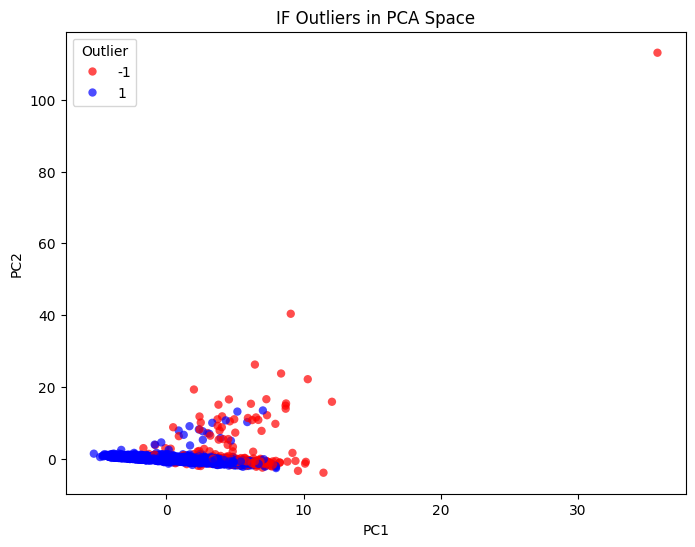

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='outlier',
    palette={1: 'blue', -1: 'red'},
    alpha=0.7,
    edgecolor='none'
)
plt.title('IF Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Outlier')
plt.show()

## Extended Isolation Forest

In [21]:
from isotree import IsolationForest

In [ ]:
# X must be a numpy array, so we convert it if it's a DataFrame
X_np = X.values if hasattr(X, 'values') else X

# ndim: check number of dimensions to use for splits
# ndim=1: standard IForest
# ndim > 1: Extended IForest (it uses multiple dimensions for splits, which can capture more complex relationships in the data)
model = IsolationForest(ndim=2, # 2 dimensions for splits
                        ntrees=200,
                        missing_action="fail") # No missing values present in the dataset
model.fit(X_np)


,sample_size,'auto'
,ntrees,200
,ndim,2
,ntry,1
,categ_cols,None
,max_depth,'auto'
,ncols_per_tree,None
,prob_pick_pooled_gain,0.0
,prob_pick_avg_gain,0.0
,prob_pick_full_gain,0.0
,prob_pick_dens,0.0


In [32]:
# Scores are the anomaly scores for each sample. The lower, the more abnormal.
scores = model.predict(X_np)

threshold = 0.6 
outliers = (scores > threshold).astype(int)

In [39]:
# 1. Scores
scores = model.predict(X_np)

# 2. Threshold to identify outliers
threshold = 0.5
outlier_labels = (scores > threshold).astype(int)

# 3. Results
unique, counts = np.unique(outlier_labels, return_counts=True)
counts_dict = dict(zip(unique, counts))

# n_out is the number of outliers (where label is 1)
n_out = outlier_labels.sum()
perc_out = n_out / len(outlier_labels) * 100

print(f"Threshold used: {threshold}")
print("Distribution (0: Inlier, 1: Outlier):", counts_dict)
print("Number of EIF outliers:", n_out)
print("Percentage of EIF outliers:", round(perc_out, 3), "%")

Threshold used: 0.5
Distribution (0: Inlier, 1: Outlier): {0: 8437, 1: 23}
Number of EIF outliers: 23
Percentage of EIF outliers: 0.272 %


In [41]:
# PCA Visualization of outliers
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df.index)
df_pca = df_pca.join(pd.Series(outliers, name='outlier'))
df_pca

,PC1,PC2,outlier
0,-2.584351,0.485096,0.336779
1,-2.839696,0.304753,0.332677
2,-0.698818,0.000424,0.326262
3,-0.332599,-0.038877,0.320962
4,0.743936,-0.376336,0.321495
...,...,...,...
8455,-3.323720,0.538533,0.342364
8456,-1.817244,0.397558,0.321251
8457,-0.717765,-0.246349,0.329092
8458,1.339937,-0.329919,0.323516


In [42]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='outlier',
    palette={0: 'blue', 1: 'red'},
    alpha=0.7,
    edgecolor='none'
)
plt.title('ABOD Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Outlier')
plt.show()

ValueError: The palette dictionary is missing keys: {0.30517932775019574, 0.3110623385033193, 0.3125672393824033, 0.31461031317660115, 0.33026222574319775, 0.3324010416976506, 0.3236792888120448, 0.3262737714241979, 0.31253468097625614, 0.323639302427182, 0.489757339948172, 0.3549958572546682, 0.31323517908446735, 0.3436601173884584, 0.39802212685524424, 0.3584955332894678, 0.34642500562916534, 0.33591991972324825, 0.3555299340257915, 0.36236773569085046, 0.3331584032889651, 0.3374044300240311, 0.3384017310505041, 0.3410427851541098, 0.3498867833376359, 0.3131582927013222, 0.31274338410834085, 0.3253321430356522, 0.30749581474208304, 0.31747090435453634, 0.32315092391547756, 0.32754828929967067, 0.3289304197929113, 0.3241838671386575, 0.321711689483351, 0.3228985770913653, 0.3231533771264879, 0.3054514185025159, 0.3584197393837238, 0.3564584441895937, 0.3115824682031473, 0.33419448453838324, 0.3333699509250595, 0.4658492260181961, 0.33267094067019765, 0.3374351646558008, 0.3430041889738893, 0.3104475409504205, 0.3116521266110369, 0.3118049630856633, 0.3120754626155674, 0.3291365792058373, 0.3293051135760693, 0.31126263139765353, 0.31452973192256206, 0.3215859427502893, 0.3237150611979588, 0.3395862491624318, 0.37958100600234, 0.39087089273838255, 0.3458262130021857, 0.33327222717634475, 0.3385439045216558, 0.36898038826207963, 0.33611990015293963, 0.3438144750470998, 0.35647148070997536, 0.8156970704724259, 0.3601267609732622, 0.35020277927693566, 0.33928186619097284, 0.3078865693884298, 0.31365796039879984, 0.32012145825386557, 0.3262440399793151, 0.3299456240845304, 0.3167130209753141, 0.316740137723116, 0.3181181882504804, 0.3223672092249787, 0.3216748578685868, 0.3388160208815574, 0.3377889596374912, 0.37857997139629546, 0.3646060991698093, 0.38939203980026604, 0.31244319415647503, 0.35555674211447574, 0.31240426054430814, 0.3373300253287571, 0.3353791169129125, 0.35247497094773883, 0.3434728102513009, 0.3046446922856634, 0.30746803563039315, 0.32197243128129593, 0.32222934344426357, 0.3193971369700963, 0.326891535310992, 0.3283914213542263, 0.3292896977588813, 0.33240552832192827, 0.3256163402178347, 0.3443537208504693, 0.3389828881146788, 0.36149257597906415, 0.36899436947594966, 0.3330686644801362, 0.33573548373872925, 0.33764515380349197, 0.3359006188836801, 0.34260573464213023, 0.3334168602085986, 0.3494819401335234, 0.3524444479559709, 0.34139200777853046, 0.3533405815453888, 0.3198860512480482, 0.3241105145876449, 0.32467395953968065, 0.32504442128784233, 0.32943851136310826, 0.32958025891169057, 0.3139840233687184, 0.30790319601300126, 0.3180656302564276, 0.31978437997187853, 0.35350147047902797, 0.36280479760271706, 0.30837861896249164, 0.33739303329874093, 0.3667110206421363, 0.3377707568239988, 0.3340057047571012, 0.3418109590395164, 0.3810446126260234, 0.34545314776393493, 0.34988767704482593, 0.3549463321513692, 0.36311750408860965, 0.36092363588611837, 0.3328750726464786, 0.31241037671792105, 0.3247461557099033, 0.3126834445506578, 0.3158879197789023, 0.3259694488622248, 0.32788324844523264, 0.3166765179889953, 0.31879883124737807, 0.320564627958689, 0.3300126264165474, 0.33490455521518225, 0.3355559993480615, 0.3469143642549606, 0.3387026081981282, 0.34249875487503295, 0.3694206802550986, 0.3467903849468289, 0.35854823604491093, 0.3795601633319703, 0.33553763821568267, 0.33620853677602847, 0.347597541692083, 0.3387708573089649, 0.3542606040500292, 0.35642645419825986, 0.31159022174693946, 0.34661451459857034, 0.39682520473394306, 0.3482550356562706, 0.32922073535274915, 0.31435256429995245, 0.306489386593427, 0.30749652601116434, 0.30912662945306163, 0.3104889634649343, 0.31300257239672685, 0.3073494247291397, 0.3188153158923374, 0.3219145365689688, 0.3464723419037289, 0.3388851152040273, 0.355753204974951, 0.34521948250730033, 0.35217377932912836, 0.41147104078782043, 0.3611332644413892, 0.33776064795367683, 0.365615960331776, 0.33546523134903444, 0.3081401504686092, 0.4060657208059475, 0.34657484312627973, 0.31059890055740147, 0.30794128878543237, 0.31699713200332313, 0.3109175628585068, 0.3142895279109017, 0.3142980909869242, 0.3157963595090796, 0.3175955395923471, 0.3212657005553585, 0.3305413230911829, 0.3219698887496496, 0.3181598587639205, 0.3184034145451875, 0.3385882853318628, 0.34307250414132906, 0.3759114324709841, 0.35248905866986424, 0.3567599399710456, 0.3425807846373438, 0.39918099617579245, 0.3412172206185856, 0.3425194883243817, 0.3344917361230316, 0.38120134726596694, 0.34201663535024013, 0.3743167560846504, 0.30603010640663736, 0.46270278968944795, 0.3515707254691678, 0.3126719199655246, 0.3076373948107976, 0.3185643076844263, 0.30511285549900485, 0.3314117078557222, 0.3156984203540177, 0.31626200716367286, 0.3218412559206035, 0.32616145322004547, 0.30665544194721456, 0.3627546203950357, 0.33973429513013204, 0.3956137835832424, 0.30830504131685177, 0.379847027906943, 0.34859752819515943, 0.3360865699329728, 0.3358639791379699, 0.3394249031501809, 0.4179924431990608, 0.34745586266583356, 0.3983362399899533, 0.30837232399706205, 0.34087932365837226, 0.3397439816009233, 0.357591533303763, 0.3385595793772963, 0.32530053058874897, 0.3272863362438164, 0.3257139631651148, 0.30708604302265086, 0.31704586913308275, 0.317541114365938, 0.3178738063070773, 0.31976088928210855, 0.32359280846998273, 0.3252308159466685, 0.3335076166189968, 0.35073532066917334, 0.3462088630341038, 0.3447061277876958, 0.3244737902386282, 0.33267603176948113, 0.35193242599272934, 0.33208351428445465, 0.3395692858766554, 0.4757923847928171, 0.3369972370411059, 0.4350160578379299, 0.325960130874713, 0.3674400790755048, 0.3410006518479859, 0.3473777156819153, 0.3307692894235578, 0.3325071777204875, 0.3069647404786912, 0.3102474864015227, 0.30465849269391815, 0.3067741049560914, 0.3079976698050337, 0.31770306689820477, 0.32586069611129237, 0.3280382048613297, 0.39254437811295717, 0.3247874136781807, 0.3330676331597773, 0.3442653066873499, 0.3557777763290796, 0.3429080021882589, 0.359631201238634, 0.3377464750592312, 0.33888037902673596, 0.336588348172554, 0.3647486461733387, 0.3396096958151181, 0.3334028699494395, 0.34877797924750764, 0.33338812399052536, 0.34407721067965163, 0.3329226572091668, 0.35713084687819197, 0.38751316659278223, 0.3329222679295663, 0.33237411969345554, 0.3215633153362354, 0.3262307953499579, 0.32740233653466144, 0.3301707915384362, 0.33217787432092005, 0.3124650393056789, 0.3191678805896181, 0.32813850192454264, 0.3293444415648288, 0.32061600421668685, 0.3470685505971042, 0.355913500617886, 0.3389186065837128, 0.3406278522011575, 0.3417564826654938, 0.4051195842255778, 0.3498192479304698, 0.3444912681366191, 0.30737162949951286, 0.34056212107152434, 0.35397478101567587, 0.34228355294294643, 0.3466624727700507, 0.3240654318833556, 0.32572063290751957, 0.3184239023199929, 0.3243782925790278, 0.3319127279030603, 0.3077565537360279, 0.3093905583253907, 0.31171055148584587, 0.3146724612863359, 0.31657851030732403, 0.32684034200703144, 0.3333026310223777, 0.3757126105776017, 0.353879452780986, 0.3441649061112501, 0.3393925433084147, 0.3394304523172872, 0.3372309499230465, 0.34410135665833474, 0.34359122222298644, 0.33473800720962277, 0.32055799909630955, 0.32459117550661254, 0.32546635783524, 0.30630495690383064, 0.31412117759893554, 0.30780325297077205, 0.31888899647698643, 0.3246489875517832, 0.31675852409787886, 0.3295491351916845, 0.3374674510024782, 0.34475048544242193, 0.3588848793223074, 0.34242166236973964, 0.38650025210115446, 0.3436609647919422, 0.34131133066361025, 0.33734175707099373, 0.336963244765012, 0.3407430164446067, 0.33803503988931427, 0.35317541824090315, 0.33942181164645974, 0.3817179040098179, 0.31650359640808373, 0.3223043278357957, 0.3174182893098995, 0.32031840004071993, 0.32385667139044555, 0.3065178500652203, 0.30785170653065647, 0.3137200895398999, 0.3146292801024097, 0.304821896941406, 0.36442563277664974, 0.3732572311446829, 0.3543035645094811, 0.33805833239313593, 0.3649093366100869, 0.3403268373044995, 0.3377818361658182, 0.3461657259047978, 0.3620212648087044, 0.38258868277798475, 0.34108705448903137, 0.3375501645356134, 0.3332992149988012, 0.34567650468639993, 0.3551938752359224, 0.34795739232992934, 0.33396435601791896, 0.31763248434605007, 0.31949236603326003, 0.32444900602034554, 0.327906057294272, 0.3048009910070144, 0.30643104096184093, 0.3077964711096408, 0.3079256548825535, 0.32010133533754104, 0.3220278686886795, 0.39534864188875585, 0.36365661838834934, 0.35332979848066537, 0.33904736261983565, 0.3401203046840674, 0.35058705459450795, 0.35856913789777317, 0.3307050992905446, 0.3582260018587738, 0.36546468718509856, 0.4228908525885279, 0.3570953106653643, 0.3732048573423562, 0.3338187070689942, 0.33510653285803993, 0.3204279490546194, 0.3211920416410701, 0.32245577533248687, 0.3089210422301543, 0.30981075165901567, 0.31465699812348286, 0.3204376687309472, 0.32939276588386784, 0.3219871852991228, 0.30708534077486244, 0.3410243298278335, 0.3449969839614582, 0.34880462518993144, 0.33033461316243545, 0.36709497923173756, 0.31260337904190516, 0.34194888117794386, 0.3252309714747817, 0.32694325246566863, 0.33702024123331925, 0.3531345904392829, 0.371065442153358, 0.3262871275556956, 0.33882227848395907, 0.35862701411967557, 0.3971456659935246, 0.33473492954433515, 0.33994403942076734, 0.3528968232502206, 0.3370803337575975, 0.3383453482339004, 0.3351027233731167, 0.34275885382307586, 0.3526574452363993, 0.32195093681339515, 0.3236601010360839, 0.3269618275637224, 0.33002147093800815, 0.31701472588528745, 0.3204590084025948, 0.32068526086183724, 0.32640299113447313, 0.3269763346440594, 0.3130442905274019, 0.35104189145878095, 0.35820000520194567, 0.34167133497078006, 0.33441208299807307, 0.34062794214485087, 0.3638511603946191, 0.3353962414278428, 0.3102142202382177, 0.3394989015198506, 0.3653849448835489, 0.3466263004165911, 0.4929483965580145, 0.3077870533608115, 0.3394685947079572, 0.3403671677089526, 0.34945417431593345, 0.34402183862792557, 0.3121647799779461, 0.3930049567037608, 0.31005733685533804, 0.3221062018290734, 0.327088137109585, 0.30497461567094425, 0.31781282673509387, 0.3197060649199283, 0.324665969781422, 0.32509402382263025, 0.3149933150024122, 0.3259434665344411, 0.34180006774349714, 0.3720492228947096, 0.32804091254671547, 0.3733043150603986, 0.3145759546688419, 0.3765677592160751, 0.3877694471194696, 0.33765927083612074, 0.3463169211925913, 0.36033152915155764, 0.31428887774068237, 0.3338513676107837, 0.34229579943741, 0.36551251893785475, 0.36050022998044323, 0.3548855705180106, 0.32231671560232766, 0.32831071958908464, 0.3323387187103475, 0.30589216908664807, 0.3060568243484181, 0.3069189181913299, 0.30700783981080915, 0.3076820565575542, 0.3094568671282343, 0.31174145010686627, 0.3382718691272154, 0.3373252033212872, 0.35873659108952655, 0.3432123484473881, 0.329094353856148, 0.31183868844776896, 0.320820464400403, 0.33875101593534507, 0.336465350776414, 0.35575161345691464, 0.40987451327459945, 0.3561352717461968, 0.3381468191547917, 0.35078764120104255, 0.36138386947438206, 0.5134831872950353, 0.3729029712061908, 0.321118819695742, 0.32877504699529086, 0.32972304927516066, 0.3308418767274344, 0.31505402009116895, 0.33245574779329107, 0.3206259262007774, 0.30838353277285196, 0.31322522559092764, 0.3133655360229722, 0.3404840265120868, 0.3502885540697972, 0.33703571937138777, 0.33726017049110824, 0.5242968547692632, 0.3258114608796387, 0.3368251270543632, 0.3536776289974122, 0.3522016496162484, 0.35874753430476564, 0.3412390032678239, 0.34416564233347735, 0.3693249892638742, 0.33351038355697604, 0.3538321031900785, 0.30763854675663826, 0.45859783600061493, 0.3075780287428097, 0.33793895520938605, 0.35878495874721267, 0.3390104754056221, 0.34049163501354196, 0.31275225962782277, 0.3525688762493839, 0.31924467276080415, 0.3293263562028853, 0.30556494142328583, 0.30868276088283275, 0.31077900175761053, 0.3174638687249439, 0.31965115408554945, 0.32487760981492053, 0.32497129473854736, 0.3308778106132463, 0.5457335718868067, 0.4688464223221002, 0.3079294850867263, 0.334545716651505, 0.3522307842924863, 0.37993963287091237, 0.31809828599909296, 0.3394523915339369, 0.34045465042885104, 0.3214158462912556, 0.3314271793630715, 0.3089248530815885, 0.3104196727692388, 0.31343973562593586, 0.33835712401719487, 0.3644063626927155, 0.3234273733310444, 0.32948179249072623, 0.32967949340745534, 0.3126311372483754, 0.3176078761439824, 0.32115765517805656, 0.32959385556891746, 0.32931021264568144, 0.31437947504353886, 0.3067406182856884, 0.35116810663599374, 0.34479895220739837, 0.34674709781121765, 0.416186539873362, 0.3548227332778695, 0.3399874556601686, 0.3448847882752588, 0.340425708595009, 0.30973463574601023, 0.3476491561984423, 0.3684000081973934, 0.37611790823603564, 0.3269424020585216, 0.3687251590835452, 0.33998384417515964, 0.34894911930739664, 0.35287801386782786, 0.3384747818430592, 0.3149803380649856, 0.3151529542315372, 0.31962672985540186, 0.32384653292254617, 0.33150528713238847, 0.3322515041378735, 0.32399482772045607, 0.32714974389516405, 0.31027396157286224, 0.31234447692138323, 0.336214247673567, 0.3426628842000883, 0.33656812641930706, 0.32194552286670264, 0.32308420749801703, 0.3240978438783383, 0.34254240075917736, 0.38812722267187166, 0.33877339805415724, 0.31446689723251076, 0.3259974310642847, 0.3398768368342138, 0.35186827530660847, 0.3234821384177445, 0.37480248962825097, 0.381079810432046, 0.32480423112366585, 0.353498873985124, 0.3217062705693202, 0.3178516296386689, 0.323792943008614, 0.32707010585025525, 0.30544402487270045, 0.31185137607092056, 0.32363424515284717, 0.3301532486465831, 0.331739059051587, 0.3207569062921905, 0.3249766624173574, 0.33315864709246773, 0.38310168430985136, 0.35136373656577663, 0.32938632398872897, 0.3139823514557154, 0.31914862519634507, 0.3498964658839267, 0.33878532730178584, 0.3257178476922646, 0.3463934247760061, 0.33512156811950505, 0.3427703823022314, 0.3502659858432535, 0.3264389672909909, 0.34604869420002965, 0.3266771753226198, 0.3372995200618238, 0.32102930793721046, 0.3503756031926469, 0.3328085798870214, 0.33500675332784396, 0.3416991518965466, 0.3527233376517472, 0.33544099614497264, 0.383833662776281, 0.3160263065016139, 0.31636877455197665, 0.3225623812670776, 0.3193932974519683, 0.3200758724499636, 0.30696642520894246, 0.3081852823083594, 0.31403957537594496, 0.32083016777782947, 0.3174304316590054, 0.3222865061411825, 0.34170653359431397, 0.346114116115567, 0.3152077946575782, 0.3275050827488821, 0.3320933490055629, 0.33231147856027177, 0.33597820222899766, 0.3252797347509951, 0.3487654662250062, 0.38309035006897113, 0.3473206327009554, 0.33472772599163664, 0.3264486484407608, 0.3179020488474519, 0.34035255806573994, 0.34482756467687437, 0.34911106071564285, 0.3161564453716907, 0.3176692637461131, 0.32068978647159135, 0.3281284626136924, 0.30620570486715487, 0.3071357407184238, 0.30917493487110553, 0.3135812459913027, 0.31972178569326254, 0.315546751180241, 0.31961208833910426, 0.3351084663643873, 0.3235848874209107, 0.32458757821939727, 0.3277118370396049, 0.3952910635011285, 0.3171392522162794, 0.33288009563101223, 0.34045393357836, 0.34483381434669136, 0.34865269424839207, 0.3461531108906849, 0.3403468231646875, 0.3354342956180102, 0.32481931066641406, 0.3311220859864195, 0.33133715829445715, 0.36209386556812456, 0.33801222086691773, 0.3082817431028328, 0.3126498945251383, 0.3200943257487138, 0.30999283476147677, 0.46823322686713065, 0.32884385190849635, 0.33796555389803534, 0.3363997587582634, 0.3400060174119534, 0.31705164517687634, 0.3222241676942177, 0.3227263135288341, 0.3286298755924564, 0.3057789282006682, 0.3094505796823783, 0.3125662627913799, 0.31092405090331154, 0.3279534934388566, 0.32786755875877005, 0.33345439160799567, 0.36685837943783833, 0.40657310431471694, 0.3380647979826076, 0.33863309195123426, 0.3390745944795292, 0.3403520521202829, 0.3338134498315709, 0.3413213393390701, 0.32682982882300915, 0.31785792690493964, 0.3312347639569043, 0.34285620633705094, 0.31754956350219854, 0.32384884291455873, 0.40241608962593145, 0.32604591045307296, 0.34486956003094654, 0.3355550280750116, 0.3645690717773299, 0.3254911971615327, 0.3153868845152788, 0.3224883262791723, 0.3242855357687818, 0.3291777178644411, 0.30479894342430375, 0.32077600783689936, 0.3230967418186184, 0.32392444581442864, 0.328451444312792, 0.32124315163116696, 0.3173681996736804, 0.31346391373723065, 0.3224442149788146, 0.3072756830859941, 0.33386702506087795, 0.44709594941016084, 0.3352108761438355, 0.35048431208827213, 0.32495033311650884, 0.34638319383329114, 0.32972514129960223, 0.34079585914751337, 0.33309540748419353, 0.3627172239800126, 0.3398066083379567, 0.3332496982965193, 0.34925095699679043, 0.33022859785889996, 0.3328874423073812, 0.31912708164768044, 0.3206319254689748, 0.3233386267315569, 0.32628754374147373, 0.31309811624213235, 0.32457728466850877, 0.3151322751344895, 0.32181746448009274, 0.32262781847214395, 0.30676399074633476, 0.31572006927238944, 0.3345162758628252, 0.33819369480170314, 0.3383183927958274, 0.32289759935484286, 0.3318414166744438, 0.3326289003323032, 0.33306059064041627, 0.35926435769871345, 0.31876676338585125, 0.3909753483455566, 0.3351350242681928, 0.3369399484048906, 0.3188713243793932, 0.3419788709389478, 0.3493186627220722, 0.35150505844522323, 0.3698580693904968, 0.31749681201307495, 0.3524174119071965, 0.34851496042323515, 0.31118875346218583, 0.32404498123814146, 0.3345770708932813, 0.35117824250564617, 0.3338854968269067, 0.3166763280783528, 0.39451783082682257, 0.32846284580560847, 0.32883629189715236, 0.3182810276655024, 0.3363062729793159, 0.3175205240000469, 0.31329000532454815, 0.3217414101914943, 0.31261190143141165, 0.3189337411582773, 0.3286258967604016, 0.3117213551303894, 0.3137970744780762, 0.32347436716138495, 0.3206793172140738, 0.3115847232319067, 0.3764881420779662, 0.33650224940543866, 0.3499273458251622, 0.34769540041831076, 0.3369453941379268, 0.33435559595206593, 0.32410489656274527, 0.332964678647728, 0.3724187635533564, 0.3391475594434532, 0.36366776370953535, 0.4366255152863066, 0.3470763231258273, 0.33151813873400254, 0.3420880969117142, 0.33452924854895694, 0.33401783773369836, 0.40337413349543433, 0.3284276915228563, 0.32980332319949385, 0.37806783923043413, 0.3159634981796575, 0.3242046068220521, 0.31341039104252566, 0.3259240947837032, 0.3155704809997548, 0.31790180535523405, 0.3239736713652963, 0.3207498444142107, 0.32627979803503315, 0.3160458903234389, 0.3360224981826542, 0.33909797029506816, 0.33777933073572647, 0.37818891907984514, 0.33145135804477766, 0.32584653183124107, 0.3455871638666737, 0.33304489697556205, 0.339947417099341, 0.3332965820579339, 0.35583923156377645, 0.32759987571107707, 0.3212386930716588, 0.33780396221887715, 0.32939313228559114, 0.3066793007503031, 0.3433298145284163, 0.371689519886631, 0.350840328301167, 0.32591179879449117, 0.3357447783010626, 0.346445413284254, 0.3317596018204814, 0.322062902842335, 0.323413715936626, 0.32887898929233655, 0.3307895427308712, 0.3153456712471599, 0.32001842472080183, 0.32963162613309477, 0.32929276308931504, 0.326533617937999, 0.3168936319223619, 0.3259835901499798, 0.3297350541548155, 0.3789651774914716, 0.32170561273789783, 0.3340221002060155, 0.3300820523229296, 0.3414332514492161, 0.3189389231400425, 0.3357401271712958, 0.33817570308686545, 0.34258521211439574, 0.3302135466862658, 0.34008615610055337, 0.322025513627396, 0.33218468768642256, 0.3379769185861375, 0.5838400015441212, 0.31669128466239693, 0.33602684970099056, 0.3162559050414747, 0.3257965824819157, 0.31577483014504726, 0.3267834775780064, 0.3136862167405231, 0.321330410633765, 0.32566982493709606, 0.3255916428902329, 0.3294048707972498, 0.3142807963695732, 0.31777303807261614, 0.35473106581825686, 0.33316647291812823, 0.35499101183372894, 0.3265773329724272, 0.3402732489487889, 0.3285306890373829, 0.332145342766959, 0.33550625338868173, 0.3333137417363357, 0.3790465912717814, 0.41838996965852104, 0.3166897999739781, 0.3090734352171644, 0.3152881249430747, 0.32163907153986265, 0.33116220792972717, 0.33144447504101526, 0.31649480761626736, 0.336046797705707, 0.33976026011747934, 0.34368167582571885, 0.3636978881213738, 0.34143154465262165, 0.3311414896828941, 0.3265658397451025, 0.3158026497796575, 0.32456238704193846, 0.3324776296850322, 0.3103098866159561, 0.31078988952771364, 0.31329693930544716, 0.312576086141876, 0.3149744674066675, 0.31787189423596907, 0.3212509358693653, 0.3327007371520169, 0.334962032492321, 0.3372044789669799, 0.4055554856725776, 0.42881386615030537, 0.33482046336662064, 0.3442731620361887, 0.3183732971047957, 0.33681147526813504, 0.3352374424437261, 0.365129165795106, 0.34283331732142214, 0.36555680129229184, 0.3335796283418207, 0.35160732028733144, 0.33325165475147983, 0.33856502295834684, 0.3726806047674934, 0.32429486122328266, 0.3056512912608046, 0.33157357174983365, 0.3416761178475233, 0.32456987273350707, 0.34746856144262667, 0.3175319788745574, 0.32368140045132265, 0.3270207739205253, 0.3282654130531901, 0.3232729765106248, 0.3289664782365114, 0.3199998780960007, 0.3205870949501153, 0.32258896679123183, 0.3232682374799245, 0.35953812715553823, 0.3761309534305593, 0.3437368282294158, 0.318123375151482, 0.3612944364034784, 0.3139455544368992, 0.3411800994510168, 0.3341750427796049, 0.31359266656625207, 0.33347981418312794, 0.32873879159977315, 0.3397133677470732, 0.34689905313407887, 0.34772419259516407, 0.36994529612993954, 0.30998161478824565, 0.3204126283053646, 0.32080034883303404, 0.3229700405454586, 0.32767902282843614, 0.3302697623539806, 0.3072540912446889, 0.32127249627959237, 0.330445487602477, 0.32473004319153836, 0.3140262258512528, 0.3069523849731582, 0.3184398979357576, 0.32668494055694114, 0.32899211648211435, 0.37168840151363924, 0.32816800031402976, 0.35108181950551653, 0.3210863160314389, 0.3329555682312618, 0.3391469594830939, 0.326412037500259, 0.3162827525914524, 0.32221367004459106, 0.35964071793929187, 0.338795517215215, 0.3203983917953076, 0.3235610587486656, 0.32907827435494624, 0.33226528172452385, 0.3417503252129631, 0.37341068473722994, 0.3214006252664469, 0.3242598057513424, 0.30491162277079054, 0.31802378603211634, 0.3219077173107955, 0.32911624183026544, 0.3283569840120485, 0.3154762380249586, 0.31683894517161304, 0.3208736852396633, 0.32963663812198474, 0.3301428331403592, 0.33792098829712996, 0.413055601966205, 0.3154226337013919, 0.3162013287379239, 0.31981406246870536, 0.3266015941290985, 0.32149206545293707, 0.33121625180099734, 0.35675083152053055, 0.3234775790245112, 0.312365442678838, 0.3123018546329978, 0.36828512099236027, 0.38531895351751805, 0.3136265295957826, 0.3430636794679681, 0.37913526122943, 0.3342835331083755, 0.3360773913374963, 0.34448375407391935, 0.33949398774021894, 0.32270636096197114, 0.32160613751245537, 0.3123210764794544, 0.3269225533146505, 0.3822015829447787, 0.3108529654493671, 0.3180862474966764, 0.33900432393446234, 0.3319253031423863, 0.317510550979835, 0.31849814013527794, 0.32874215339497187, 0.3283835735140052, 0.328912888203778, 0.3193746643119674, 0.3242948142895465, 0.31282386213590246, 0.3141427252694432, 0.3229458811278061, 0.33357548758789696, 0.3449028385901429, 0.35459308070067985, 0.35412423112840463, 0.3146291878597089, 0.3201824416050562, 0.35007051649029364, 0.32959714039832816, 0.3431600132941943, 0.39789648399594935, 0.31809786046531935, 0.3212687207481269, 0.34113923165463256, 0.34532515591485624, 0.3486811477896457, 0.35677839337495004, 0.348709581540882, 0.3221931366590148, 0.34054524940230163, 0.32894000810330376, 0.3144875201723332, 0.3235210906954487, 0.3318954144423694, 0.34072988489153916, 0.3227246175261933, 0.32462283735935893, 0.3267255963412503, 0.32929625171425636, 0.3143159829114972, 0.31773084477495894, 0.32127931424455136, 0.33103572834741835, 0.3104610093849822, 0.31055886277785527, 0.3327113091236953, 0.33501563105954457, 0.34795434949558596, 0.3296214769386429, 0.3266101825742179, 0.33088634778955356, 0.3224016407762069, 0.3590130525840327, 0.3142484558540299, 0.33898923731217917, 0.30677303859803184, 0.3227746618433336, 0.3233977788861598, 0.3168661286594423, 0.3066203158586865, 0.3348855039143706, 0.3397355727821207, 0.3531134520582182, 0.31292562518982997, 0.3180756681222225, 0.31558917464558944, 0.317588658451413, 0.3229146317095565, 0.3250134678225204, 0.318937799023376, 0.31114328358762805, 0.31881521663938145, 0.31945600538988345, 0.31900173617511207, 0.32288318955922257, 0.3048334052226119, 0.31971817016091336, 0.31653937769631796, 0.33206434257779677, 0.34492552239573376, 0.3253499148203682, 0.6173242463578197, 0.4173036632660401, 0.3220457477037456, 0.3272399703724997, 0.3061716457202146, 0.3327195725584624, 0.34529814903470646, 0.31670968272132843, 0.3350384673803102, 0.3453239174972633, 0.33529943224812697, 0.3413125063321418, 0.32506701691651424, 0.3443234425223319, 0.3447187813582469, 0.32767467279674556, 0.35837570297401133, 0.36600875116153136, 0.333897460234391, 0.3091562647385685, 0.3102180172940318, 0.33193398066223045, 0.32141518420097503, 0.31586086907975874, 0.31823167254289564, 0.3214590413373509, 0.328650255477117, 0.3078067015955265, 0.3114548277816903, 0.311596122480014, 0.31325308730891044, 0.30623845686210427, 0.3178052348821528, 0.3232016682227937, 0.3344242355975579, 0.33794929084525377, 0.34671330972661546, 0.34926131921439757, 0.38615804485045974, 0.3290535961240306, 0.34425006889739906, 0.32695788826498046, 0.3086416571372729, 0.31471225210183346, 0.34331542256822156, 0.4823143120926428, 0.3228409779492258, 0.31769927285137395, 0.36741766687879657, 0.3440538512219232, 0.3203634701682598, 0.3257815331132145, 0.3706030281489112, 0.35363081085577225, 0.3365948563358711, 0.33824269781109173, 0.31801678629888624, 0.31995992762468245, 0.32336373058089646, 0.32796251013835115, 0.3202297579558599, 0.3250421529149771, 0.3311308110981936, 0.31613026042681963, 0.31689336381272665, 0.3239065252622761, 0.3107255158099172, 0.350363325855323, 0.3290469313249604, 0.3263307807741127, 0.3431990398511611, 0.33386237732981394, 0.36516370507212637, 0.415352717467006, 0.3306833213549777, 0.3325306145783412, 0.3450230787834138, 0.3530702725483854, 0.3142254181485412, 0.33001126838789496, 0.31482268847289524, 0.3340364165407205, 0.32527843875810575, 0.3467307718873242, 0.3152915670743037, 0.32078204895279994, 0.3256295955710935, 0.35480159268437417, 0.34961843416610133, 0.388917193363262, 0.32670044335379494, 0.32985803049911916, 0.3174773795086592, 0.33570181951301925, 0.3166587236503168, 0.32457205237286035, 0.30780421145729764, 0.318304168327219, 0.32557643944218984, 0.3205076274544918, 0.3215161171039991, 0.3284437744116413, 0.32233420982709293, 0.3235029500731368, 0.33004387191397444, 0.32438334148294956, 0.3414170447571348, 0.31835580183319245, 0.35367652991012866, 0.3336635533330132, 0.3152149005061902, 0.3224665542673493, 0.3074757894154244, 0.31152484975506367, 0.34542881612184273, 0.3240983454047359, 0.3141647903312535, 0.4118737447384067, 0.33399919485971175, 0.35115245500230946, 0.32735591637554595, 0.34048860047208424, 0.3528268372222911, 0.5865420778973179, 0.33076058973174716, 0.31263180754445913, 0.3142226064003937, 0.32164881807324514, 0.3250722349502578, 0.32273341394177885, 0.3276775724502439, 0.32958029554477514, 0.3228362806314376, 0.3229329833053239, 0.32468642232263073, 0.3294423326612755, 0.31651027492135847, 0.36831963843599713, 0.324134386639152, 0.3414157464451722, 0.3255400738129012, 0.30692606788433746, 0.32462945475344945, 0.32270859215905706, 0.3269967500725322, 0.3493247948770816, 0.3150838563623166, 0.3209706153487515, 0.3769149048593344, 0.40564625889417194, 0.3146817913011805, 0.3155243873602817, 0.33744745914476343, 0.32544486522855776, 0.3356754946942533, 0.3490237652438668, 0.3390652960737, 0.31781654438091034, 0.32881795272705683, 0.34876570113010863, 0.35036810354272935, 0.3294672535034263, 0.31324743916759956, 0.31608491405229955, 0.33089137789473255, 0.3163491330422826, 0.3249213055617898, 0.31679348417081854, 0.3245956985517634, 0.3090671515283273, 0.31091215534141525, 0.3357987763022906, 0.31578789569891635, 0.3295399017050597, 0.3202726055318872, 0.3220075839408117, 0.33093403113250935, 0.32332929366988283, 0.33566996060675847, 0.3387413101715927, 0.3099232479483322, 0.33226988538016994, 0.3418264298401973, 0.34143344148025095, 0.332531497850746, 0.3286750360354908, 0.31613938446596035, 0.3579394791920738, 0.31324249958226896, 0.30689953977387807, 0.34604633959086817, 0.3291601132064304, 0.345232264782712, 0.31071797727107653, 0.32876265880003586, 0.3095696559037114, 0.3211244563265597, 0.3243091180839199, 0.3139660599782443, 0.3251705949216754, 0.32894184592894055, 0.3055055929331613, 0.31556948672516943, 0.33114874273042266, 0.3098704436993271, 0.31031853182854524, 0.3114873287206476, 0.32166857391212933, 0.333338274550858, 0.32518512661333104, 0.3290117876733059, 0.32924750994723023, 0.34304007043945045, 0.3534686641762836, 0.30571922461406453, 0.3476746974036602, 0.371684167577611, 0.3229374741994727, 0.3203863431913169, 0.4169458029159478, 0.32526831963062963, 0.32480798577952613, 0.32511327347424324, 0.4337115987266307, 0.3069045527784527, 0.3460447340556626, 0.3275355730842968, 0.3450509308567782, 0.3583086651692249, 0.323274129314146, 0.32930852714304437, 0.3535876548153881, 0.3203160533422475, 0.3565200423816304, 0.315689649945147, 0.33740674669636445, 0.35477248242452714, 0.3456910875040894, 0.36698900411131924, 0.344931331092887, 0.32102987613819584, 0.3316017191746452, 0.31788214060536557, 0.3198503802372441, 0.31855701026684624, 0.3204683627444238, 0.3256576226597927, 0.306984113733054, 0.3097868435150728, 0.310873251463593, 0.3257074165050167, 0.32792727609394146, 0.3332087176410337, 0.3772518652960565, 0.35395668553087684, 0.3234674405774103, 0.32992318445240465, 0.3404232499968247, 0.35794104500005935, 0.3304183842241496, 0.32554261184119543, 0.35155675897655175, 0.32134198647055756, 0.3376150481285696, 0.3393312014082004, 0.33598092576682476, 0.3127410847230568, 0.3080688764265557, 0.34651959929891607, 0.3415511537395935, 0.3185217052906381, 0.3251121575031874, 0.3355786135904026, 0.35409552147639484, 0.31583018007791475, 0.33640251009524513, 0.3250076933535282, 0.3272319702058791, 0.3075403897140983, 0.34151215132479923, 0.3320362682293002, 0.33253977449427696, 0.32780494519790593, 0.3296013521431378, 0.3592645562858452, 0.3910898579193345, 0.3047917901536719, 0.3247293385226156, 0.3136691574538214, 0.3181441934393972, 0.3062566750990526, 0.3235719311364305, 0.32493342242429707, 0.31349230527919936, 0.3248437189906524, 0.3256056140465687, 0.30953562709236154, 0.3243663857917794, 0.3277996560977839, 0.31496316036130884, 0.3265815069624623, 0.3508437636992261, 0.32279738751007897, 0.33075458677926434, 0.35162087218400045, 0.32032405437226114, 0.4879352087761668, 0.3312214874729383, 0.36160103107091196, 0.362667414887945, 0.3156062835517914, 0.31721853924533566, 0.3227796910563636, 0.329326519721614, 0.32007979300712536, 0.3404274043214376, 0.3428844326808961, 0.38375391407909987, 0.33678164846076536, 0.32893760637828884, 0.3320149986791751, 0.34024091535846884, 0.36379230398855644, 0.30611219699939457, 0.32061670923616903, 0.3169515078831463, 0.34304469720487385, 0.32327880875046383, 0.35776650888211287, 0.30834368407960416, 0.3090462806360977, 0.39645151801352246, 0.34505746557748995, 0.3971556192118957, 0.32343107868429677, 0.3247830748674857, 0.3269251749366219, 0.3059437089197302, 0.3318701552143778, 0.32225185740974205, 0.32243504164391645, 0.3307760980049351, 0.3114649200886702, 0.32938148989882443, 0.31826577722775096, 0.33154517829468955, 0.3364955386069398, 0.3213859210283145, 0.32903251442542664, 0.3345807585357134, 0.35056585601303436, 0.3305577912076266, 0.390724924599262, 0.3222289429512259, 0.3438746241722589, 0.31510517109977937, 0.31675233791980045, 0.37021527883481375, 0.327165678946371, 0.3269783118142344, 0.33205818667726833, 0.32306227642900537, 0.3546983657375087, 0.33951691883660584, 0.35830552394289167, 0.33542412383047754, 0.37672148938435107, 0.33880069702790255, 0.3474210043463228, 0.32588317298627856, 0.3299210951149243, 0.3502303321038232, 0.35832687190577756, 0.37759387329788635, 0.3307427280889243, 0.33177354003214815, 0.3085818080949309, 0.31291274886690984, 0.31738609087666986, 0.32318377063578224, 0.3273552422936376, 0.31617285790996447, 0.3229565940916245, 0.3252360201536703, 0.30814631320996533, 0.31219809071605387, 0.3303155172078009, 0.3100560237324983, 0.3255451848943933, 0.32032079183811774, 0.3213244890679799, 0.35035836445374924, 0.3692097683947203, 0.36606011232068747, 0.33081130803765524, 0.39699461015078674, 0.3192951354129957, 0.3272009513747446, 0.32023352763745827, 0.328772693802619, 0.31532076180453333, 0.316227428234716, 0.33178985554038337, 0.32839625930302974, 0.3115047127310605, 0.31167130845399116, 0.3528512389342028, 0.3333507604996852, 0.32721534194336455, 0.32192018147087037, 0.3276203627542916, 0.3349677286883296, 0.3436844849543693, 0.35105815989403744, 0.3229192137898699, 0.3101359747372462, 0.3120004463291898, 0.32374595900217007, 0.32397012567423933, 0.3291887324127203, 0.33220296436585106, 0.30561053123294646, 0.3165214175429043, 0.3190024603160879, 0.320782342866724, 0.3219389390394014, 0.31185268639861197, 0.33791304629667535, 0.36081847039391246, 0.33319865282743444, 0.3365868643682577, 0.3421767412247052, 0.32113616941357426, 0.32397927270737303, 0.3504519368422446, 0.3750394148543531, 0.33220249760435866, 0.33353254427441453, 0.3603341608149388, 0.31661796162642086, 0.33716047437018015, 0.32985234578021655, 0.3154560820048918, 0.32935755663178307, 0.3369090408805622, 0.3185411522245801, 0.3206222041609096, 0.3313786184990847, 0.3440981927165357, 0.31809053115257147, 0.3470590578387567, 0.3061855560970335, 0.31207083910913014, 0.31973147583677297, 0.3066310320437568, 0.3552705308111998, 0.36078991417713574, 0.4255348826550888, 0.3220659362824985, 0.32428900520396514, 0.33042251435947423, 0.3322145845588459, 0.33307852488016965, 0.32877684620673775, 0.3880209697739063, 0.340199788699909, 0.3281126697926198, 0.3287707979205721, 0.3158662575168621, 0.32589614171616016, 0.3303423956498393, 0.32536363469525337, 0.32920784927491137, 0.3186454308034031, 0.32262824201523027, 0.3147110488016012, 0.31914051766083595, 0.33810137746299607, 0.33252770610011084, 0.4059798510031689, 0.3281794626198507, 0.33453362373102663, 0.3390427473717, 0.39755314739004916, 0.324769665100446, 0.3357597434223049, 0.34663470305760363, 0.3325722533971502, 0.3251704199923902, 0.3555801916886035, 0.33491694023086105, 0.3359274889640773, 0.3149258149038812, 0.33864531755017024, 0.3258514468110786, 0.32650382454122673, 0.32016214817715016, 0.3244132239439547, 0.3296905622398096, 0.32337548945462247, 0.31615115724412435, 0.326403894688727, 0.32644495731028955, 0.3127133590186618, 0.3154174762807175, 0.3299726734258316, 0.33164706177186376, 0.32056302431572037, 0.32261547818045544, 0.3170094221352251, 0.3187273468245949, 0.32021590043521725, 0.33360404180388437, 0.34402040886510954, 0.3276791704638476, 0.36035196251941165, 0.32942918311168545, 0.3219093502953911, 0.3204771954780452, 0.3112937150761456, 0.3605222498547948, 0.3294514176582401, 0.33706283713583834, 0.33375514167626097, 0.3264739910275064, 0.36204484209673027, 0.32301978285498406, 0.31254102439178166, 0.3196017798539644, 0.343634447109561, 0.31775933686357527, 0.31974111215135487, 0.3198033622392766, 0.3445081172394064, 0.3523764853503511, 0.37761360570589236, 0.3380743341391309, 0.34108416608669645, 0.3172480693939687, 0.325828263954605, 0.33424624568229405, 0.31214564305556336, 0.32985079636565273, 0.3350563633864192, 0.3901321034952241, 0.3378248051915412, 0.33948329127071186, 0.3159750710955151, 0.32245393299705677, 0.3245168026555549, 0.3080056020410384, 0.31023484846652444, 0.3193502023748524, 0.3281999915156066, 0.3079746988437821, 0.3289394839742274, 0.32517195778717983, 0.32985447557809117, 0.3116165404233046, 0.3337324213353698, 0.3303390923198377, 0.33829462273945965, 0.32249754866629, 0.3464173974492426, 0.33432544378583323, 0.3436923965895358, 0.3299390001352075, 0.33703814373252305, 0.3775010049138908, 0.3398757909290004, 0.32411201750172935, 0.3352823061598107, 0.3367810069173762, 0.32338430335795915, 0.41702811947504437, 0.31414551807663504, 0.3284962735183659, 0.3194237066569089, 0.3261301501662105, 0.32007185305127406, 0.35883275219684274, 0.32396940208477226, 0.3171514031841054, 0.3410434463349307, 0.31010658327474827, 0.31882697504044044, 0.32757611032376444, 0.3279773460483173, 0.326875306708192, 0.3294896794960809, 0.3272145393874726, 0.3143977507691349, 0.3228384835273803, 0.31203071482714817, 0.32118400077584935, 0.33065705176592725, 0.3295993185496385, 0.33313547038539887, 0.3370272362939189, 0.33824604879407466, 0.3265139561289526, 0.31845580845172566, 0.3294393575006133, 0.37046846857495597, 0.308570865096121, 0.3172396487708623, 0.3416996448432995, 0.34178135548621624, 0.32592438234518606, 0.39005990423515224, 0.32679262903943573, 0.3667302524753254, 0.32919133947957935, 0.4239583733628516, 0.310361362900955, 0.3480555965215962, 0.3628921408408195, 0.33765121639549733, 0.32051541330439476, 0.3183862973771448, 0.34748378641895294, 0.31836134534280397, 0.31121850499755643, 0.3777116303361949, 0.339163199278557, 0.321495080563716, 0.37306353258249186, 0.31739103548370007, 0.33313752821204, 0.3154297773609929, 0.32759016871189633, 0.3320631824884291, 0.31216610867508937, 0.32027715520561945, 0.3212997425388014, 0.32821123607547836, 0.3282834554677155, 0.3321077773459709, 0.3133438005912726, 0.3103140271371547, 0.33677934386046365, 0.3104469841219867, 0.3266151596604828, 0.35964295434143023, 0.3624090828108532, 0.33987421877438573, 0.33051402018402476, 0.32276517992743936, 0.3299746514930895, 0.3179623822129888, 0.37497474148275683, 0.308377221662064, 0.31831605361657817, 0.31546323629619394, 0.3321666662764193, 0.3133926188671637, 0.31727573982481655, 0.3287329699374993, 0.3085462855104186, 0.33775289936081854, 0.35052079068807607, 0.32373101451305947, 0.3320608400730957, 0.3396564037583953, 0.31592445511302325, 0.3189457947290212, 0.323326600628835, 0.32510789545284846, 0.3062605515362581, 0.30662580587859944, 0.31651147393820944, 0.3248555206109419, 0.3178742711054131, 0.32167040136616587, 0.3340711579412901, 0.3480405398414349, 0.33270897908064095, 0.3915042222971776, 0.30978567501433596, 0.31897602050753654, 0.3232120205018439, 0.3529631213071824, 0.35033902169871967, 0.3180531324300784, 0.32728040580464146, 0.30789800188173416, 0.3486879561387616, 0.41698684783256706, 0.3065372400225186, 0.3314590429646358, 0.32372623623557467, 0.3248997596157775, 0.3414973336977479, 0.32558660068591727, 0.3466230655787762, 0.31940343039084856, 0.32623611715169337, 0.3486570094271703, 0.3230865342529238, 0.3253681349592067, 0.34250857589262396, 0.3754879041239694, 0.3262816014012942, 0.320567525726076, 0.3241382482489849, 0.3389531698237582, 0.3271799770971558, 0.3352132479424728, 0.3271414569353206, 0.4631567718447209, 0.33755858356750845, 0.3089287856793134, 0.3248061712463827, 0.3320095549453758, 0.3243547334304286, 0.32554356427268133, 0.3269423553210406, 0.33083705969575633, 0.30696332189140535, 0.3159092233046043, 0.3214726174943398, 0.3269890914229909, 0.31290768824035997, 0.32523971909566474, 0.350104368662624, 0.3509719619862911, 0.31720198882662526, 0.3210400236517192, 0.32658348498311834, 0.3171634304963846, 0.3361060212547273, 0.3286771802787852, 0.32571657964523554, 0.32842366450664856, 0.3493148813413151, 0.3122072877763662, 0.3165820142209014, 0.33364549817690936, 0.3651860793899032, 0.33149426239677854, 0.3146658870808453, 0.3638282106306535, 0.30494111369979876, 0.314810944934281, 0.32071930306928337, 0.3326918366587459, 0.3453546716615194, 0.3311233328273884, 0.3071762256925598, 0.3194836633486506, 0.3081527221069711, 0.3142968710594152, 0.3146942663467518, 0.3305092428760792, 0.31792811809107824, 0.31927448456379515, 0.3294811176317187, 0.31747332230574776, 0.3216937739542549, 0.3074743392568171, 0.31440064434888626, 0.3162686847798977, 0.33504994937213267, 0.3185318540140775, 0.32699929660537597, 0.3057247835329115, 0.320880319453169, 0.3213488359417504, 0.35334370187387026, 0.38587089539326985, 0.3224922125209086, 0.33630954108134387, 0.3549596857614669, 0.32127165518254835, 0.3259868778719042, 0.3284388243406821, 0.3324456453616759, 0.348434257778619, 0.32772049255101365, 0.33894190227994614, 0.34042423223565266, 0.5523553618463399, 0.3226607558498682, 0.37182311743201635, 0.40881599277229097, 0.31841733302505953, 0.34995163349410713, 0.32218624856848826, 0.34387258991376646, 0.3049915238049717, 0.32066719556154555, 0.32685795728074724, 0.337559100098902, 0.33804988774581785, 0.32867291769753487, 0.3114693045309201, 0.3291501675153546, 0.32948364845679007, 0.32065274094060553, 0.321326232123244, 0.3256900923685038, 0.31891116509129686, 0.32656134175292434, 0.3281579686114105, 0.3267455154801729, 0.32818163256125393, 0.3328599054622004, 0.34957139795334063, 0.31343920960741145, 0.31368681425898814, 0.3248039992529519, 0.31412648660836623, 0.3979075328796358, 0.3187859183002487, 0.3120874071855533, 0.3181025838044041, 0.3303826339925143, 0.32076128371325885, 0.30714464448568596, 0.3433424129022633, 0.319804252863096, 0.348197707630052, 0.3402995094454518, 0.3439312483485473, 0.33153642325059607, 0.3606232882014372, 0.33524681579679433, 0.3303049740934575, 0.31018891081344896, 0.33678658656627936, 0.3469726223083054, 0.34967908653208046, 0.33097771836961815, 0.3470557697088819, 0.3493847705773672, 0.3539008151521242, 0.3339678803624983, 0.3251086356971214, 0.3143355184002646, 0.33244680623018913, 0.3345593444519979, 0.3309431286852095, 0.3269023519433495, 0.3133812202084306, 0.3169843053178062, 0.33002422872270987, 0.3320809198099147, 0.32185596640914926, 0.3224659033567753, 0.3059347303200929, 0.32252129652552586, 0.3066507121782696, 0.30709947919267405, 0.32269574592405814, 0.31584302196189135, 0.3219409778398677, 0.3225727685522685, 0.32471901615251086, 0.349329909878787, 0.32909158053032483, 0.35003679020999157, 0.34874098359871536, 0.31537546769953445, 0.338368878729791, 0.3107108579220385, 0.3214108731104152, 0.31402430092352335, 0.33977077824660556, 0.34414805991918584, 0.31380312545370725, 0.3134173871301773, 0.3398929358112171, 0.3153577104757529, 0.3174016176166882, 0.3292396952351377, 0.324108452580839, 0.39337384047586854, 0.3149937044719732, 0.32960777783470946, 0.34780847088966, 0.3108058101440514, 0.3471618110996885, 0.31636870519550436, 0.33129054010011666, 0.3171146152436996, 0.3067651516359326, 0.313289088384014, 0.3188779732524302, 0.32766304109367533, 0.3157093180597776, 0.3308240558132844, 0.3269031670719222, 0.33601640109644754, 0.33760105844029925, 0.37328121417940013, 0.3294664284009737, 0.32514650478492724, 0.34280158809929373, 0.37700426473452564, 0.321335028767685, 0.3089844850586432, 0.3250003199294569, 0.32069145875621935, 0.34261584227434533, 0.3214346552722086, 0.34215178731712176, 0.33233196916996266, 0.3323933263987502, 0.34175952714884794, 0.3441686384138719, 0.35077215449690435, 0.32949730236609653, 0.354336760824569, 0.3262256902386524, 0.3262614017505281, 0.32541396601368927, 0.3395715936396804, 0.34603805730731785, 0.3079005923660283, 0.3133184561182851, 0.32870724571529664, 0.3163411200834254, 0.32980166798614974, 0.3296886076511534, 0.3202945736450893, 0.32522041168933313, 0.325571427799364, 0.3279532711503954, 0.33301254796232477, 0.38978221168407706, 0.3327846414139838, 0.3444489036200999, 0.34569199065480877, 0.36680589768547595, 0.36803101732321025, 0.3522130016588185, 0.35919780883319485, 0.42242185593728077, 0.3331231541081355, 0.3357172110198591, 0.3564988085639599, 0.3504707557010385, 0.30957982233712544, 0.3334460725624042, 0.3381152906086784, 0.31169248412762396, 0.34468666731960335, 0.3240926717420117, 0.31386724028020657, 0.31460743208983294, 0.32420082434510183, 0.31941574487087016, 0.3203037628997017, 0.3161195525749641, 0.32048926560176844, 0.3286374217208597, 0.3188705044466254, 0.3563976798199474, 0.3086455633853177, 0.3760002260375921, 0.3487774355033638, 0.41385713710255223, 0.34031668320121317, 0.3628262476809148, 0.3556779862934549, 0.3497256235799526, 0.5372512632260353, 0.34342036296304573, 0.34486089912563617, 0.3462151462849316, 0.34709994749432654, 0.3059321122578106, 0.3073197350803448, 0.31278546704247756, 0.3207430509089485, 0.32734167365525846, 0.3076652327040429, 0.317666741914426, 0.32735723766588276, 0.32294938737598866, 0.32615882233520577, 0.3369375456000459, 0.35170072797507007, 0.3496795716900363, 0.3340051692621563, 0.379522012799527, 0.34173167294110013, 0.333538141401857, 0.3127706394158761, 0.3395436460013609, 0.31346495388889944, 0.33531161658795444, 0.35043360366255855, 0.47914652491052745, 0.34728252358185324, 0.3118967917523074, 0.31403921330568013, 0.3053654621439145, 0.31442596951909624, 0.32032920125879033, 0.3282137193473213, 0.3324452635532859, 0.3213891008308886, 0.32873901413259804, 0.3193126225571117, 0.5161891404707594, 0.33688783843299874, 0.33858399164820197, 0.312186944416331, 0.33478549451117406, 0.3502048037146543, 0.4066650689877676, 0.31150487691632633, 0.34339721337885976, 0.3514883850316303, 0.33761071341590476, 0.33603735906998816, 0.3397473226637802, 0.34571061268634046, 0.36087959225993005, 0.3803973815130292, 0.3354790010072717, 0.3456652117917398, 0.3939588557275576, 0.3406417222120854, 0.3103857350377306, 0.32114386711893794, 0.32197549068346043, 0.33012421951250226, 0.32226406993401135, 0.31136946486219963, 0.3206083799028685, 0.31911456429567786, 0.32320784583579987, 0.3312213315699817, 0.3327224788099451, 0.3812688890743524, 0.33410725054559115, 0.35412408958641933, 0.3331783696311602, 0.33990881565661435, 0.3397373836934293, 0.3654481179025675, 0.35197854700780257, 0.36268713811785885, 0.3587236162843433, 0.3626850532927997, 0.3438727510070242, 0.36918876949407087, 0.3058024365387583, 0.3749420467876941, 0.34347141770596307, 0.32452503101065516, 0.3256517151968022, 0.3073666930360342, 0.31128480967884214, 0.3122067446095012, 0.30521532998588824, 0.30577280806588575, 0.31757352474504713, 0.32634471198388254, 0.32732524397487267, 0.312534586280789, 0.34812379853845954, 0.31058498524854894, 0.3341433381642879, 0.3395408780613079, 0.38245153076121, 0.36686527916371325, 0.3708359859086036, 0.30820886148770965, 0.3440123021686713, 0.3487711807184046, 0.3410511642074228, 0.32356150158245034, 0.3278407392760453, 0.3289078414541716, 0.31102264397626234, 0.31121323321571415, 0.30709852358852563, 0.3080979059211483, 0.30821744899232717, 0.3138399484943374, 0.32942480895379267, 0.3314756764641622, 0.3063485043562884, 0.3669350554890982, 0.33599048471519205, 0.34195696753486704, 0.3490538985484877, 0.3560787851508023, 0.3814527936007944, 0.37356413082563233, 0.36260434586032103, 0.37730578721860075, 0.3447152618006243, 0.30961734490409726, 0.31631189931096454, 0.3109544187628654, 0.31201515238004557, 0.31393390999631204, 0.30546075708271697, 0.3138501442804977, 0.3175035907150527, 0.3228175196910183, 0.3250520302660402, 0.3206303976274722, 0.33200774214492773, 0.3665536141728087, 0.34289313564556645, 0.3384585552198397, 0.3609859327134763, 0.33460444717787824, 0.3693126539752825, 0.357682802420359, 0.3514199119070289, 0.5288022698808126, 0.3334027417672303, 0.3356491583412701, 0.33866121452076536, 0.34907265523405134, 0.36960519713237067, 0.4466029513382475, 0.3494255313767897, 0.31947163176032634, 0.31046090030973916, 0.31412784123920234, 0.31457996558596735, 0.30468468515679037, 0.32359279174244593, 0.32641861476958356, 0.3290426694501929, 0.33129246664993106, 0.32204523180526623, 0.3233894899196397, 0.32778594581686177, 0.33498379471167045, 0.37709717947749427, 0.34254769943671903, 0.3401835972587801, 0.36939010837995423, 0.3421937001187683, 0.36348555086884055, 0.3344747181031021, 0.34347332777589445, 0.3379484618281994, 0.414483315728029, 0.330911113862637, 0.3213937920029833, 0.32780469426704834, 0.30764114216761534, 0.30493787530838695, 0.30500423680208094, 0.3290595461774655, 0.33125460291586656, 0.3245136977042265, 0.3152128140079254, 0.3219178131555123, 0.33602428324491745, 0.3389186097309747, 0.3462789221989039, 0.3615160268321418, 0.3427378908624629, 0.3408316041972863, 0.3455341038039678, 0.3388261605972122, 0.3403490045665774, 0.30854601640923096, 0.3076303942429756, 0.3524307238821773, 0.3125518770180561, 0.30557438536941517, 0.3068221368582057, 0.3188411437543449, 0.32071483929683053, 0.3225747068360546, 0.32929925037960983, 0.3317407017356585, 0.3233131196614677, 0.3233163963607991, 0.33253192346694516, 0.34961307324859836, 0.36255750635326794, 0.36152627977808177, 0.3774269491329559, 0.3343954339514416, 0.4464336751897138, 0.3079663272355401, 0.334715321114391, 0.32282129573140556, 0.327396773171263, 0.30538810156902646, 0.3090863055383763, 0.31174845517431454, 0.31197412998365753, 0.3144501565406627, 0.3171590144141347, 0.3204752871249112, 0.3215340705721174, 0.3343534701737206, 0.36177791370597495, 0.32609306834281465, 0.3265152139429834, 0.356179179491463, 0.33498550749599393, 0.33275700384942186, 0.3410843329373552, 0.35854367629862766, 0.37031420932034537, 0.33924060703525694, 0.34396083099983815, 0.3640931514254321, 0.33872362656304983, 0.3379019361634048, 0.33924240037758213, 0.3221145215136587, 0.30673101205778575, 0.3076401698719209, 0.31862711526188003, 0.3228417539382107, 0.309511987577072, 0.3174606667462754, 0.3072284101143239, 0.33213134681337375, 0.3315404087081546, 0.34163951289237815, 0.3888071391620099, 0.33358027056061185, 0.3385249253620801, 0.34212841213517314, 0.35506039935133665, 0.3388519298858191, 0.3347790017013256, 0.33877755516632674, 0.33977228822419414, 0.3426459854227323, 0.30506123309043026, 0.3367808006126062, 0.44444601949346535, 0.34056748420505456, 0.3606453475199326, 0.3469462876460376, 0.3127163923096717, 0.3140007858389893, 0.32184176035777484, 0.3238610557065343, 0.3086307801933728, 0.31103854916714085, 0.3144290605636442, 0.3092121280129348, 0.3286663811929074, 0.3303616933918974, 0.3477798067111397, 0.3530576531812955, 0.358049898970597, 0.3385207114686148, 0.33931904519331935, 0.33296455902019284, 0.353234133754239, 0.3572690234397864, 0.3391053161624534, 0.3447788877891317, 0.3636321216916504, 0.37888506775728004, 0.3327925786469494, 0.3364217202721591, 0.3460594815434377, 0.3364072704791366, 0.3073783151919537, 0.342354066637522, 0.3374178119569549, 0.3367702581432413, 0.34054573963578055, 0.3349837020615921, 0.31922796027969447, 0.32387265677333665, 0.324415439261874, 0.32507709875925606, 0.32675458911, 0.3224116029218792, 0.3308325180242989, 0.3076128311932579, 0.31466364760651266, 0.3098349519158362, 0.3375757396929073, 0.33384646424750947, 0.3818949847696732, 0.35680338716492743, 0.358588304641398, 0.343126302355588, 0.33726250867495444, 0.35528563732715746, 0.3354758651563036, 0.33781047021841193, 0.3377686436094108, 0.3530998237430821, 0.32734562487460395, 0.49405015390650775, 0.3680281190703074, 0.35730720807754446, 0.3404484008111922, 0.379311116447482, 0.36738824617065, 0.31402999078580235, 0.3223104797441509, 0.328847129158821, 0.3175973168827299, 0.31764791115974317, 0.3196138865830748, 0.32215737146386386, 0.30968156266252306, 0.3116393429557193, 0.3152477877153261, 0.35153849130439957, 0.34462579870291116, 0.3482422665738293, 0.33543765195831615, 0.338363053473677, 0.34571544240552643, 0.3450686740322027, 0.3664590314544566, 0.3360956933068442, 0.32559347226649143, 0.34289186563062785, 0.344389166046477, 0.36034444720057823, 0.3255829344220489, 0.30503333860643966, 0.3085540417870236, 0.3145390467428699, 0.3047849275905081, 0.31008805981708054, 0.31312516329805806, 0.32389328262889183, 0.32580933040435855, 0.3218856946356441, 0.3326298711347243, 0.33489253883345976, 0.3388709174210142, 0.3634426114738171, 0.32361861705598366, 0.3320411057446976, 0.33346900903684235, 0.3619458865719034, 0.36271606439100085, 0.342902224018347, 0.3374027818228454, 0.34300029694003326, 0.3674073810105191, 0.328753967089118, 0.30671125515208525, 0.32011244094711794, 0.32546264718552204, 0.3282469330746283, 0.3084200572518557, 0.31097457221435315, 0.31223047857850356, 0.32619095381028723, 0.3076566249989315, 0.3495969685558027, 0.41046705333029393, 0.3490715994404695, 0.35198639632213824, 0.33837595079587196, 0.31266973499793826, 0.3349754672307945, 0.3363922468888443, 0.35230910146636674, 0.33525948801025807, 0.3395293482030931, 0.36925136603850406, 0.3366238818644524, 0.3364055077387209, 0.45390798727486326, 0.36437851305561414, 0.34786511367427225, 0.3203867799838537, 0.3221572622403147, 0.32639519981394927, 0.32037906624325274, 0.3282245075319895, 0.3071393677146449, 0.30731785576266646, 0.30470504167776824, 0.308499454567671, 0.30862234480399764, 0.3234014879564172, 0.32812318352502257, 0.3285486931878411, 0.33676269780716533, 0.3617429427136703, 0.44394267437400553, 0.3093002892426731, 0.30994740048326924, 0.34748513939921316, 0.31132225984529643, 0.30735489305289804, 0.3822797542382678, 0.3419131381537524, 0.3281519061260819, 0.359462630051474, 0.34973343997103207, 0.3558610957687552, 0.34180119609947635, 0.359050760580084, 0.3162918334171014, 0.3317759236779995, 0.3260757540594785, 0.3107641022940914, 0.31350489571784584, 0.30539271339310864, 0.30575249777299013, 0.3068871028194355, 0.30776645149886867, 0.30819877115765343, 0.3144493832544182, 0.3492020082097317, 0.3342084856331361, 0.33860986505764357, 0.3284585983861636, 0.327066818298317, 0.3273368328484137, 0.34492006236241934, 0.34890399338728945, 0.33243654351682467, 0.3471460609193045, 0.3168279750471052, 0.34066934775880775, 0.3615118550262448, 0.34984315879344696, 0.41957653174843773, 0.33287504384987743, 0.3399896996173867, 0.3342289793677007, 0.3423698183314552, 0.3389314238084303, 0.3429613307553559, 0.3494577663196146, 0.3871485619166354, 0.31259628455787447, 0.3129333361694837, 0.31658006997414145, 0.32937245646289637, 0.31761862582412914, 0.32036270148841095, 0.3204985109781451, 0.320690254310539, 0.3211787813363618, 0.32535434388205897, 0.33652092663094485, 0.3366805267972119, 0.33937566738480784, 0.3472929421618046, 0.40450470300487906, 0.30767124232078896, 0.36985909389259214, 0.3533411602964512, 0.32495542027378577, 0.3437963133982197, 0.32297639206805795, 0.339228309993428, 0.3609279419781949, 0.38883003084892365, 0.32849563209988003, 0.41886807767600215, 0.31909177159201835, 0.3203052825237667, 0.3248250700636011, 0.3315154159073093, 0.3142410057635819, 0.3073538106529317, 0.3098938004420451, 0.3232516079595816, 0.32679217656901943, 0.33085827912440396, 0.35110810047181396, 0.3531559477011097, 0.3550205670505023, 0.3340604754237228, 0.6524333935101456, 0.32113348606614917, 0.3534225340970234, 0.3893148013601031, 0.33557322109967813, 0.3329881915111894, 0.3347897955632116, 0.3344770672016299, 0.3479561389741861, 0.3366633190633047, 0.3361871329368942, 0.30809967868696786, 0.3090823448232879, 0.4418721170219529, 0.35472478514315314, 0.3160520962387968, 0.32075421461141695, 0.32165322876281743, 0.3224267809794602, 0.32949431969898535, 0.3177536917757541, 0.32584843955698284, 0.31013514859718805, 0.3103046620830602, 0.3280852620717685, 0.34530151208891635, 0.41772690056259176, 0.3580377711209659, 0.3327439994692782, 0.33698237592381786, 0.3160807993118259, 0.3161983564769661, 0.3122858526268742, 0.33790068367329085, 0.3924701900626097, 0.339148668698685, 0.3281717477525556, 0.33783377662985664, 0.3095191561206892, 0.36135718315578347, 0.3364696062915493, 0.32119298218666387, 0.3276503447213392, 0.3156906817876623, 0.32299138704656144, 0.32663834340605064, 0.32749839553429666, 0.30695082578637795, 0.3106423023533628, 0.3118405337108973, 0.305508422923173, 0.3468858999714401, 0.3333302352923958, 0.33429394598197104, 0.31014077754880853, 0.3409973362762728, 0.36031490999858795, 0.3475802363074959, 0.3526123643279985, 0.3383541679820831, 0.3537984291627981, 0.34606924655421456, 0.3461240169777178, 0.36283756824431396, 0.35281018108766504, 0.35302391087192875, 0.3465229150358958, 0.30605655855047653, 0.3352863764761015, 0.33911329076446045, 0.30554439329950245, 0.3161231608550188, 0.33039862454338254, 0.32004434095464296, 0.311807652023949, 0.3201844888123495, 0.31912608455806973, 0.3261689049716714, 0.32430718841548867, 0.3303840833124667, 0.3211250647419397, 0.3400437831444628, 0.31193892289400815, 0.3395893443247433, 0.3752381840116714, 0.3409829643741758, 0.34740912612550223, 0.3207480623047077, 0.37703708948238257, 0.33502964074005415, 0.33636204905843026, 0.318055450025766, 0.3244038613905634, 0.31891525838492363, 0.3205653432068275, 0.3441917685817896, 0.3215179566673365, 0.3423379824959991, 0.3250962120485206, 0.3639089318670687, 0.3637301146077259, 0.3306930082090226, 0.32789537433132476, 0.31140480235344153, 0.3156068915196975, 0.32288971004472483, 0.31496257659356314, 0.3285254640916598, 0.308356626897838, 0.3137058826488946, 0.31846366543965626, 0.32604230601879675, 0.32890169942101505, 0.32640172250317967, 0.3379860148330158, 0.3248760119883428, 0.34995048778976606, 0.33078029301582107, 0.31344572406815174, 0.34596087151076105, 0.37935364617889467, 0.3339115010423313, 0.33337127036359926, 0.34930245851568, 0.33170076159399786, 0.32296831371482926, 0.3305267855737718, 0.31174912553391254, 0.31234523932389424, 0.31683768902649023, 0.3325842693749813, 0.31503703365644287, 0.31827251019814684, 0.32782138410249717, 0.3270967971534908, 0.3614295099419938, 0.3763792042619603, 0.3263686653729699, 0.38809391086526407, 0.31373514865160645, 0.345764137080574, 0.3523905344955219, 0.3244302948147185, 0.33779591834043343, 0.3617449978469983, 0.35005473511194535, 0.3377705594623304, 0.3422840372042966, 0.3233053814518785, 0.34345173686269437, 0.3171776901446831, 0.3212704795789362, 0.3340138950227973, 0.33938400306243954, 0.34501134235245867, 0.3206255896949323, 0.3142913519033123, 0.3218405848718981, 0.3248731060932692, 0.3287924412665057, 0.3142250157852026, 0.3146557201987911, 0.3089956014804664, 0.31300939579967285, 0.31333410826318236, 0.3573606057287596, 0.3451618232938965, 0.3336393947552615, 0.31808514897030854, 0.3900222963955168, 0.34477290549131884, 0.3547945752206755, 0.3191869351549323, 0.320550738905724, 0.31025792585182294, 0.3230568823744246, 0.34697083681986707, 0.3681623143346079, 0.3396516828228204, 0.33175206091298093, 0.3097993347124708, 0.31505312335742075, 0.32395080181516334, 0.31262617833569606, 0.31588331055413277, 0.31876502880131397, 0.3209133835773821, 0.3213640168978793, 0.3142146170056088, 0.32808852997098736, 0.3261361441842754, 0.3267633823721925, 0.36542993310854077, 0.31267040538878504, 0.3480806602132405, 0.3265787110953694, 0.3510485107224915, 0.3225740505007525, 0.34565636515606457, 0.37133269377625766, 0.35410102541748784, 0.3449764486094733, 0.3797585772790495, 0.31969287697083126, 0.3273521177563423, 0.3429499335027707, 0.34111022135349045, 0.3167934637005965, 0.32680156483764283, 0.33204245659397263, 0.3156541766086514, 0.3185996567690575, 0.30984412407736334, 0.30988454426117135, 0.3177174777856971, 0.32101596613475697, 0.32735616606820434, 0.33566184065522897, 0.35179742927701, 0.31716425320235714, 0.3390945512659374, 0.32699067420525235, 0.3565597379302212, 0.35491029269960045, 0.31365767590496024, 0.33100634450029237, 0.34064314292524056, 0.37861058346967535, 0.3395103537923837, 0.3208744699974179, 0.3408220933424118, 0.40052990367580116, 0.3584397097494757, 0.3645361570936102, 0.30933341191539465, 0.3099879896666148, 0.3184767876234441, 0.3307230896469998, 0.3053228264534392, 0.32739117569405163, 0.3108869183964823, 0.3155988653002221, 0.3234020522957105, 0.3244439828490665, 0.34403180159998936, 0.3361312845002283, 0.33042295710523517, 0.3452895914609476, 0.35006279931561635, 0.34484644684961435, 0.4676646047409025, 0.30513176937670117, 0.32730716246582936, 0.32879411863368707, 0.3469430045343875, 0.334286371963711, 0.35956955737642904, 0.3588171150920597, 0.31484242862990114, 0.33335840569227265, 0.33430126326, 0.33656489970701703, 0.317894390337903, 0.32229654495794136, 0.33671436481503375, 0.3402239879664125, 0.3465370616580844, 0.3211881473128723, 0.3310787371322785, 0.3239374596297235, 0.32571870007993725, 0.3300213411833734, 0.33225517924102194, 0.32837180318835196, 0.3325304705881446, 0.3146753650527269, 0.3148239724066623, 0.33555123685264665, 0.33858458896525084, 0.33544341743146544, 0.3421968805567918, 0.34231075096328606, 0.3530747724507575, 0.3398030480894031, 0.32949779713824573, 0.33333223991542726, 0.36553513955203415, 0.3423617816908856, 0.3234849688267695, 0.32414618862530004, 0.3497376308294795, 0.32382430011229696, 0.33854127373881376, 0.39831273035358783, 0.33587738145209106, 0.33852163385247797, 0.31054317793917535, 0.3270281349510551, 0.32235450775501384, 0.32133452486522707, 0.3287891101259728, 0.31474217994533227, 0.31890954692163653, 0.33199817091837325, 0.31914753749540203, 0.32359438305048194, 0.3071632477513955, 0.3129975879425615, 0.3428185335730998, 0.3481039752239124, 0.31795478695894297, 0.338898238792812, 0.32714200160631396, 0.3143147386118081, 0.31469608594084736, 0.31817665681516033, 0.3442378107685387, 0.34862326163712665, 0.3256105949551677, 0.3493042081794798, 0.3813377138381222, 0.49614738172024975, 0.32900197015040705, 0.3325892576054548, 0.3380308316714809, 0.33901493529464516, 0.34333501024656526, 0.3522577104848062, 0.32786816504844774, 0.30756972702274815, 0.33833411359264737, 0.3485573193601356, 0.3279536168706314, 0.3165468890566082, 0.3379409345021124, 0.35307514474521684, 0.41939747979500697, 0.33157623061030406, 0.4095647009677721, 0.312267254355646, 0.33283602765115444, 0.3484118850012886, 0.32259608528313416, 0.3078589977897756, 0.31550814611187233, 0.3162991699132843, 0.319903292645952, 0.3206383121644674, 0.30818085076595564, 0.3151542678263635, 0.3185874185176712, 0.31867818606560233, 0.31548923800865764, 0.3216461419125008, 0.34538073316473833, 0.3519804303577346, 0.32083604599309923, 0.32445763184263426, 0.3226920548901887, 0.352012886998358, 0.34675008143380776, 0.33529211488239463, 0.3549495408945398, 0.36988188188920695, 0.3228948751261284, 0.325885680548718, 0.3350513479973081, 0.3272176970910267, 0.3352796286024154, 0.36178358673921546, 0.4211193256077241, 0.3331651671950866, 0.3295191475000058, 0.3282578831628569, 0.3707338051332925, 0.3200139991497985, 0.32651195270810424, 0.3312310088162194, 0.31698145300557445, 0.3200719320639233, 0.34161455093545884, 0.40400730447255556, 0.32886150065797015, 0.3144908425071603, 0.3251381767041207, 0.32647333500034936, 0.32038481988363376, 0.3069080339585978, 0.3086942383752299, 0.3087356523760062, 0.31025394260398376, 0.3120707567145101, 0.32507635986773675, 0.35132115651383355, 0.33108008029355696, 0.33608630001657364, 0.3275439847921865, 0.3059079219002771, 0.3269354894616779, 0.33332586878301657, 0.3395011186207411, 0.3199956996554799, 0.35337225273089345, 0.320622830358189, 0.3223231414160916, 0.3110637064149944, 0.3284941679939394, 0.3226261005184321, 0.3630507472190379, 0.3582629113176611, 0.31939769468684726, 0.3303780109314742, 0.3155792916563113, 0.32179429590489955, 0.3230203760044132, 0.3285614878439473, 0.32532169774726166, 0.3185620206017658, 0.3144747661114648, 0.3059328301118482, 0.3133914426587179, 0.3359048793175213, 0.337784666961678, 0.4505854844577347, 0.3141989788996098, 0.3692650439725365, 0.31569017685126294, 0.3189679356370338, 0.3323327669646691, 0.357201895436154, 0.3292793413072386, 0.3458852343908175, 0.3343140921128381, 0.3504498227512593, 0.3507061799660738, 0.3502937765757937, 0.3245076028923102, 0.3435508652281094, 0.34817638211767604, 0.3195537271480772, 0.33206409892861316, 0.3425927771587119, 0.3335732515894311, 0.3364085421086461, 0.351885177480005, 0.3461848988655962, 0.3357472214387531, 0.3633830340330792, 0.31808385952994045, 0.32464929416645405, 0.3251820006030697, 0.3302277808392431, 0.32728316651566147, 0.314233640447773, 0.32504573984052443, 0.32716235050334874, 0.3187971787811874, 0.3215769005204179, 0.3464365718969483, 0.34851940157941835, 0.3370059773926751, 0.3430012432293207, 0.3323754638853349, 0.3074708509256864, 0.3387635152266496, 0.33857826253513745, 0.3143262606556502, 0.3392921024377236, 0.3205008422073672, 0.3294646633317887, 0.4010404764873416, 0.32607992481708825, 0.3316376308564144, 0.39882630424446, 0.3388234000452194, 0.31383038494629617, 0.338738467538288, 0.3508999297654289, 0.37624185410966854, 0.32016497539533467, 0.3187084383918573, 0.31698221415473987, 0.3181940139582678, 0.31833732224307304, 0.32072899706073194, 0.3294397016299711, 0.331540713776539, 0.3114123561928948, 0.3070130987923732, 0.3399959834110948, 0.343460862103978, 0.32342376200485773, 0.32345233127752976, 0.3680531475410123, 0.3435362559011551, 0.32111890119222547, 0.31821518456146397, 0.3166235862480072, 0.3810506084494783, 0.332691721975947, 0.34644702679991196, 0.34089370350009585, 0.3456280249706465, 0.35292279623007805, 0.3540824505464991, 0.34724664127103627, 0.38619473662376425, 0.31243862023236163, 0.328530383641711, 0.3061362925070682, 0.3174645589763315, 0.3280993364402377, 0.31914688020233084, 0.32172351035003144, 0.3238844200337979, 0.3268529657834932, 0.3317380560209017, 0.30942351308572424, 0.31659898521564, 0.34172070451434067, 0.33329362535640267, 0.339306177163181, 0.40668538286048805, 0.31242845729020136, 0.3290100980290788, 0.42966146737143734, 0.321932704036723, 0.3267759698663687, 0.3392954349172689, 0.3240134533338323, 0.3512819907304265, 0.3227002294298139, 0.3989442023686651, 0.3205608905652976, 0.3267281799133592, 0.33695085848142564, 0.3372598371679357, 0.34447458942626596, 0.3230086719160173, 0.3192641006647159, 0.3398714501630894, 0.3294642558542535, 0.3169841301564759, 0.31738780439343944, 0.3218128876054806, 0.3135985242227321, 0.32329771962478165, 0.32758683160310514, 0.3283458315516356, 0.33040794763467435, 0.3277385667771036, 0.31669352492382974, 0.3435954603806444, 0.37585976964925655, 0.33113529375385337, 0.34603230023679865, 0.31866582347855804, 0.33343009618105646, 0.3576405640612393, 0.42946244353897783, 0.3197781729930335, 0.33139139330142425, 0.349170606423109, 0.3215781438525635, 0.3415851032227845, 0.30814157670290077, 0.37721195114874934, 0.3269165695539188, 0.3167706315778865, 0.33558520685295584, 0.3152937424288618, 0.3248840908587204, 0.33598371182545783, 0.340570467771295, 0.31113421560770016, 0.3182284039769514, 0.330693889855985, 0.3227054358344703, 0.3248387700285975, 0.31850207684912, 0.33031051148446133, 0.33252906609236854, 0.3076539117102386, 0.31006543693509636, 0.3200961524700716, 0.4067855409833179, 0.31735559972541005, 0.32256165118493946, 0.3630167505702658, 0.3346570559556493, 0.32623386372922386, 0.366727785387932, 0.37589299270218607, 0.32051848422327156, 0.36656012440628827, 0.38162096059134554, 0.3344416020120995, 0.34218823740401555, 0.32614437276015, 0.3499435473322547, 0.33680403083213517, 0.3702335746353125, 0.32690252568573835, 0.36389626335386477, 0.32977166409397307, 0.363753894615788, 0.3305819298642904, 0.31280456753299424, 0.3145804129694834, 0.33848735656876944, 0.3403705542587186, 0.32473211554049686, 0.36237659315118054, 0.3166288401272401, 0.3398497255863562, 0.3649860887654679, 0.3703318391964616, 0.3291913865812965, 0.3913221802780206, 0.31928153844032764, 0.329248495185857, 0.33029445765315885, 0.3160437976340576, 0.3189291793219185, 0.3220380760756201, 0.32475200563567924, 0.3143864544148501, 0.31728787723718327, 0.31815713095286086, 0.3306851170754684, 0.3220520585404714, 0.3700547997541418, 0.3238227140487206, 0.3817965769344946, 0.3172369658674657, 0.3184668530008426, 0.3286415431558967, 0.35021474303553674, 0.33691911033812116, 0.3345025916567121, 0.3392548545622951, 0.3492856920550022, 0.3148724852738885, 0.3118546010177609, 0.329944540370003, 0.3561293433108641, 0.34702158222542395, 0.39534658860951577, 0.33795911063029316, 0.3526801690435085, 0.3247399491478024, 0.3395192433462359, 0.3186966203838904, 0.3223772523970195, 0.3328075029494849, 0.34465979670908753, 0.4160898595555901, 0.3290471652024444, 0.34143292854735013, 0.3261329997544552, 0.3286871660359255, 0.319036681848735, 0.32229750490274134, 0.32536206808153756, 0.3289629474453678, 0.31633300761931216, 0.31933362435646606, 0.3254488310058493, 0.321710535083355, 0.332876512469861, 0.3382939981732245, 0.3141389798942797, 0.35643485142200915, 0.3098290627819693, 0.376673806965951, 0.3314943107036637, 0.3273167264964049, 0.3457351900688376, 0.3149872830877804, 0.3196936734709113, 0.32696451380951724, 0.3233573887325688, 0.3213558298378749, 0.3223623499502125, 0.3196937889152289, 0.35390644366922597, 0.3078943111068841, 0.3111749776723857, 0.31605878095499546, 0.3204989515269065, 0.32191126556867883, 0.32885549355874016, 0.319334081217099, 0.3317336352055153, 0.32416142388503627, 0.32552398854035997, 0.30769215947514555, 0.32651502436418256, 0.33594649873706245, 0.34258315585447585, 0.3216835718642384, 0.3853825500548732, 0.3577792213158844, 0.3182267708416572, 0.34758614346143896, 0.3795669359244328, 0.3448926441559526, 0.3243775590207706, 0.312571543305681, 0.31955697114339143, 0.35140284443264114, 0.32909356229434283, 0.3375255857361984, 0.33814043686457385, 0.3236706657706552, 0.3276654582524319, 0.328035469824022, 0.3325564123204916, 0.31522653205762796, 0.3150805520998776, 0.3057324257570915, 0.3061585125634483, 0.3079992960747038, 0.3130157215262759, 0.307955760028623, 0.3135749812763731, 0.33464700745800086, 0.31683902115139, 0.32942700148053056, 0.3179972656997329, 0.33953432405845024, 0.31177885378873116, 0.3201713570773639, 0.3213590002595841, 0.3337552138886015, 0.3503587277272193, 0.31882631983402615, 0.3329738481634574, 0.3421073927320701, 0.3415295000229461, 0.32582663338863427, 0.3308334166849491, 0.4432672358711571, 0.3142026659970878, 0.3163061383784378, 0.3541912429536904, 0.33898978708441285, 0.3568115444310228, 0.35146290454410994, 0.451447762179828, 0.3174147829360918, 0.3271329736964872, 0.33485877434279976, 0.3359939352651309, 0.3273829553766824, 0.3234807453262751, 0.3298371932195427, 0.30712727489975733, 0.3730866683722452, 0.3375581629248678, 0.3206583115207369, 0.3219416525971102, 0.32667061640228817, 0.3293708850405384, 0.31692323201635625, 0.31735357929297586, 0.32125332967050363, 0.31699992114795955, 0.31953031413173144, 0.3270023666749527, 0.31569095832101374, 0.3218643084221214, 0.3466921313004204, 0.31179292666262115, 0.3125783531572, 0.33455816609418176, 0.33681612548391054, 0.3339011592189541, 0.31686990799942427, 0.32597840519131854, 0.3627183499213344, 0.32863343541966017, 0.34338199787447804, 0.31932665196699883, 0.3227512540925046, 0.32345610796437096, 0.3051858864328052, 0.32177643927393357, 0.3336896959236109, 0.37635234908020276, 0.3238086794650378, 0.32223794841379777, 0.3130982569571751, 0.3440832428303699, 0.35562462538051903, 0.33032102440208316, 0.3198125405420577, 0.3219317059097883, 0.3234413378278338, 0.34588125603943687, 0.355199273487077, 0.3315629109426313, 0.3377000632269132, 0.343352476403865, 0.3070744347266502, 0.30735628512440527, 0.3181435806472511, 0.32657088804508916, 0.32941712966904546, 0.3150395755624008, 0.3157716505123521, 0.3232423992222725, 0.3068211652497358, 0.3128519278765144, 0.3246417242129543, 0.32586049646347004, 0.35423039183878485, 0.3241541595152723, 0.33216324312252093, 0.35059946890032573, 0.31204554950186414, 0.3233900204473239, 0.3301296192904409, 0.33052676800135433, 0.3355586360032334, 0.3320028996538551, 0.3653363947258322, 0.3230215084644149, 0.33877017709061674, 0.3102272126838403, 0.3176800207556158, 0.4435410928353789, 0.3514873411500286, 0.3621279811548792, 0.3317705882574335, 0.34733149080796627, 0.30492467467574, 0.3180215344654205, 0.32204715043240334, 0.34242051803049156, 0.3496223253529087, 0.3088351037032769, 0.32087814482230725, 0.36452729276777146, 0.3085696657481582, 0.30926305875055154, 0.31696990060748126, 0.3242851528754533, 0.32963829754753865, 0.30912127024959707, 0.31849318055646497, 0.3207209543221045, 0.3226715508006412, 0.3257883216551311, 0.32853430543726253, 0.3354924364847157, 0.3254753937853381, 0.30841638378479225, 0.3289297723063141, 0.304765840192483, 0.325246457125156, 0.3299580946356062, 0.31856195499064455, 0.3338146608605905, 0.32587308351920896, 0.33613296397408815, 0.33746188937209265, 0.3352947679404013, 0.31380095240564587, 0.32296713126851573, 0.3292090342717445, 0.34125658378001716, 0.34794948091066724, 0.3270182208507871, 0.3267960727972542, 0.40603140840686425, 0.3203832750270212, 0.3218028236598602, 0.32676438087552556, 0.3175610730265168, 0.32584568941552217, 0.324003790350452, 0.32935302682627476, 0.33144409895792304, 0.331684904661393, 0.30637198689311784, 0.3081926632120462, 0.309502812595432, 0.3098815450154495, 0.3209339911366663, 0.369724619340902, 0.32335075081658027, 0.32227378874493545, 0.3289995606926338, 0.32984512613233774, 0.33926730559983, 0.3271251217177926, 0.352900766873886, 0.3743618910980908, 0.33039934107693286, 0.33053678987891205, 0.3105744238110822, 0.32300590801604434, 0.34394083892401417, 0.34714678403905586, 0.32192461073922335, 0.33043469196585523, 0.3552557408157476, 0.34949692905752255, 0.31936648681931057, 0.31718168103361144, 0.3239900069145757, 0.3194692882405938, 0.3221206678664635, 0.32668534484607564, 0.3306010842824412, 0.32267535859026625, 0.3236825054674802, 0.3311267709953319, 0.3169634659596375, 0.3213015334209138, 0.3234176966671419, 0.32546899086884823, 0.32703063516274433, 0.3389292740993924, 0.33941766263257395, 0.32354888885731214, 0.34347073112132365, 0.32162714919029184, 0.3196792312549203, 0.32527354941238507, 0.3577925186727372, 0.33371393939022614, 0.3358079986187376, 0.3522693618920029, 0.31582922774399935, 0.3256867998644769, 0.35698388744026754, 0.3200648826517486, 0.306665336484783, 0.33166041814766806, 0.3100033872956047, 0.3207824072711651, 0.3279927899931158, 0.3409702682022093, 0.3358192716925995, 0.3583273258385213, 0.4195523504143545, 0.401642229275591, 0.33921457705900326, 0.30646258930578973, 0.33064354086220427, 0.30969622925036966, 0.3297071994910886, 0.33004072243355786, 0.32042954563173176, 0.3258439672792469, 0.3273377644238372, 0.3290666761814328, 0.31237882554407925, 0.32208521675906987, 0.3291093817104011, 0.31802265404937063, 0.3235602557619743, 0.32744867050088944, 0.30493612973902856, 0.34137184507523927, 0.33423384105674414, 0.3430825004721788, 0.3359328810090403, 0.3264871132790511, 0.31596657271837975, 0.31794177188829925, 0.32778302927630865, 0.3318387846583777, 0.32038932566365036, 0.35432679487762286, 0.3190527514326284, 0.3219767513024642, 0.3258928879691673, 0.3864911693187481, 0.37678920429130736, 0.35796887547109213, 0.3784743609547738, 0.31626805514899164, 0.3213184261584661, 0.3240356908080844, 0.3281351412414711, 0.3599873871307114, 0.3329394100087694, 0.32261597996243907, 0.34305583497200925, 0.32482894350908254, 0.33906379125454034, 0.3144734466124958, 0.3203828047112502, 0.32649256020909617, 0.3070905066895399, 0.3228009433649028, 0.32684278029559904, 0.3273405389868664, 0.33142424667064246, 0.3226010775397647, 0.31233478637675843, 0.32742757948351836, 0.3165007462842251, 0.32098064742831256, 0.32409573708537054, 0.3247452020437812, 0.34892151989434195, 0.32164806268033924, 0.3192442817610411, 0.323425478411775, 0.3418403400694499, 0.31825866940090697, 0.3616015862616891, 0.32012226427298796, 0.3414322276955658, 0.323375012489387, 0.31506944720180674, 0.32129392419787384, 0.33249662745983716, 0.33764408472224733, 0.3402777724826554, 0.370401142998618, 0.34022075591938755, 0.34228287127744533, 0.3161990795931275, 0.3411330610039955, 0.32005401261928035, 0.3679184356968273, 0.32014241628432843, 0.30578820762516234, 0.31787738250400044, 0.324288880995389, 0.31942805201291624, 0.3250405589853138, 0.32902073861865877, 0.32639658434896224, 0.31788104311085097, 0.32687688080745336, 0.31799692993873596, 0.3162530451877288, 0.3453891040131404, 0.33235280931888606, 0.3346866127932915, 0.32924604155117826, 0.3204930851633425, 0.3105729353873828, 0.31483701909878775, 0.31849366555121134, 0.31956108788441534, 0.3709736536991074, 0.31668341317020066, 0.36433224857403446, 0.3990845993229658, 0.3149260361233541, 0.3410877538604222, 0.3186386984003894, 0.33425480611698555, 0.31366314072801366, 0.3189437164799016, 0.3246257450589325, 0.331187397843038, 0.3379353858170329, 0.3480794320801546, 0.34332190645582344, 0.3491762237944884, 0.3510357805470947, 0.332505314424459, 0.3175193224948381, 0.32945090832915663, 0.3297946201286302, 0.31535859695104956, 0.3250782988819119, 0.3303335646433461, 0.31466361367740286, 0.31928432410833035, 0.3088615607167278, 0.3100297733026232, 0.33345352283024005, 0.3565051866306243, 0.3424086733751912, 0.32481384143277864, 0.30910023890645133, 0.36499278351037245, 0.3527821221260052, 0.3260348187514759, 0.3288000835642273, 0.33306416372778946, 0.33791479087572257, 0.31841376647835673, 0.32499906390321953, 0.31894905822901887, 0.3170037315295932, 0.3143145424307676, 0.3407786073387087, 0.3670180270998771, 0.32082973536883175, 0.3308703219434642, 0.32635581555535564, 0.3463430927148994, 0.33032698757414064, 0.3265050906398198, 0.3798203672163606, 0.32443248312401146, 0.3267734014462726, 0.3594986161143347, 0.3080420162038029, 0.32590687703459215, 0.34107299461511237, 0.3521026999898796, 0.32394732019722683, 0.3152144890032028, 0.32675929254025193, 0.3160538879075213, 0.32222635291908064, 0.3308556414230205, 0.32172497244975007, 0.3254498722753064, 0.3318274734232668, 0.31684291368508555, 0.32833328702368914, 0.3478718096075327, 0.33561491125107445, 0.3476229783573823, 0.32867434043207344, 0.3583824809267981, 0.3641352794299792, 0.32076500784048934, 0.3524284143421306, 0.4104562998030184, 0.32499103432331705, 0.3310008475423654, 0.30888568146305934, 0.3359958649704824, 0.43749675696217327, 0.32476897946094413, 0.3073005674316899, 0.3330069950514904, 0.322132820453054, 0.3304155115419338, 0.33013233731068264, 0.3500232181767971, 0.334309952326357, 0.3782706390998735, 0.3084116562673649, 0.36447729757503344, 0.36068921788749153, 0.3176989691359145, 0.32624584515678373, 0.3387614616985885, 0.3417545191423343, 0.3192375820997095, 0.3322435231757263, 0.3167371525408877, 0.3180321094376874, 0.32250166041057277, 0.32288738461078687, 0.3247099173843177, 0.33057818165570246, 0.3153703391204838, 0.32286256848079325, 0.31849240280420865, 0.3322884610812712, 0.3378281420293716, 0.33980445527027414, 0.40464304091466047, 0.3329456731412095, 0.3257489308321238, 0.3500724510936562, 0.3204522268775444, 0.335553924476765, 0.31146376604886034, 0.3171341239641385, 0.3240056142095688, 0.31361260653800715, 0.3393848611271482, 0.3194965978982466, 0.3338660286218816, 0.3295401486950199, 0.382407965321096, 0.32483630409557446, 0.3316783546632585, 0.3421941175910113, 0.39815104224359893, 0.31946714652406516, 0.3422850006101558, 0.31434766137133563, 0.31758584069220985, 0.32607466882993874, 0.33091502288184627, 0.32452669603650675, 0.3064328697254335, 0.31901280016395317, 0.32406287614937623, 0.33248814547939487, 0.30779447941919313, 0.3166848444104602, 0.31032723458642064, 0.3188719710900295, 0.3497022110535843, 0.35200007117550336, 0.32799697678738443, 0.3196216753610402, 0.3223897888708619, 0.30957505668299556, 0.3117173126416964, 0.3252328793124724, 0.3107516909497374, 0.3181531868247387, 0.3328271146831778, 0.33063749320066843, 0.3356062864807819, 0.34500962914161926, 0.35226124349346344, 0.5045466888185691, 0.3302526348661092, 0.32166883986337913, 0.345229911585649, 0.31525459384970805, 0.32378593535496025, 0.3203228418803154, 0.32762127520910567, 0.341343721243186, 0.35474355023212906, 0.31936310979592075, 0.3220385826492666, 0.3212770898043082, 0.35193681690213546, 0.3281937702431104, 0.31832562759242183, 0.31871518603119103, 0.32955866719120014, 0.3311148696055635, 0.3146425368538455, 0.3156632839767393, 0.3163500218747753, 0.3191258449804973, 0.32221543293544347, 0.31524872081079286, 0.3551353713320006, 0.34546321698565485, 0.3404736052509548, 0.3608713102928419, 0.34551680668418466, 0.34533263254511093, 0.3176455555984821, 0.3554037633829457, 0.3477375534071665, 0.33862293020011763, 0.3528352983672541, 0.3221846137850325, 0.3591887424193568, 0.5339114136739901, 0.34262350086149357, 0.30538722998297574, 0.33319173906928456, 0.3575548153460147, 0.322402031931096, 0.34377114244020895, 0.3445140823785999, 0.3462553751818171, 0.35897008275865055, 0.30895116512006543, 0.385505444784444, 0.4056286335421236, 0.3200701934824862, 0.3207251749418062, 0.32450766117472785, 0.3151965955793866, 0.3196563767034558, 0.3142363192973431, 0.30693876567122624, 0.31836271593486, 0.3124684556601022, 0.326136506768982, 0.326716429787545, 0.32168466215944813, 0.325136729271328, 0.31267305484349533, 0.3167776507604857, 0.32555103373235295, 0.34741680977715483, 0.3356789685138913, 0.3393885363128695, 0.32685831668452925, 0.33036924405722207, 0.33267513338158355, 0.31573807731595993, 0.34543555364970274, 0.34886070602405056, 0.35419332717510227, 0.3242090896817896, 0.36151026733641595, 0.33305839086820743, 0.33468322816453183, 0.3861436221756976, 0.34216552859268157, 0.31554742884725817, 0.33267874521565205, 0.3137310353833501, 0.36194351493777244, 0.34349943203528704, 0.3698700870215816, 0.32452971471689523, 0.32498195542149916, 0.32621802421994744, 0.32987634367891133, 0.3247100780948455, 0.32826660751739895, 0.32146303054353326, 0.32567798167942613, 0.32228108709163167, 0.3256245803147874, 0.35358840519056933, 0.3267345229396243, 0.3323193757828095, 0.32633769733003093, 0.30800604515167535, 0.32777616272875704, 0.32121272689093994, 0.3089005756226269, 0.3220994786209582, 0.333607505508399, 0.36224160071691247, 0.33412846971940696, 0.3385828820209909, 0.3070474334058798, 0.318649044083524, 0.38311122806139053, 0.338655109708811, 0.3253533769240198, 0.3289036086873721, 0.3314092159009788, 0.31999499810745496, 0.3084225698201941, 0.31897115667730636, 0.33603739604346505, 0.3354610007099031, 0.33712336956606254, 0.3646075733280772, 0.32183558166481546, 0.32432055112673863, 0.3289251897900338, 0.34440519378597184, 0.31697515699913803, 0.3238399911685296, 0.3355966732312258, 0.3255311196828445, 0.33796992859536495, 0.3466899328961774, 0.42462203358653006, 0.314830466915179, 0.3234374836691919, 0.3124028345663524, 0.4137899574651661, 0.32591343721372995, 0.3347009671542213, 0.32830147859697667, 0.32968140460507533, 0.3223796278395594, 0.32279125001929976, 0.3178430216468866, 0.31938630397345213, 0.32366837794469183, 0.3189776301149789, 0.3306391650600984, 0.3322177020896573, 0.32240577410684435, 0.3387402757353311, 0.46345606700715813, 0.3191822664528046, 0.33597977405975704, 0.30767193445336394, 0.3094836715648025, 0.31467228135607817, 0.34048238822998333, 0.3454427943887474, 0.32781088095672617, 0.32537543645727723, 0.34232151910006664, 0.31930110228092684, 0.32095918960892317, 0.3069880696526759, 0.31783898352948975, 0.3370178950628347, 0.32768812537622954, 0.31873772160664604, 0.3483774432032894, 0.3586427951617131, 0.30795285942980855, 0.3235373993815688, 0.35394174640122883, 0.3401556017784497, 0.34497113392767287, 0.40190664514157187, 0.3252867873617594, 0.36093124653253333, 0.30648823233082956, 0.34723579505804525, 0.32946789359127293, 0.32967291492920636, 0.3327416214883401, 0.31599074871844646, 0.3265508264954188, 0.33663840981057014, 0.32102795011341084, 0.32364004508227834, 0.32880531464198964, 0.30486384469070754, 0.3049324061677721, 0.3175894695325992, 0.3247236546035806, 0.316061467201912, 0.32203199182783476, 0.3230987793777514, 0.3268530093766291, 0.3171871092183523, 0.3247999900292911, 0.3248907171671221, 0.3317039348488288, 0.32085300680096335, 0.32997031147492745, 0.3302390222134374, 0.3147236527226203, 0.3221366723011277, 0.33476715146094865, 0.31576271961359015, 0.3207984621275209, 0.3214099147565939, 0.32183543576267837, 0.33860043869974177, 0.3156188769644119, 0.334291539971697, 0.32173134889724603, 0.3407323049719518, 0.33550845149978337, 0.3149779984639142, 0.35255165245433523, 0.31465782202416226, 0.314902098995199, 0.3221571428624367, 0.30709555437342345, 0.35032268287149776, 0.3438406410586583, 0.3453877300993997, 0.31955652770981025, 0.3357969158461491, 0.40858325528889755, 0.3304140490779587, 0.31933006525134106, 0.3225542300036962, 0.32278873108591444, 0.32891413898985167, 0.31884351757233975, 0.33206225277687185, 0.31576951306117695, 0.31913206242580106, 0.32032216657382395, 0.3290232017897735, 0.3315926923433564, 0.3264367828091271, 0.3412277758647876, 0.34348538641277326, 0.345841136455853, 0.3463609001119307, 0.33001888428096415, 0.35150451441275643, 0.3146388279529993, 0.34044809924875213, 0.3137175443078317, 0.3159364795968932, 0.32117659844370705, 0.35698257136382294, 0.39792429314811584, 0.32128001142741763, 0.32078057855597275, 0.35367261587503657, 0.3052377833120436, 0.3350989425904691, 0.30954683897809065, 0.31620475916517155, 0.32039873538425656, 0.3454170780726314, 0.3178780376113731, 0.3262366271117766, 0.32923719246247984, 0.3417903309458545, 0.3474755981923174, 0.32589472056718205, 0.311530824274523, 0.33301959291382427, 0.31354464437439, 0.33034837013249907, 0.34855853131515013, 0.3509217422493615, 0.312903430935092, 0.3504127008169582, 0.39050854227765575, 0.3289143111252915, 0.33316042889713915, 0.3234855364748821, 0.33168117642335543, 0.31301552248938147, 0.3341230910450647, 0.3158619415368306, 0.3067030239252872, 0.30940597069642445, 0.3249742878810266, 0.3270468945921649, 0.3189067266181879, 0.3196899668385455, 0.32834062282557136, 0.3313692713623552, 0.32361773984776926, 0.31877261623600184, 0.3547883436814239, 0.316257136920939, 0.32568836297261344, 0.3320624296845553, 0.3364710814223317, 0.32207886685985115, 0.33806794184904404, 0.3540632199427132, 0.3368452931103367, 0.31723969348284564, 0.3398673571705175, 0.38420384990011636, 0.3251895643448149, 0.3353766977207085, 0.3528638753546952, 0.3181838222573254, 0.3185480863105059, 0.3243978421616649, 0.32737208614866803, 0.3348182185089169, 0.4615690563089626, 0.3219014410959539, 0.3352799897846603, 0.3686427100427431, 0.32274503429735457, 0.3373345102444594, 0.3095503561985523, 0.38989001737537443, 0.3131877601777557, 0.3783041058819105, 0.3452715156509989, 0.34588086766158926, 0.3235610464082329, 0.3154610417640772, 0.34174409022164876, 0.3487530721480955, 0.3459559961220166, 0.31212058425084144, 0.33673548719847424, 0.3435903852656742, 0.3556329686376961, 0.3337330397504931, 0.31294746574476306, 0.30869480393480586, 0.31455889059362363, 0.31980603874347224, 0.32167656953968304, 0.3171503055959093, 0.3152026541195241, 0.3270030896476328, 0.3218290913384365, 0.3220299839479779, 0.32348880127010743, 0.3544880086120127, 0.33831339488107876, 0.3120386984275912, 0.3384612184484267, 0.346889230580271, 0.33927071409460363, 0.3342166633451979, 0.3582963206018528, 0.35466819272129096, 0.34515371112635357, 0.3103910667960644, 0.33387789000720325, 0.3376117560594396, 0.36284714001042473, 0.310353000323431, 0.33349191912596676, 0.30575773466464545, 0.30616287144402327, 0.306336746819774, 0.30905297131061366, 0.3092084078079936, 0.3102740236191082, 0.3221099651234383, 0.32288298429215706, 0.32530676803434494, 0.3263022603201691, 0.3107965236891187, 0.3443680204087747, 0.3976363402196594, 0.34192698249036785, 0.3397769618037508, 0.37507699900273744, 0.3375007935658797, 0.33391609699480335, 0.36137261741020205, 0.4425367380416582, 0.3108763234668216, 0.33592938002131933, 0.3238687625611122, 0.31442045181905354, 0.3155473975946351, 0.32491709114970757, 0.3177519220584274, 0.3208926946939884, 0.32995997947777067, 0.3322626050877845, 0.31119036990644855, 0.3112834386217359, 0.34359236376502095, 0.40733875692620286, 0.3073528667930871, 0.3523695116953969, 0.3980295674414251, 0.3337614991562165, 0.3373120226771877, 0.36508917062043333, 0.30783177183540905, 0.31416544232290183, 0.33488331992013703, 0.3443912486085727, 0.3502267260563902, 0.38751002588658523, 0.3377701434308052, 0.3116029901565969, 0.31164552155264463, 0.35162394715608314, 0.359119221879707, 0.3859643877886876, 0.34612210748015565, 0.30508033027482656, 0.3102602353234902, 0.31041620909551443, 0.3123382491892032, 0.3162344237547147, 0.32905833358231734, 0.330143734371042, 0.3089837421202832, 0.328354641121898, 0.3324525381722127, 0.3572406409047027, 0.33867348751803505, 0.34415870554379646, 0.35351504067330525, 0.37431151205792984, 0.31290487882440055, 0.30652013802170974, 0.34376567369042665, 0.36495153297066923, 0.3371117064593635, 0.3612462900929479, 0.30883845495162954, 0.3402687996319319, 0.30811907002980354, 0.34715387767241684, 0.3451550317394822, 0.3161538160712427, 0.3288294295690195, 0.3078691904016966, 0.30712345300640487, 0.30714272756343797, 0.3074741358908215, 0.31368513278480514, 0.3181662404802881, 0.32080235081343056, 0.33097588415227386, 0.34106157192410447, 0.35359201888306324, 0.3442687100977584, 0.3789319096863282, 0.33281833056347365, 0.36293075520965046, 0.33616325959350557, 0.33879670756204555, 0.3385473603072996, 0.37709063484026023, 0.33833940495865367, 0.3475182337882919, 0.343758040808969, 0.36016180947077203, 0.3459107806037359, 0.3519457971432833, 0.31342293142142125, 0.3178945614711995, 0.31832989357504743, 0.3222726827616145, 0.32242329296612865, 0.3249393635688523, 0.3157924784730784, 0.3213257588795176, 0.32993392529815707, 0.31568900539934247, 0.32542009241724124, 0.39163085340524817, 0.3454494545099984, 0.3471522658121332, 0.3509353019516642, 0.35515590885737947, 0.35632264784484846, 0.36104356653745306, 0.3621856939241301, 0.3106197888117629, 0.3576935230211933, 0.42623278547622645, 0.3368119802535304, 0.39548141335309733, 0.3552139117219394, 0.313971649720475, 0.33261197316804203, 0.3228293342467129, 0.32390566803923837, 0.324945671136739, 0.32497206648856325, 0.30808998354292105, 0.3048457997992319, 0.3166282682867422, 0.32731090762876425, 0.3291350236045151, 0.31807922846804393, 0.331780325487161, 0.3360992442191705, 0.3704050443432209, 0.3331302123996599, 0.3466121085100751, 0.40104518847314197, 0.3447238579492916, 0.34646599153593943, 0.35084134198433475, 0.3344403141085104, 0.3449663654874015, 0.36382345245558406, 0.313766989789038, 0.3163064471706964, 0.3164099942528726, 0.3272296653380597, 0.3074336089915381, 0.32210406454859036, 0.3224931415868117, 0.3216207632369578, 0.3252568340902617, 0.3313902722594339, 0.30614568451454194, 0.3406858093387034, 0.3714508060676298, 0.40977698479871993, 0.3378168829244221, 0.4175053124458814, 0.35668083032633524, 0.34413610102747927, 0.3392045733087937, 0.3406537350848631, 0.3384405514222978, 0.36293397762146057, 0.3387455687546601, 0.35128122496412184, 0.3092851007109443, 0.3108452932297536, 0.3401283341818766, 0.34096626424939536, 0.3480213500693521, 0.3469415109185866, 0.3064158602456293, 0.3248876905998306, 0.3249326933596923, 0.30979426500496077, 0.31405130543563375, 0.3201661521150716, 0.32782165521059214, 0.3264581486274314, 0.3186853675344783, 0.3168532495940468, 0.3244938863898082, 0.3392239825028548, 0.34324642969738417, 0.3337804580906617, 0.34880530633949164, 0.33714896501669933, 0.3635780883232699, 0.3472325918112517, 0.31211383361458495, 0.3347764038908098, 0.3515830230967665, 0.3467331433643501, 0.3135271293162098, 0.3239683325685197, 0.3093991192146253, 0.3071152108633091, 0.3131892425902199, 0.31384886803714857, 0.3162272592343745, 0.32480768611542793, 0.3253378166328323, 0.3286629130623671, 0.3292142018220195, 0.32832867138763966, 0.33270389047635096, 0.35833601922104924, 0.3531115866773382, 0.3826772187386871, 0.34337744683296245, 0.3343032481566623, 0.3379043768941627, 0.36536133799349174, 0.3329161706075813, 0.34046598682194434, 0.3816959396480872, 0.3369262544818184, 0.3435530918177266, 0.33081762057471836, 0.30618021721591815, 0.3101469085305061, 0.308506526095521, 0.3191615032849958, 0.31922771776380243, 0.3229007895054755, 0.3324026311228826, 0.30923662877940983, 0.3141577809290871, 0.3188732228779477, 0.33946571935780423, 0.3757953876232154, 0.38331622170590246, 0.33761447303951037, 0.3426779936673233, 0.34842181332871885, 0.3438425229355833, 0.3397273142148432, 0.3406499082538507, 0.344077967878131, 0.3385082364976803, 0.35539218507910886, 0.33399950750873, 0.3553444008974166, 0.387102160355249, 0.38293209326903854, 0.3326879460247463, 0.341999826353115, 0.3429615906912866, 0.3477926971928562, 0.3884423233208716, 0.37815540340014303, 0.3235487839465569, 0.30687183368879606, 0.30807984355899326, 0.321821091724282, 0.3266744481527801, 0.31256298237017494, 0.31772668840447044, 0.32502312429139896, 0.32703239374789267, 0.3300055486623498, 0.5015219897425904, 0.3428875512887778, 0.34460563286011997, 0.34708026171157574, 0.34238964556901147, 0.335372895374607, 0.35866611934780546, 0.3944853424057353, 0.3385910530436539, 0.3160987636997781, 0.33019788795675065, 0.30761512957676795, 0.3115453094055247, 0.3115721206432702, 0.31341722631373936, 0.32959299866346536, 0.3297387516181878, 0.3163477172185416, 0.31858371058279356, 0.3221106390847339, 0.3481767630165714, 0.3466797295629311, 0.33334960657465945, 0.33348084212311097, 0.3362338432973616, 0.3394511523809962, 0.3518476798438934, 0.38756287176013443, 0.3524934750090136, 0.3450656710385717, 0.3435351305200523, 0.33740056781188843, 0.3472114790278248, 0.34731948394942674, 0.3399270488135765, 0.3302035768174612, 0.324721086357507, 0.33148787796086127, 0.3064732867246896, 0.3095085485918155, 0.3105958223946111, 0.3122632269412627, 0.3184023676268673, 0.31861001210123946, 0.3246109723269733, 0.33278333164727236, 0.3331334774378033, 0.33735838310619953, 0.3339232296908179, 0.33260132696535516, 0.33454025875533994, 0.3587282256310515, 0.3393446559178017, 0.3374055834154882, 0.3441038650175207, 0.382146051521365, 0.3335114881942718, 0.3358565732255374, 0.3411982501465718, 0.33113820499588614, 0.33556831289874894, 0.31500252566446185, 0.3167392515548578, 0.32392719683765214, 0.32487725069496143, 0.30847400593425156, 0.31722308146165623, 0.3158967879019564, 0.320463852011735, 0.32867965448770853, 0.3191798522973891, 0.3403135592183891, 0.3437386355867674, 0.35326951097113846, 0.34254031691286574, 0.34618773346895604, 0.3401361160178515, 0.35861020778770314, 0.3507491833436687, 0.3344229878516772, 0.37711901307012435, 0.3502573575048422, 0.3350225875217095, 0.3743097815238571, 0.36271312008587103, 0.32313459481519485, 0.31310313682376373, 0.314718227121113, 0.3203890688968238, 0.3285166086847164, 0.3164746451613149, 0.3243007821497707, 0.3296196563018378, 0.3160212983199608, 0.32153826595951157, 0.3382336772247907, 0.3498734088082678, 0.34989835757724774, 0.35883518984784, 0.3394897040711488, 0.3669384425515649, 0.33508064950321037, 0.3415609601552334, 0.34260362856868065, 0.3339752897778633, 0.33545196424358414, 0.337692180137515, 0.3552925249913494, 0.3454697985980024, 0.354007961423064, 0.3386095642591707, 0.3122331859096227, 0.3382683971424089, 0.34354677543863404, 0.35901048884373127, 0.3191670542603129, 0.3238044828127409, 0.3306997650388235, 0.3184388326591199, 0.305329726392352, 0.3082970894660173, 0.3114755512101306, 0.3295806058047299, 0.31764922893924563, 0.3261287453987558, 0.3432549183493273, 0.33544358662715207, 0.33549757138956887, 0.3376393055323617, 0.31388958976017495, 0.3450715841742782, 0.369943726919479, 0.34155285849493267, 0.3659386054122613, 0.3379741396398214, 0.3505075715775758, 0.3255055144451271, 0.31395036288839434, 0.30773017332057456, 0.3263722019320575, 0.3598689293223349, 0.37314130604705453, 0.3776568227010644, 0.3138720393947663, 0.3402960865704382, 0.33432837516640385, 0.31043634864440955, 0.31587078122536477, 0.32361490081448446, 0.32788119336542204, 0.305025167304188, 0.30706880498836947, 0.31331762419792947, 0.3137649013562163, 0.30740507783128473, 0.31837275341114785, 0.33870540674613103, 0.3601784519778662, 0.35241822625141966, 0.3065060425826067, 0.33646885236006735, 0.33777919610278356, 0.34374448124648577, 0.3355172049773008, 0.3112694546834255, 0.3075674682331979, 0.35428222623934436, 0.4650931697219918, 0.34813996960800014, 0.35150075016652355, 0.3420070004864394, 0.33640634878264336, 0.35009402959102826, 0.31063029616871224, 0.34073753595571776, 0.3516222021008683, 0.3163110964018979, 0.32237181300464457, 0.32293463803349554, 0.3260167275872955, 0.327423932035651, 0.3300402297646424, 0.33232863605277274, 0.3164005121907191, 0.31798556363205777, 0.325197843358617, 0.3405594084167323, 0.33612549647506834, 0.3576471740510156, 0.31156975286287864, 0.32984746077689353, 0.39070735306325816, 0.37323684043430994, 0.3305683721483642, 0.3424165491947956, 0.3353200660552597, 0.3350323759731757, 0.3435382078782161, 0.33897736567013564, 0.31273921192291165, 0.3498604911162547, 0.34505255380445016, 0.33090187433863, 0.3321389403907428, 0.30590567427221876, 0.31573098867144117, 0.32112346381287543, 0.3304133374620843, 0.3065425122047511, 0.3115012309515432, 0.3132112375493616, 0.3307397606020938, 0.3478089088079789, 0.37426431766780516, 0.34863626089428507, 0.32508925433168695, 0.32911338532287043, 0.3699717344141616, 0.3666634660439107, 0.35896076016477596, 0.35765962903045506, 0.34316381888001046, 0.33028039703016615, 0.3330997205508916, 0.33663322047795585, 0.3684126411041637, 0.35818359484237583, 0.3734044686310931, 0.3050868224041703, 0.31345212802727174, 0.33413059628689507, 0.3414706859432247, 0.30547076342357093, 0.33552108663873503, 0.34131070065753, 0.3920534357497977, 0.32982652801586565, 0.332428886560302, 0.3221758568291275, 0.331689275394248, 0.3273692798449812, 0.3113186969692887, 0.3140220991497753, 0.31025116779083217, 0.31826813758969164, 0.3259555228381512, 0.34802366227594744, 0.35942213621476676, 0.3375254478399058, 0.3402373473780046, 0.45663820447073794, 0.3505655462630637, 0.3544482030048564, 0.33774253799656995, 0.30885788483133997, 0.3472730419615427, 0.35190162915197265, 0.3531399116299913, 0.36313952930642457, 0.34368339585005353, 0.34492062543511176, 0.32349437635530737, 0.3161161934625139, 0.31816642351845675, 0.30968838995068754, 0.32381400831055746, 0.3256182320226629, 0.3233720777637868, 0.32541141749867936, 0.33201241637277096, 0.32171152141678167, 0.34211811146199445, 0.34163313999851425, 0.33914758233240544, 0.3422676061446492, 0.33755186504163837, 0.4014714817124598, 0.42275374594401843, 0.35249504762656403, 0.3621604160579064, 0.3427158148915329, 0.35774651767008075, 0.3344288930195322, 0.3445163383665542, 0.31385494787708923, 0.3880916686320623, 0.33738981464784557, 0.3403456828123566, 0.309945951541758, 0.33745450624179246, 0.34153904981691047, 0.31843961085693573, 0.31936421575918794, 0.3077488580228701, 0.313504109484421, 0.32385797473848166, 0.32386876632467343, 0.3319291796113445, 0.3060317275364438, 0.31375956301278884, 0.30526381916359335, 0.3675067468553392, 0.3405597752965517, 0.3606962627585682, 0.3430259868432094, 0.4217238543782932, 0.3073547160402074, 0.3798642134144847, 0.3109280269421727, 0.3545964821661122, 0.3532126302957537, 0.4323247894672745, 0.3453914643993196, 0.38119098491406134, 0.33891931491375965, 0.31346428642931684, 0.3218487550422337, 0.3069640136949742, 0.3082440723553161, 0.3183404822248774, 0.320540142381398, 0.32672125574362937, 0.3299571540403234, 0.33048939776423353, 0.3168870485344341, 0.339910173532575, 0.36849917778617397, 0.3119118940879585, 0.41261699049468603, 0.34938646280216284, 0.31204567235787484, 0.33583184538089783, 0.40519759558890156, 0.3494167429031572, 0.3625596948260304, 0.3418546652807811, 0.3056169513248732, 0.3190127212553988, 0.32149769798061234, 0.3245425406670619, 0.3299208818800934, 0.3285967627314732, 0.3097060704057468, 0.31015674238278157, 0.3139871456340244, 0.31458380333767755, 0.3316631642659101, 0.34872559797573127, 0.3598856363038671, 0.3673286386244574, 0.3347272615913171, 0.34043883285609994, 0.3417569758919599, 0.3422035511256858, 0.3143542056678976, 0.33150249311784136, 0.3189850787279334, 0.3199470587537311, 0.3331090927612953, 0.33334283020572764, 0.33306625450860444, 0.3372636407994505, 0.3210234239397046, 0.35015206816767164, 0.35091959054968824, 0.3378475981661067, 0.3539208039149598, 0.39230389844563246, 0.3350447556439401, 0.33718055230281674, 0.3232192366562536, 0.31967964074238747, 0.3210855787772516, 0.31735188186773083, 0.3179215155102298, 0.3101029458580427, 0.3112711845269103, 0.31171692169213255, 0.31437956147147755, 0.30845809970440424, 0.31719438865293054, 0.3050096085086784, 0.31695898169778075, 0.36196358582378735, 0.3199501676152576, 0.34200902157172886, 0.31179743147187244, 0.3340102327989071, 0.336741952727668, 0.35183383976194005, 0.31930828415851414, 0.31963978965767587, 0.33371991697649267, 0.34409240155914433, 0.30641112926168773, 0.33698083392409955, 0.3393897789362205, 0.35159826194349136, 0.3541659354211339, 0.34762961643483486, 0.3871499737369157, 0.32852223094916316, 0.3586290345039042, 0.31716581921672005, 0.31418516965154597, 0.3170946588219664, 0.31807471991036496, 0.30506153013011217, 0.3076825518114191, 0.30845859734658065, 0.3089380446186226, 0.3137473071470197, 0.3234575247004444, 0.32635958451126623, 0.3140356215538615, 0.3172454728477414, 0.33557633716635515, 0.3300368092836286, 0.334390691044201, 0.3078660900494074, 0.3322625127564691, 0.3398759746414432, 0.32605634657285965, 0.33158121925182105, 0.4403023439722533, 0.3332191136960985, 0.30918618083853844, 0.35148637205950917, 0.3162414567899189, 0.3305093618699514, 0.3307589850195084, 0.3973646786792048, 0.3051294202612666, 0.31845086793588856, 0.33177519112404646, 0.3176536971520904, 0.3210527582401796, 0.33185715951561584, 0.3235002876578165, 0.3253854711854502, 0.3076248056884993, 0.3080912977251217, 0.31715177565460245, 0.32965628828335286, 0.3787257425853404, 0.34978026623387887, 0.3630554448939027, 0.31339970706980275, 0.313721979605671, 0.3337103737233887, 0.3359447112642494, 0.3407997342423605, 0.35063545865336526, 0.3319011832123138, 0.340418709980942, 0.3296022511523526, 0.31573083321678747, 0.34643459836781, 0.38127305424979163, 0.3324952598944659, 0.3572345676410517, 0.34242877150788803, 0.32662000831035287, 0.3703859780458329, 0.3527707434643987, 0.35594294428438106, 0.3746844115826224, 0.3242468129740048, 0.32506300620136996, 0.32878333399990267, 0.33070219030821035, 0.3293861468336077, 0.308074587981787, 0.32800156900193556, 0.3111458613541147, 0.31219965910538305, 0.32208775386519917, 0.3357035838713341, 0.31560083428009045, 0.35061190972625433, 0.3675987787158842, 0.3490998547771817, 0.36971481138282275, 0.374046713225177, 0.30936763111097193, 0.32075572322994944, 0.3326439141169702, 0.35347647975375607, 0.32570883546685603, 0.3235837700444836, 0.35629648564696054, 0.33839881780169034, 0.31907866650337036, 0.3287595350249978, 0.33352628577969534, 0.3134740830881326, 0.3187912617702948, 0.3401200648262851, 0.34605058603249506, 0.3128460715380113, 0.30604225263831336, 0.33492794146708416, 0.3228435168493691, 0.3256287554984086, 0.32917861593157643, 0.30944628530755286, 0.3131730748195823, 0.3186314697428488, 0.32396982885961184, 0.329563976873027, 0.32041934577342507, 0.3304700031660986, 0.3095728800888509, 0.32877741711790526, 0.3391254563893702, 0.3246677445418399, 0.3328857707656979, 0.3606395653123954, 0.3350004914560611, 0.3746802330294181, 0.35220623356774966, 0.3346967208976669, 0.3403523464275925, 0.3375457892807718, 0.3386601703634799, 0.3485322282233458, 0.33694880379062964, 0.3524924009753377, 0.33151487564525234, 0.3471721263560743, 0.33259027563624405, 0.33942623172952757, 0.3247731441752765, 0.3274565795986407, 0.327607243518253, 0.315724231710968, 0.32598462477413104, 0.33145541904898745, 0.32069442249325586, 0.32623368375301165, 0.3075261451042425, 0.3098689067783712, 0.34625568309905574, 0.3642748094445276, 0.3423691603427418, 0.31604061735320643, 0.35358623335005973, 0.3401564739884335, 0.326439732302993, 0.33276219836327575, 0.3343733973440779, 0.3733893023038748, 0.3421618741848134, 0.3572289074616775, 0.3187701085947846, 0.33276716441140153, 0.32004491907136534, 0.3444962834925244, 0.3575333443765411, 0.3366280477997489, 0.3081952870529355, 0.3178005980094144, 0.31625376350594964, 0.3203953305623716, 0.32371676004694366, 0.32318317705014893, 0.330418137896439, 0.3325330195063944, 0.31191329479407587, 0.3104872774867235, 0.31333635855066605, 0.3136130056416508, 0.3321850082844531, 0.3402660689438444, 0.3356105437911041, 0.34442588404912877, 0.3344366602474094, 0.31785759353188386, 0.3677297589081803, 0.3441209617889055, 0.3995289467230335, 0.3161147355709783, 0.34852398811967117, 0.36414112199781423, 0.3502137527563781, 0.3563416527451472, 0.33326205442996043, 0.3188233150637618, 0.31137264528588027, 0.3261104823262091, 0.33049078550404865, 0.3212114552994425, 0.3274298251055061, 0.3213589382263624, 0.326110205410183, 0.31614494262879056, 0.3132637808739478, 0.3154727034774308, 0.322648571214236, 0.3882339060569128, 0.3370475904089985, 0.3420874243149065, 0.33166876987343025, 0.31863406530651595, 0.33552032069933524, 0.3462323282047732, 0.328116170652863, 0.31884068009886507, 0.33862598076194955, 0.3478829673729848, 0.3293945477661702, 0.3325203236399113, 0.33811148440915895, 0.3386257708553119, 0.3398636063741749, 0.30926445306917555, 0.3245929580156338, 0.3195017394659309, 0.3243280005798486, 0.3185016439377311, 0.3225644192735562, 0.3186912486764673, 0.32098593198348097, 0.3063347908521284, 0.30791425861965577, 0.3082254843726507, 0.31811367055660794, 0.32055310711870716, 0.3302424958681203, 0.34127152281668344, 0.33453298921933194, 0.32706919520648764, 0.428037043196968, 0.3766053133290642, 0.31786704841404817, 0.3194535360517718, 0.35830727485984926, 0.33058326067219995, 0.3396588830466392, 0.35030376746475766, 0.3328426928449941, 0.33433317291050724, 0.32919139461355323, 0.3306479741371727, 0.3439380758164532, 0.3464926165047519, 0.3452107319300109, 0.30994255582542196, 0.35900332512907285, 0.33975168389308913, 0.3137540933243874, 0.36388577272881395, 0.36731237896004915, 0.3190519255618317, 0.32500984721792225, 0.3053367653133795, 0.3208858484786764, 0.3236416310405251, 0.31590536807092395, 0.32032232558875695, 0.3214218948098396, 0.32349367250649597, 0.3314578019968427, 0.39107879787951916, 0.34304235481054074, 0.3307172411427522, 0.3143876886455977, 0.3481261513402942, 0.3188844002607891, 0.33721370637305315, 0.3124098796086147, 0.317843847977042, 0.32502834011104365, 0.3441826833381406, 0.35573682141051044, 0.3645457789638663, 0.31992311860225175, 0.38065770053205306, 0.3060522469628167, 0.30932092754900525, 0.43850467076362704, 0.5185229146279628, 0.34502316009666184, 0.33473259369098096, 0.3374276617440527, 0.3436952762089809, 0.30915490727421574, 0.3678583981777695, 0.3117396447352047, 0.33833039202333537, 0.34481006090451927, 0.34855544059266547, 0.32148231152793894, 0.3226816331319017, 0.4964589583517664, 0.31831908923963165, 0.3157620604896982, 0.3183891540750727, 0.3225906643587512, 0.3242453371405622, 0.33005501297163614, 0.3081625858028138, 0.30677892044145433, 0.309857554182239, 0.32815872633703175, 0.3382942849133368, 0.34641711824309246, 0.315038497548848, 0.39092546074974893, 0.349969163235349, 0.328398353812514, 0.33825413254718006, 0.34249592417828245, 0.39318219575258045, 0.3199319013111264, 0.35861398937646954, 0.31946540395039846, 0.30792296941410313, 0.3246144786947101, 0.32700355315980995, 0.32542056682707987, 0.3617250248569973, 0.3188530158435096, 0.3161043446095398, 0.3187392793949591, 0.3411308501942592, 0.33467571933389256, 0.34686462212167674, 0.37700332142541076, 0.3399547612252877, 0.32074407865300203, 0.31883130749035105, 0.32142091958579955, 0.32557094221957983, 0.3198757828116021, 0.3207869025769077, 0.3252717863405741, 0.3288657133195392, 0.32938702397432906, 0.31954885886042406, 0.3193050868891768, 0.3278367974100328, 0.32972656704598985, 0.382745723511507, 0.32421757028577547, 0.33331919710098434, 0.31714890193429807, 0.3236080932312724, 0.34304406818974154, 0.34915474620602605, 0.36062395206973075, 0.3358503159727747, 0.34250647769701376, 0.31286376153918666, 0.322684781267186, 0.38671732188243024, 0.39197714034506553, 0.3412002827393646, 0.3432699500119138, 0.32337645749939964, 0.35556123052895927, 0.31684953904497554, 0.3211544072715163, 0.3098904162986236, 0.3132609317343003, 0.31802075017383863, 0.32016184810850695, 0.3271910517384476, 0.31581870884026336, 0.32359914074568, 0.33038915818276343, 0.3221393201250661, 0.32617371225152797, 0.3307917187617238, 0.33360909150862766, 0.3593002077923518, 0.3272177266422446, 0.3139343724052463, 0.36367278730461233, 0.3394005818415118, 0.31573297707640496, 0.3613044082343008, 0.3672441216052842, 0.33671421096455206, 0.33709720258411735, 0.33171909670236754, 0.35951151421168515, 0.3666688152999127, 0.3302336269231612, 0.4027571546200398, 0.3142687527481602, 0.3774828111107269, 0.33082304555720954, 0.3077859911427612, 0.3471660867917552, 0.35063654388621185, 0.3410710999880259, 0.3174962620343995, 0.33548071662083934, 0.3245597016800964, 0.31656509906035024, 0.32155308014791684, 0.3224894868638536, 0.30576396012407725, 0.30680409563420097, 0.3081038821701817, 0.3114598013361082, 0.3155346968769329, 0.30529332629348926, 0.3331648200178777, 0.3246798051160662, 0.30794409186075317, 0.31914930415211673, 0.3438361740590375, 0.33069189603765003, 0.33055365294230754, 0.3266260697837471, 0.35264632611734226, 0.32692977317770594, 0.36478731533330894, 0.3162301009740225, 0.31976286284245026, 0.33265748739969814, 0.3281918270886129, 0.34583290317967647, 0.3485749194538456, 0.30675498515710803, 0.31547597312100567, 0.3303040936622161, 0.3229456170809137, 0.32801461461532216, 0.30722972193737025, 0.32315674269298217, 0.307964309215587, 0.31772183307126983, 0.32096612273897523, 0.3183074898813577, 0.3259951422402914, 0.3369342699477277, 0.3385902870761051, 0.38951435764193615, 0.3416426847393823, 0.31967310712535785, 0.32591771197450164, 0.3306963448531986, 0.3365870993922423, 0.32798472648730187, 0.3262098003804795, 0.32401805733018646, 0.3416833365322267, 0.36390437564749245, 0.3255689663547275, 0.3431193421593309, 0.3404944017530297, 0.31878829704886974, 0.34654057057663684, 0.3355257418881543, 0.3557061224248604, 0.3263021093624049, 0.3454082087537348, 0.3355850544349932, 0.34137021062326034, 0.3418213062360491, 0.3339820646089445, 0.33779211829566497, 0.3410999967833684, 0.32326335133054757, 0.3212896110193335, 0.3195783567651156, 0.32253462151043744, 0.31410029109573623, 0.31417734182213986, 0.3075317128385731, 0.3065423449904423, 0.3152515519745642, 0.32030086883716047, 0.33244200050733863, 0.3339286769959298, 0.33887249171351297, 0.31533814876319094, 0.31953658897209397, 0.42886014582581783, 0.31854945229065423, 0.34649371925203165, 0.3841041502450586, 0.3937244138660041, 0.3179170040366575, 0.3250221686753452, 0.3472413070995274, 0.32686871800004014, 0.3392608477487411, 0.3096875678633631, 0.316373528570636, 0.3282141473354721, 0.3136349900019399, 0.33173513296932944, 0.3390596004989682, 0.33308208635913034, 0.31622342043043244, 0.32754549512070225, 0.3113135071902543, 0.3477961480015547, 0.35003736110494355, 0.316730247331602, 0.32965707997751886, 0.32820932542925135, 0.32846150264900104, 0.32987292861262546, 0.3304618612261075, 0.31804748050933057, 0.32050422140309337, 0.3130776471005228, 0.31772694535529894, 0.32897342290587034, 0.3196526366227013, 0.32365958735374367, 0.33049976598988284, 0.3308873822926427, 0.3297302413263205, 0.3403355751095012, 0.3207280445338088, 0.33621856460038685, 0.3217672062558762, 0.31551957131285885, 0.3323875299101382, 0.31577804217203514, 0.3256843662325016, 0.38321822742686484, 0.3099952858962307, 0.3547604288920876, 0.3195123570014438, 0.3437931365517251, 0.33013833667147546, 0.324108719857141, 0.3460955610912794, 0.3567134850128, 0.30808601632100024, 0.38745131110156933, 0.3497784182980328, 0.33507108250281586, 0.3091597460041978, 0.3073600896533701, 0.31972397016509524, 0.33122438187965975, 0.3192545589151857, 0.3179774791279991, 0.32123505496498217, 0.3192545604331608, 0.3312432853630535, 0.3256415376945748, 0.3081512399010743, 0.31740406956970457, 0.31929000057631113, 0.3240066144342198, 0.32045889358720653, 0.3078290402103614, 0.31415603996621777, 0.3970087398224894, 0.3094873581513426, 0.3818133524174087, 0.3256935917353343, 0.3405041654393082, 0.37043008085509627, 0.36504167531050824, 0.3455240077662782, 0.318211118909258, 0.31973461716037543, 0.3075632795261239, 0.3233342232782828, 0.337579495747735, 0.319096558569167, 0.32071966561366694, 0.32381167518602283, 0.33111158858915346, 0.3459303400420232, 0.48695495380726256, 0.32796393033310645, 0.33080003450684137, 0.32171544375026034, 0.3446788224307403, 0.3525902180046961, 0.32290869611760253, 0.3345616813651676, 0.31808681627520724, 0.3270425690722855, 0.30654727334239834, 0.319822461396934, 0.3233999976276844, 0.32428495707699295, 0.3313362244159587, 0.3153807600417717, 0.3231617846872818, 0.3256392302907993, 0.34227971441664456, 0.3515110381682051, 0.3102888062350398, 0.33977723724425274, 0.3339359199928488, 0.31677120151950117, 0.30745485382596494, 0.33324245982232137, 0.3347214050016363, 0.33527881299948753, 0.3362734927544549, 0.3553372739187802, 0.3566117295326189, 0.33696403734891395, 0.36239918471440435, 0.32460505906795845, 0.3077627208255177, 0.33639587683563915, 0.33961518292957393, 0.30656286315520664, 0.33733275543960006, 0.31030668105964976, 0.3062736437170464, 0.3243520443609868, 0.33413061644461955, 0.30661200387696913, 0.3374701802808227, 0.3416798655652932, 0.30702202570609916, 0.32221442526992905, 0.3239920296660539, 0.3266187713839581, 0.3308135191063666, 0.309266196570287, 0.32147973251799544, 0.31107320253260684, 0.3324830964881993, 0.32083433221920177, 0.31585816781597853, 0.3299090610859744, 0.34341226668743213, 0.32462831313687013, 0.3265237527910812, 0.32499162420896127, 0.3607097770414485, 0.31998671049379435, 0.3622054879922619, 0.35944326351403166, 0.33244018403637116, 0.3281627569468003, 0.3363092758000096, 0.3823095753154764, 0.30668373471970795, 0.33384149364755017, 0.3384205525072403, 0.3075530319566877, 0.3262220449899842, 0.31685389030049793, 0.36177094701357293, 0.33111722581407904, 0.3753414519051252, 0.32514374448061445, 0.32437611992163334, 0.31730968539521137, 0.31897472410353594, 0.3248836940797258, 0.31675978828729506, 0.3297479007453557, 0.30797569111440276, 0.30805459090961557, 0.308389048307755, 0.31462871719293706, 0.32139394677267863, 0.32548545087445835, 0.32646374149165075, 0.32495103194463243, 0.3254141200030319, 0.34337090857378005, 0.32390339064612506, 0.31923164166259027, 0.3300737156887766, 0.3250448563308893, 0.3375770123794538, 0.3123878398315764, 0.32289079949682215, 0.3397721899938895, 0.31223776403362585, 0.3153237825142701, 0.320499945956954, 0.3193796812482136, 0.3256225968562081, 0.3506802932909553, 0.31836338112485113, 0.3182610690868468, 0.3559422176826128, 0.3853539552318661, 0.33204164313935264, 0.36363080362136835, 0.3173374880264223, 0.3522420061907099, 0.3184497465272122, 0.32146276643242316, 0.34727613994299616, 0.3423636448365346, 0.34309025089263967, 0.3070144062272885, 0.3338334362666938, 0.3292892304592046, 0.33264032576954056, 0.30701769406497265, 0.31872071823946685, 0.323910300312411, 0.32665288953927074, 0.32669487972423894, 0.3285052445266484, 0.31625353275054635, 0.317349643430897, 0.3226422645330683, 0.3273175045599953, 0.316703800371651, 0.32414382782529116, 0.3306565976720134, 0.35116003557192965, 0.32495465322301537, 0.33523906097718575, 0.31547830845390856, 0.32626233043736286, 0.32329453438590355, 0.33415592392587207, 0.3290572528043296, 0.3137410124786518, 0.33230480432170734, 0.3125161197305271, 0.3332518371909864, 0.3567279942764835, 0.3271267708295592, 0.3502592055724271, 0.31711987829478017, 0.3102280806511531, 0.3457445772783772, 0.37891348770165345, 0.3077603898744062, 0.3435012440816397, 0.3324436929027229, 0.33403893658427253, 0.30692812940146097, 0.33179424318035955, 0.3296756329364106, 0.3220203543110517, 0.3300468257599291, 0.335662325410432, 0.3154755601745291, 0.3231072488492072, 0.3303810715105823, 0.3256745009002157, 0.3165686920306809, 0.32527406216065463, 0.32259685612651884, 0.31669881602372646, 0.3198545270127892, 0.3199049939271203, 0.3109195145977602, 0.34850883504651975, 0.3248980541351243, 0.31696415711205034, 0.3407764791499342, 0.34277698875755147, 0.518826513547966, 0.3206310831588088, 0.42100438652689615, 0.31827868527496017, 0.3088380847931416, 0.3236323366624513, 0.35684391801231163, 0.3304546075712415, 0.39413390005005117, 0.318214355629606, 0.338808571480512, 0.3424851807540579, 0.32025638826517444, 0.3631262256160064, 0.3191102842704966, 0.3108970560486965, 0.3405832246247597, 0.3555615751482661, 0.33394369840468624, 0.3358838809176877, 0.32402882176900655, 0.3073258607879621, 0.3240628771761161, 0.3351190011650809, 0.3180754437682828, 0.3233757174705153, 0.3229778677559052, 0.32513961041289985, 0.3294962964990118, 0.3199776318762799, 0.32205672278241604, 0.3191074852311102, 0.3215716473369765, 0.3235187354069593, 0.3236973772266891, 0.32232546919565674, 0.32293435836194817, 0.33056901579256787, 0.3343000879857723, 0.33692255718683495, 0.31537389931928167, 0.329963803681592, 0.33280014173148276, 0.3350439524076738, 0.3173585594272623, 0.3294546784694573, 0.330777609239132, 0.3185702014670617, 0.326109698542571, 0.3370304576729567, 0.3396328424884229, 0.3229338216090048, 0.3200065493077517, 0.31406027746739024, 0.3333868476097978, 0.3297481032565553, 0.35729865624509005, 0.3158865177882235, 0.3347875978668726, 0.3242102787565953, 0.3154924421328182, 0.3149142039620996, 0.31699711555135496, 0.32091908369492744, 0.3222246508774261, 0.32894544327670433, 0.3241485267122313, 0.30783231357322466, 0.3169786837599516, 0.32207033748030783, 0.3226408346530106, 0.32704632350126595, 0.3171497414042631, 0.3236917153305916, 0.32474174073171924, 0.3383704638556486, 0.34162979225561174, 0.3259327548496887, 0.36183403361496347, 0.33059350865582926, 0.3244911059909125, 0.3462325959052603, 0.33348740489464795, 0.33441521434325655, 0.418085717177395, 0.3055986062492771, 0.32177697946624206, 0.33737680017100313, 0.3556928041297676, 0.33113488276657677, 0.3176569740413851, 0.3494959304618965, 0.3266040819934994, 0.32949586357695687, 0.3441574970815588, 0.3491170802276053, 0.31681130017574494, 0.3347492161638586, 0.36663140587426557, 0.30566861288450115, 0.3069715608568639, 0.32102261248010244, 0.30921336468069704, 0.32251000571641975, 0.32357231030988054, 0.3300740694822323, 0.3206871135848345, 0.325370606623845, 0.3259501332388154, 0.31245069819690763, 0.31534215663121323, 0.32925348405594873, 0.3270381787114102, 0.3372847815585252, 0.3535594163208649, 0.31985707509151273, 0.32102704008870153, 0.31230688803233736, 0.310246578427448, 0.3537770064655868, 0.3536397323703599, 0.31400203109425, 0.3160403111196154, 0.3137275792065522, 0.3208682482360682, 0.3503068600422675, 0.31650761073135597, 0.3304790927706797, 0.37488801425368234, 0.3193067978916873, 0.3354267117919671, 0.32461090747391586, 0.3319223481312199, 0.3349887607383565, 0.33678920280462565, 0.35041604055336223, 0.30996972394428096, 0.34602606570375366, 0.3682382790701091, 0.32209367577366804, 0.32595896857959444, 0.33145031041329814, 0.3222180865062924, 0.31794274825100927, 0.32155039369858257, 0.3310031655158198, 0.33246812222017325, 0.3201440169214706, 0.32588518065422106, 0.33025022722219083, 0.3093652479446654, 0.32629232970340827, 0.31258511228418073, 0.32118301244297626, 0.33495480252521453, 0.33326326153650376, 0.363626815797027, 0.33893679968427537, 0.34083552691950103, 0.3234039207261085, 0.3267552347608253, 0.3336204782314817, 0.33529883410319966, 0.3259931173678182, 0.3227152053376951, 0.3605380313610251, 0.32375106402011444, 0.3211073197722486, 0.33322545513108126, 0.3269839588584786, 0.35637883109950635, 0.3237332357158986, 0.32626310562653016, 0.33571861287207794, 0.32109984855536094, 0.3443749888012753, 0.31970109779630074, 0.33089073846557293, 0.33907395466283996, 0.36134463273382134, 0.354231604451195, 0.3099936021457237, 0.34209046915101715, 0.32909715328696254, 0.31683014971553836, 0.33121954324462455, 0.31581534938471667, 0.3196956393671073, 0.3053769898700225, 0.32034998280182525, 0.32377544366554645, 0.3161976756800542, 0.3286662151739066, 0.33205164636589335, 0.31696660035487434, 0.31936741655755463, 0.33877238025239925, 0.33129867222207243, 0.31597507999006114, 0.3364676501815449, 0.37316012299472634, 0.31553740636498034, 0.31608520542098695, 0.324600422261338, 0.32170825584207113, 0.33523488002028307, 0.38174261022585837, 0.3235176446714343, 0.3240084007165925, 0.34060244568586484, 0.3551135535628512, 0.33506979830127953, 0.34022034469018386, 0.3452159294000156, 0.3291848923926124, 0.3225416706226692, 0.3183349819637208, 0.34230727988594867, 0.3164709059433581, 0.32349841098587334, 0.33072077981945097, 0.30785406190773995, 0.344061176022695, 0.3203574594791648, 0.32213447383889654, 0.3260107036973026, 0.3301600355489385, 0.30543036995460265, 0.3069927740538206, 0.3152653203286591, 0.3226714458973093, 0.326728780491304, 0.3232559359244321, 0.3082867660344562, 0.3233235824954105, 0.31847571470593666, 0.321158115374555, 0.32693029191978185, 0.3280572470807803, 0.34451433669810994, 0.3270042454281536, 0.31386344643026365, 0.31538309010236604, 0.31692591872522585, 0.3409521661915072, 0.32844509852300957, 0.30806195114404666, 0.34891872146021463, 0.31703801553184724, 0.3267761280074837, 0.36960023747437565, 0.5294839729303499, 0.3254277284741974, 0.3158565740183473, 0.3472545316415763, 0.3401964123139577, 0.3433168754112329, 0.4254687292203697, 0.32813915857098225, 0.3180214221340337, 0.31994488400264787, 0.32039903303414563, 0.33061216769123847, 0.30738889605560915, 0.322607388975935, 0.32382318838324, 0.3178830515116816, 0.3317819394827767, 0.3220580784485735, 0.3232237051683846, 0.3122289545741169, 0.3285636590277009, 0.3249899326016374, 0.34232045253983057, 0.32806456945654394, 0.4090970157061293, 0.3433310055055725, 0.4014834825206006, 0.3225238140044061, 0.34231927815154306, 0.3189442166331548, 0.3087476880829072, 0.32997399295087854, 0.3240047470746682, 0.3177161113515216, 0.4223182385447446, 0.32543175874241387, 0.3599021483333633, 0.31272146875833967, 0.31874525518695335, 0.35650215510030064, 0.34006934287125584, 0.3566852048307639, 0.32269299467561247, 0.352298554139629, 0.3382211654924558, 0.3084867209099309, 0.31117837001098336, 0.3171852402733853, 0.34522786886646967, 0.31272438109828465, 0.34437478496567303, 0.3150328645355915, 0.32011729465349553, 0.3227561630185209, 0.33046342155681024, 0.31839214520970976, 0.32268509915354165, 0.33227017712340107, 0.3161409589845578, 0.3239867515588019, 0.3242160214212179, 0.32575497724585395, 0.3259146622106785, 0.3222435711608169, 0.3378178381566441, 0.3326647802970411, 0.3420157161628095, 0.34939117202352016, 0.35095387740843315, 0.33218691580327747, 0.363214389728683, 0.3051393551079886, 0.33878964361820496, 0.34088708432618975, 0.30488781053955705, 0.32179174170370484, 0.34003388242673704, 0.35019187389754247, 0.33911084430116484, 0.33948392882222855, 0.343680974472796, 0.3090416343383224, 0.3389193464844395, 0.33257525002908533, 0.33832888689993507, 0.3391867279901724, 0.3266468665016402, 0.49448341879828894, 0.3188342374198337, 0.3195278341124331, 0.3309510881128526, 0.34106239269954475, 0.3170875238922366, 0.322963890986411, 0.3311154814320747, 0.31663308607367524, 0.3286776751689149, 0.3184062118809794, 0.32235621254620694, 0.32342116647682984, 0.3277958301978532, 0.30804636925772, 0.371382312399291, 0.3177217038187498, 0.3282514024305086, 0.32535011329052954, 0.32609115038637915, 0.35291418675499603, 0.39850873102003037, 0.3395066371684466, 0.3371475709981861, 0.3563661081333886, 0.31750324305180194, 0.3227667132423864, 0.3420725237024687, 0.34490576088232566, 0.39407435681827857, 0.32197794233948235, 0.3267562511088764, 0.3690729865949871, 0.3072507407821439, 0.3160866941823858, 0.3226359163180038, 0.34353742033168827, 0.337337846412509, 0.3166529824643666, 0.32535937902236917, 0.34361843786707474, 0.31511639755410803, 0.33617859422177576, 0.32687317148050865, 0.3291636675806673, 0.32157280597574794, 0.35221710018362795, 0.31859872889662805, 0.31971028828911224, 0.3156718663896743, 0.3191131403037378, 0.32690471819644135, 0.31803586033876347, 0.31943809981199994, 0.3295106280131495, 0.31473996623082773, 0.3176647748983999, 0.32635760911524475, 0.33167783724639893, 0.4825505741752335, 0.32571952239478125, 0.32772878788610543, 0.35025857465808513, 0.34882239532622916, 0.33607849355573416, 0.34353948839768345, 0.33634446359213105, 0.30709079827891617, 0.34443649660050357, 0.32607236760007724, 0.32785144000284633, 0.34004477006304584, 0.331401595877458, 0.33083426449578907, 0.3315343411576999, 0.3210925962757748, 0.40418194523135675, 0.3260891361774629, 0.3622660470624439, 0.3884711408724411, 0.33792531990662894, 0.35449394086510067, 0.3175612101212405, 0.3693983481006594, 0.3550192529888408, 0.3229287364189374, 0.3127826127735584, 0.32135907270065717, 0.321411383688142, 0.3249246610275339, 0.32718055386404965, 0.3281936629136585, 0.3245509228768061, 0.32474305580624796, 0.32319602446454676, 0.32384705578832934, 0.3298751209662317, 0.3312554648404348, 0.31964599934193993, 0.30727779922725956, 0.3159512773748166, 0.31978864320748823, 0.34190863164471363, 0.3582663364108607, 0.3160572151905419, 0.3328329861034587, 0.3340466601581835, 0.34385655567090057, 0.32365078583854395, 0.3617000578541336, 0.3483412818144867, 0.32726779516131266, 0.3452233282988191, 0.3057054951952419, 0.3216837265625092, 0.36286068310100217, 0.3361774480293634, 0.31806298591200155, 0.32706280526044773, 0.3273178539106082, 0.35738068893165525, 0.31105685889952417, 0.31630498229697457, 0.3483572848804264, 0.34788012247968997, 0.3161399060014546, 0.3207668672692865, 0.30644229207730145, 0.32313057073593726, 0.32845073317929135, 0.33002535456870036, 0.30841542893569923, 0.31038699515029194, 0.3162550259152927, 0.3189682854327562, 0.3235876198773117, 0.3255653864017309, 0.32602137276795035, 0.3510917377830866, 0.36699006433544684, 0.33160091760386323, 0.32864435972050315, 0.3559511503391984, 0.3431709435443282, 0.3371739217745043, 0.328062791765764, 0.3652742496297961, 0.4469038727058131, 0.33020224952755584, 0.32069089916815324, 0.36903050562734757, 0.31950265279186246, 0.3338844392505333, 0.33702712144116126, 0.3289890079044959, 0.36061978881387735, 0.33450664054865814, 0.3197595122497562, 0.3711470311769419, 0.3700183306834286, 0.3104306499592418, 0.3107511381692781, 0.3157283726907259, 0.34465766929938874, 0.3090091832749804, 0.35602908252931775, 0.32583083897312354, 0.3447360348514525, 0.3230376593276494, 0.30553500620257146, 0.3151192742626241, 0.32826115920007815, 0.32700703348039517, 0.3174904560601097, 0.3160234088732172, 0.33038818924718405, 0.31660401738974286, 0.3243081766647966, 0.305455615026606, 0.3094381157750129, 0.316046167951047, 0.325885346335026, 0.32264467404486674, 0.32702133570076364, 0.3196826177680861, 0.33158243260766646, 0.34212035772446503, 0.31949044263591236, 0.31793151710784473, 0.322538895452944, 0.3183533570283525, 0.30621649793947975, 0.3086425586497734, 0.32979403652645006, 0.33814799004768675, 0.37460889395289515, 0.3360242755032038, 0.3426325262201603, 0.33518188199963067, 0.33784627468679634, 0.34209206716422147, 0.312634052670585, 0.3375609672771522, 0.3602158974254441, 0.39949542766548135, 0.33857078697351267, 0.32931152062765345, 0.33493247155293016, 0.34983962546375647, 0.3226390198386005, 0.3241991188274758, 0.32747090111619653, 0.32808918956235883, 0.33016901819147987, 0.308481014325192, 0.31651481966644807, 0.3265721598606282, 0.3305931309289994, 0.3322063315661657, 0.32838136861833794, 0.34112233041961393, 0.3282479354824909, 0.34350422667281694, 0.33861736835212525, 0.3493454331683739, 0.33948066710774893, 0.31666912707876854, 0.32801461818579064, 0.3314483227344086, 0.3499258323025375, 0.32609149168537205, 0.37556670422726474, 0.31664394162402476, 0.3163384869312658, 0.4182974618980059, 0.33279751054092355, 0.3142930678884151, 0.3528484278579135, 0.31596325676474385, 0.32401662372904844, 0.33519254998219344, 0.34298176905650485, 0.3141549884233996, 0.35332715767327477, 0.32622415079087236, 0.30905006232157406, 0.3511528273461599, 0.3787316184340579, 0.31082390785889086, 0.3375469598942612, 0.3262867830992328, 0.3369686726394183, 0.3217325335152397, 0.3507932879491252, 0.3622355524356776, 0.3331718922690409, 0.3285997112826883, 0.33191951768450767, 0.3177806086137557, 0.31982678893410454, 0.3240969629276228, 0.3159175351942841, 0.31724611860813556, 0.3321437182550645, 0.3318901596919338, 0.3149033271597367, 0.3142842028419626, 0.30797212984775696, 0.31933330901720336, 0.3425302547598666, 0.31691395126673094, 0.30679685370738813, 0.30835435603409284, 0.34169522312683626, 0.3270657358926445, 0.30511353056607043, 0.34059844424954283, 0.3144477081664256, 0.31996235366750553, 0.33527721021846374, 0.3531275006272197, 0.3331850924807535, 0.34718660753518904, 0.3278504573520542, 0.34170515160100257, 0.3172960917835269, 0.3290416347480175, 0.3283254437119234, 0.32179265432889875, 0.31033980858144783, 0.3274685403531111, 0.3222916324135738, 0.35592975157863543, 0.35785919381454073, 0.32099188466666456, 0.3188908196115214, 0.31995656489040053, 0.33141330717922907, 0.32370385770630244, 0.32415027305901484, 0.32993748716196686, 0.3152725903394575, 0.3190083862315695, 0.32325444741836046, 0.31248942435540006, 0.3160863288028769, 0.3243240889758373, 0.32710761946490596, 0.3520139588585123, 0.3089395271154971, 0.30638519625714317, 0.3193429379231572, 0.30960467705900874, 0.34342068212819277, 0.32290569450403045, 0.34148864573018645, 0.3428259288992368, 0.32641531735214074, 0.33190566873729466, 0.31968089261962, 0.32287445126492736, 0.30858098359670827, 0.33232050009713554, 0.3328608928778848, 0.3347568287784218, 0.34173684453962255, 0.31113966936422643, 0.3208208541767816, 0.32226954856278084, 0.3397066024921513, 0.39739765578993014, 0.3449794360950464, 0.3344233366589984, 0.3680584750142922, 0.3141794048036495, 0.32210645739467836, 0.3218071279514838, 0.3126199384356987, 0.3165502974026104, 0.32335941438379834, 0.3188770558067482, 0.32461202783188625, 0.3273409429945353, 0.3320011118693138, 0.34845789432709406, 0.3587109938862164, 0.45009448326025503, 0.3338669326132176, 0.33466362596504456, 0.3125660550261729, 0.3387020293697334, 0.34263912868377716, 0.3482154173592336, 0.30760635364318273, 0.3345565715070684, 0.35735695423374103, 0.3128423879103747, 0.43661691286731413, 0.35388116621318233, 0.31242563670764695, 0.33876035367837004, 0.3396728366819695, 0.34064044197256343, 0.380490745282843, 0.3869415964765195, 0.371471273731229, 0.33505453417255965, 0.3512896735995132, 0.37394430083559244, 0.30799691986180383, 0.3090437097319488, 0.3236588786136388, 0.32860340709276775, 0.31090187375594885, 0.3142620607287761, 0.30807872177389234, 0.3151896445761047, 0.31560246758627036, 0.3284036927643506, 0.3439350007144367, 0.3376574903225705, 0.3359669765317758, 0.3395916191620327, 0.3421076697667868, 0.3552490613123944, 0.30952749235957344, 0.397945441600183, 0.333379158616566, 0.3096972845479471, 0.4406955369819301, 0.35497806439227675, 0.4193656356735835, 0.35370067817433404, 0.30643367187221476, 0.34522440075270017, 0.38121944058111795, 0.3153455258098853, 0.32352162432844633, 0.32653573578168615, 0.3057572219717565, 0.30599427626897235, 0.3065553116487615, 0.31566329562326356, 0.3192647678736159, 0.3206299528776634, 0.3233100078200658, 0.3418403912847413, 0.340372244502872, 0.3424850411557813, 0.3527133273770446, 0.3705921446786519, 0.34133865123356033, 0.33543704270353797, 0.340267410396234, 0.3116571233417201, 0.3343837930938624, 0.34347419909472976, 0.3361929937075338, 0.3330220407742383, 0.34226857901100466, 0.33680914248409044, 0.3564864572838198, 0.33550608306385127, 0.3640846910373375, 0.3478057119638098, 0.33304288897251405, 0.3068252809484983, 0.31520239624306273, 0.32862850913793923, 0.30961319968957585, 0.3236471056552512, 0.3250500230163846, 0.32882999219817693, 0.3325195478837594, 0.32685569446837465, 0.33234744519384324, 0.3078646312978375, 0.37022116945222383, 0.35067816325497125, 0.38162938341981945, 0.33915584528693443, 0.34190460622601904, 0.34393844057120304, 0.33992247794625735, 0.36038957608475036, 0.3712566040376733, 0.34471505343445175, 0.35466743487600766, 0.3160434132740557, 0.32210665883755163, 0.3238785360720977, 0.3108523328598347, 0.31167664844405985, 0.3132239552664908, 0.32114506061109815, 0.3277198136611157, 0.3244655145326727, 0.32682319125842363, 0.3385454109854305, 0.33560628215067845, 0.3378912259792865, 0.3390374889848011, 0.41421401181754475, 0.3579851866349497, 0.3049035563187695, 0.3363262391134892, 0.34330491288024195, 0.3568291833562448, 0.3489616247070974, 0.3376803085812854, 0.3396877543096808, 0.3549428951988476, 0.33457655687167415, 0.3105968565361901, 0.31627179031121627, 0.32734096978830635, 0.30896976449478714, 0.3216799731592171, 0.30870592991858486, 0.3188832252186667, 0.3214554483626098, 0.33112886821733084, 0.32490364714729153, 0.34989382538922714, 0.33749966873733195, 0.3336385409486842, 0.36019589312790906, 0.33610051867831336, 0.3378246061911419, 0.3408158790948697, 0.35312313665291567, 0.379394768721995, 0.3993146760965579, 0.3643872814885302, 0.340394976456426, 0.34993645550633207, 0.31366870060045526, 0.3342729457168292, 0.3105427692759758, 0.3386501601693989, 0.3166344523172707, 0.3066981678036992, 0.3075166837259896, 0.32446821767971945, 0.3317903867978028, 0.3319868399672682, 0.31954137879735034, 0.32779325633726974, 0.3215840103565849, 0.31864528287080096, 0.33951713608550826, 0.33415833638772935, 0.34101995333557394, 0.3413232792637177, 0.4199225717867605, 0.33862396552818286, 0.34827752353336294, 0.34101705590254383, 0.3401666451834706, 0.34099584421472573, 0.353662650006745, 0.3183408163623053, 0.30759627218611424, 0.3151439278979748, 0.31558273702894407, 0.31862682231026124, 0.321676089653192, 0.32927707332391914, 0.3282000472820212, 0.3287089596783201, 0.3180074083904682, 0.35418217046054157, 0.3529097088543607, 0.3587841605280711, 0.3459515728660069, 0.33667206629514795, 0.3588767984781082, 0.36210820492824886, 0.3731134084052947, 0.3514050441452217, 0.40766437260502447, 0.32472923403753073, 0.3143225215480894, 0.30497709654077854, 0.30881666152624776, 0.3243908320085436, 0.32632028529799273, 0.32076087322738234, 0.32289073624914666, 0.3079867234592766, 0.31449036195645563, 0.3282806707802558, 0.33850155946942634, 0.3420380151355343, 0.3430550132857652, 0.33572900579215875, 0.3659181329437228, 0.3385290458709498, 0.35908561582302734, 0.34732005827957924, 0.35340092357591796, 0.3376511850465723, 0.3630378575044707, 0.3424297662829399, 0.3382164175921055, 0.345083488511065, 0.3120734804038214, 0.34608752615897836, 0.3487447883776688, 0.3200825461635018, 0.3264020418272762, 0.3064413295376594, 0.3115109047013332, 0.30497472154699473, 0.30570625850424143, 0.3148774013691847, 0.31944779460371514, 0.32995430345777926, 0.3229238264115791, 0.32783515119002266, 0.3308355992555204, 0.32679349751910564, 0.3482188600486043, 0.3370281669887969, 0.33860606197387244, 0.35005742646291693, 0.3342517123933045, 0.39873517036415795, 0.37805493625427405, 0.3351727735597225, 0.3557848169560631, 0.3736764733338532, 0.3510115948153397, 0.3259727701514775, 0.32854577127195894, 0.3302078949930346, 0.3303957323892318, 0.3121912206869665, 0.3122195035418228, 0.31363671380682645, 0.30727065042129864, 0.3268301650023885, 0.3215538029377255, 0.3345986319376861, 0.33610047890663547, 0.34144097647224764, 0.3350463856788744, 0.33896168292076534, 0.3335054473255345, 0.3476951478806898, 0.4203466496873869, 0.3830887394080192, 0.4021690754754853, 0.35034043674875487, 0.3415166174547221, 0.36141201397950334, 0.3078628949243664, 0.3139117028431115, 0.30769528844852506, 0.321202242302246, 0.32422614677834066, 0.3251886307454412, 0.33202528186488384, 0.3207600662350926, 0.3298175840317838, 0.33165391948858475, 0.3244228168218424, 0.33565170166185615, 0.36960633752466, 0.38005272789092903, 0.3351134468359034, 0.34466964704546094, 0.3779097432420594, 0.3341482994901887, 0.36097471806455844, 0.34033265958237363, 0.3467709106779298, 0.3510172572449451, 0.3572916876068205, 0.3344903933411978, 0.34690575564325016, 0.33368191891097565, 0.3525773262838139, 0.33782280987432284, 0.34274469611798747, 0.31046336387569506, 0.31242745556724283, 0.31471853931479354, 0.3060648223083262, 0.3075553644589035, 0.30762263653714395, 0.3129298691281235, 0.31562112578278056, 0.3158450860871056, 0.33165343814999626, 0.3698568752871765, 0.33324443483177346, 0.35155220591439174, 0.3552581395212151, 0.33887153908275175, 0.3424104941722249, 0.3539783646773572, 0.33267138074137653, 0.35113303693301673, 0.35162860686283487, 0.3331328784336004, 0.4853969983789578, 0.35087535369328643, 0.3249155676818532, 0.30665667606872377, 0.31165735152872004, 0.3308515273620543, 0.3077848293335677, 0.3091328405080816, 0.32618680146532314, 0.31684274531990014, 0.3195522585493336, 0.32519129177724154, 0.34198903712189666, 0.3515300471744888, 0.33595477902522786, 0.3442365885090609, 0.3413097055507142, 0.36584308924678055, 0.33722358939255304, 0.357666432221488, 0.34985340888828015, 0.33892766106813815, 0.3492144058694439, 0.3582837650146752, 0.3445740753841639, 0.3606423973101775, 0.35361127537745285, 0.37091163653373166, 0.34909459094962236, 0.36682743181819766, 0.3449281100714588, 0.3296521867134715, 0.31744798917339956, 0.30995411407354545, 0.31287047951795166, 0.3064468594578472, 0.3175959280219275, 0.3235387422360504, 0.328417026531551, 0.33100592702970466, 0.32967132306448554, 0.34364426593923647, 0.3547491109177522, 0.35237146788260804, 0.3253356639956816, 0.33654709126172094, 0.34710481087022416, 0.346485960147225, 0.3660320092389977, 0.3223809583063088, 0.3284938307061624, 0.31983080862607677, 0.3211658529601182, 0.30757899039910525, 0.30839392718608577, 0.30836896187272783, 0.32438212681259143, 0.33131575095424365, 0.32082016631390514, 0.3398020168451039, 0.3996972122244922, 0.32896454465280617, 0.37818574057455184, 0.3392787927891811, 0.35752373989827385, 0.32765692817130904, 0.36404490220536745, 0.33749559242595195, 0.36159842566857103, 0.3058649875458572, 0.329639466614009, 0.3233045650001687, 0.3237693479990158, 0.32431735419586705, 0.3132427229661144, 0.30961085377252306, 0.3231074765529174, 0.32486621698563756, 0.3315934488196719, 0.3349427545303652, 0.42344489399203433, 0.3155723535962561, 0.34475386802407504, 0.3615962382202479, 0.337443758855239, 0.35002701849523493, 0.34228349108038436, 0.337255842711964, 0.32450296775482546, 0.35804477879383173, 0.31407541301715297, 0.35934611434323865, 0.42098830951596733, 0.3356216678087357, 0.30576494069949306, 0.5237787574492269, 0.338750482517792, 0.31653197242618797, 0.3166050267891168, 0.31781516206623645, 0.30556784227097206, 0.3147436148156944, 0.30704848073145025, 0.31183223232500007, 0.3195838176302433, 0.3253113032581015, 0.33016322820401195, 0.3056978130999557, 0.30743206152583924, 0.34875180230839076, 0.3368986945387999, 0.3605546922125428, 0.3548480756071931, 0.5464997710567903, 0.3216965031020907, 0.33533068030021856, 0.323194075865172, 0.3230996907364957, 0.3288866412709527, 0.3298617172375603, 0.3325216008865769, 0.31403850014016854, 0.3141217728612108, 0.30864107982654077, 0.3278471995552056, 0.32758346582058107, 0.3354280107781876, 0.337218956912091, 0.34075016102800687, 0.3394566146121145, 0.35368775033726735, 0.4449034696325415, 0.39128660099997314, 0.33790772557774934, 0.3665456459394382, 0.34069259950549663, 0.3364646529847904, 0.3366622703732845, 0.34734627079119695, 0.3938133117604639, 0.3453960646777074, 0.3410393724509626, 0.36487352719656285, 0.3062608061562207, 0.34198678957028844, 0.39720905549103575, 0.3180391632263994, 0.32612516513809203, 0.32619341738332003, 0.3118887610769125, 0.31721238457404616, 0.31805197688967474, 0.3063982265316671, 0.307040505946188, 0.3156246607975223, 0.3236947676192418, 0.33234549506936545, 0.3565533350053907, 0.3655254340485395, 0.35525709582211146, 0.3581757561113083, 0.30511296642125396, 0.337245900726336, 0.333786725978373, 0.3630240607490626, 0.3116559843499215, 0.3284217885723288, 0.33322526950939585, 0.3081140991329675, 0.33754908632088493, 0.3853434462070961, 0.3358297282958928, 0.33657261106799424, 0.3446140761759024, 0.3892653656941927, 0.35382284352298893, 0.32683239154752963, 0.33038800253629896, 0.3070936589564074, 0.40325418791518247, 0.31542046133341484, 0.31768713116602254, 0.3062118987104132, 0.31888285966509256, 0.3246443068048681, 0.3255382466877397, 0.31442080608247847, 0.31847010256298103, 0.33071092620766973, 0.3211265082131096, 0.3414891984766104, 0.3449471524279667, 0.33965023154576124, 0.343285491157417, 0.35428836365880345, 0.3271567920115915, 0.3357042735735304, 0.3559307013130747, 0.40019033672666554, 0.42452274618573427, 0.34171910583715287, 0.32075104767247464, 0.3326770777054844, 0.3346038021411186, 0.3121236024733414, 0.3601540717426163, 0.3492396466595797, 0.32831739242311403, 0.3150684277309897, 0.32102977047391096, 0.32283221421421376, 0.3072932166792957, 0.31630227060813115, 0.3219464273770119, 0.3158676113684867, 0.3172833163633702, 0.31955040878451985, 0.34575995146634514, 0.3318641026369033, 0.37261215142127974, 0.33372024258085864, 0.35130597171108735, 0.3738168537110933, 0.33588099593547655, 0.36168693717994743, 0.34517580914788837, 0.3620085437852073, 0.33703714885827635, 0.33512242909109613, 0.3358641037591026, 0.38075218580164183, 0.3074405130797646, 0.3930153079539965, 0.44024551884138835, 0.3202255595619311, 0.3278445262463213, 0.3312609269872103, 0.3115741767213057, 0.32633198242633676, 0.3283628076474775, 0.30807856229087116, 0.31384690400035475, 0.3101269051414567, 0.3160415115637226, 0.3403790351672758, 0.3564727139716056, 0.36652600800803026, 0.37874241120448837, 0.3414648373790556, 0.33528583705216564, 0.33726173668130116, 0.3550970130331899, 0.34325678804368265, 0.3288978874346275, 0.34147951793996517, 0.3436197529762355, 0.3779764010832817, 0.35661237477111324, 0.33571401661693423, 0.3385959808118151, 0.3400582281487627, 0.31491130790579885, 0.34204214323069576, 0.42626690301142556, 0.3069942329199597, 0.3085510650692362, 0.3129439558353346, 0.32287597935775864, 0.32705906140465174, 0.3286603960942051, 0.3317168363331979, 0.32989530541800377, 0.3102683761580897, 0.3055993196905126, 0.3247220987793593, 0.34608231458995325, 0.3339705672119122, 0.34333975224367785, 0.33435600884718986, 0.33764141146258514, 0.3624383419209323, 0.33579148113224105, 0.3333628576636703, 0.35277474711787465, 0.3336738171662643, 0.3224813807122735, 0.33064176250733857, 0.30792709362282045, 0.32743208454320216, 0.30665623361875083, 0.306720241497485, 0.30739655238376207, 0.31254920981571166, 0.31609529358793287, 0.3177341341343669, 0.34971884507824313, 0.3330310841707435, 0.34465225261264226, 0.323636986915878, 0.3395985125966969, 0.3251266640350952, 0.3049843200534824, 0.3635095381629626, 0.35177370297175603, 0.3663170843158392, 0.33690691322011496, 0.33578754608264877, 0.37321734041720206, 0.3401916172414532, 0.327364467601006, 0.3321904825352301, 0.3422584688874472, 0.31630388384963976, 0.3296931248860467, 0.32073884899651045, 0.32683537738912843, 0.3192083292231423, 0.30894293256012656, 0.30896315579128736, 0.3138197759785278, 0.3111500116603239, 0.3168031200458348, 0.31754148066021237, 0.33895167021298195, 0.3490764558330463, 0.35301873616742824, 0.33663402382533686, 0.3281409571883997, 0.3330217485425216, 0.3739444893638371, 0.34839959101637147, 0.3338495080035202, 0.36301668656253244, 0.362905858102136, 0.33287801822288166, 0.343221624073603, 0.3154013395775495, 0.33134296483581055, 0.30670648039222004, 0.3187244794506775, 0.3314755558086496, 0.31832807824254206, 0.3228672871339434, 0.3320465910214928, 0.30584973717784936, 0.3188056486352743, 0.3190525382701971, 0.32495240714299956, 0.3378129663678068, 0.35413085929567967, 0.412121559076658, 0.31182486377839447, 0.31451666958811253, 0.32200234881566936, 0.3354387752525006, 0.36767539170988817, 0.3371289967005606, 0.32264030812423583, 0.3291312373547305, 0.34642861154733756, 0.3573401822337887, 0.43928359323417526, 0.3898241394825679, 0.41547133877143705, 0.3516472994444243, 0.3614346766547757, 0.3380660140423401, 0.31529172808734324, 0.3322848850489188, 0.3060874561385966, 0.32637834854666686, 0.3271737005741337, 0.33232738056349626, 0.314244158036528, 0.32916215338176974, 0.3123713086203403, 0.32201435025141983, 0.31054547574830416, 0.32866933861409836, 0.3487559597649137, 0.36353354649391023, 0.3232388598497526, 0.33978887950562475, 0.32143718200128696, 0.32263118976012756, 0.3457862332347444, 0.35525649402867693, 0.3646185791817201, 0.3342950466609398, 0.3543646193780876, 0.32339505613679337, 0.3262448289327838, 0.33382328752112495, 0.33446159988256163, 0.350241201155714, 0.3096274708836912, 0.3127519951337531, 0.39494301790169895, 0.33927696063131124, 0.30627051242129055, 0.3155066936211719, 0.31889429710066763, 0.3225265507820845, 0.3199247067599609, 0.3245001917213395, 0.3265071660264576, 0.30720368542527665, 0.3082271550688753, 0.3089753033170959, 0.34493443732456625, 0.34610185238706515, 0.35990164822932535, 0.3351463534191699, 0.32001650691759537, 0.33027816979911917, 0.3844176148838964, 0.34136274568297414, 0.47179550349162275, 0.32770649589986534, 0.30653842242217105, 0.3370097444092502, 0.3848481951780206, 0.34990842608794953, 0.39129782316340894, 0.4507232281928885, 0.323921335562188, 0.32463982194336244, 0.3257750372373474, 0.32579965949400763, 0.32623108596510325, 0.3083756671423126, 0.3204612470513249, 0.32126276403906023, 0.3224265418379256, 0.3238611798401772, 0.36482176582505593, 0.33659055689170375, 0.34556552409642566, 0.3149791261259324, 0.32008336896000283, 0.341673967709183, 0.3401716214372881, 0.30558992840980814, 0.32315611521778215, 0.3433861796364656, 0.3740360644091425, 0.3752834080204821, 0.3175114056981178, 0.3343312975681178, 0.3784057095422972, 0.3397979615243787, 0.33590038735132277, 0.33167379407795544, 0.343608095596119, 0.4036967055302741, 0.3120652473989888, 0.31308631343595816, 0.3258785637840286, 0.30704857033481214, 0.31753838656301336, 0.31402009367204, 0.31464726259684805, 0.32209285244257824, 0.3206279082924617, 0.32259932609285424, 0.33551648638654896, 0.35830808612551135, 0.350934639295588, 0.33615357226329085, 0.34134397653955034, 0.3673490725514364, 0.3261219507122763, 0.3388281739864325, 0.35380084688239744, 0.39318692375281183, 0.3230254604339739, 0.37210050356948715, 0.3464150842505741, 0.3503548401772686, 0.32796208138239463, 0.32780659884130736, 0.34661979371341667, 0.34705232577673095, 0.3825819142450383, 0.3231989121216183, 0.321506138356543, 0.33150831437209205, 0.3288990552182138, 0.32945506541386566, 0.3070720285292889, 0.3181394892507949, 0.32777812650291865, 0.3302045985777777, 0.310870105383854, 0.3190063581102986, 0.32937063046176535, 0.30924526592376184, 0.3528520898347837, 0.3815243214640439, 0.3280767533725499, 0.3969391069741665, 0.4035906519858305, 0.3245665390015078, 0.32261744926811226, 0.3331867116297704, 0.43028477891301153, 0.3326296921209061, 0.3292288987078296, 0.3341980733809083, 0.33356225535289774, 0.3373164125443974, 0.3407552174574004, 0.3546529366115981, 0.3514976845008415, 0.3339990380956085, 0.3428018380802076, 0.3465283428898917, 0.35331124560651433, 0.30522176394091893, 0.3166153050777307, 0.31684575306901586, 0.3253953159824743, 0.33025862292569563, 0.3299318966830338, 0.309409050565959, 0.30864080347322265, 0.3281320379934396, 0.3270366701585754, 0.3613921748883905, 0.380805764180007, 0.35407798937349205, 0.32728272598638275, 0.3342967967862997, 0.3382748229532494, 0.3527650796572429, 0.3515928231977507, 0.33667928205938646, 0.31472079361958444, 0.3432056514122238, 0.3220335013463495, 0.32344185697932465, 0.31844105585327326, 0.39930915140616036, 0.3125060664662231, 0.3130039231429733, 0.37383744616745807, 0.3338505311787752, 0.3246735697801434, 0.3301685487602872, 0.3075659869908695, 0.34240385408704366, 0.34101658827148107, 0.3229654309988757, 0.31026732110031047, 0.3192046085295868, 0.32199437147366267, 0.3158121959980758, 0.30598038529922006, 0.3091006703655506, 0.3134693197258383, 0.3147322479699693, 0.3126321256834058, 0.3350780047995858, 0.39381351459699776, 0.34751002381498014, 0.3533494010310145, 0.39328994466612616, 0.36581059654630566, 0.3087057919746655, 0.370666793634831, 0.32391068808783213, 0.3461415367241866, 0.34532964289887724, 0.3345985558540652, 0.33265673893461545, 0.3059305850385569, 0.3663947468077892, 0.32548249961042575, 0.3448927848224351, 0.32970216785954515, 0.3500230501331539, 0.31865300437005323, 0.3302436087807383, 0.3546662373543612, 0.3446583500665253, 0.3324288117090339, 0.32030311114385734, 0.35732220379213653, 0.3050873929161371, 0.3117826598915217, 0.31953121186940153, 0.3265952723578903, 0.3275191955478204, 0.31054675383864894, 0.3149824034778118, 0.3263155469525697, 0.3233565444629233, 0.33016349434246994, 0.3273226158152892, 0.31921362905244, 0.30777656077945725, 0.33632976250270913, 0.3353807566195199, 0.3651812206967177, 0.32116319894301376, 0.3303558481886157, 0.30845405567759915, 0.3460825759991039, 0.34895845939344977, 0.3399390593039697, 0.31375354732517985, 0.31472703124700524, 0.33231027689912984, 0.3133741172710946, 0.3230788029960978, 0.33252402463646025, 0.3584727776816736, 0.32919589218655704, 0.32232675629463003, 0.3283545281131107, 0.33697307877080485, 0.34540555787769145, 0.3530061023941397, 0.33348791671259703, 0.33810790778561084, 0.45976587734075536, 0.3262382247411554, 0.3413017764222789, 0.3381708111091512, 0.3434406201212851, 0.3831028000062843, 0.32556171723812904, 0.3274504971741818, 0.33249060104132705, 0.31172892182183726, 0.32185743126166083, 0.32325634997796565, 0.3248773753885656, 0.3265492527645632, 0.31132715997861576, 0.3200638639191153, 0.43617526114849703, 0.32695616264824806, 0.334221463638887, 0.3274661034319028, 0.3353133346017132, 0.32046987208512384, 0.33129095346629783, 0.3332907960273087, 0.3436730973788124, 0.33341837157351506, 0.34558039262921625, 0.317755241426272, 0.434381979062038, 0.34349561702912484, 0.35719494647093103, 0.31515263142152194, 0.31323076010423406, 0.30944015694355853, 0.33358981928252046, 0.35456697858201164, 0.30821958811873496, 0.31124641743906845, 0.34057121090097875, 0.36196265200885913, 0.3699561341786984, 0.3276407853512906, 0.32781808141036906, 0.3157074250984222, 0.31914455102588435, 0.32832300595981523, 0.31823513913100343, 0.32495310003068156, 0.32832103625307085, 0.3319117407978338, 0.3090358105930575, 0.31530524457848597, 0.31768995129350597, 0.318213539946374, 0.33170848534642, 0.332787789427858, 0.3531779392158577, 0.5065077276261044, 0.32115948741275724, 0.34419560220336215, 0.3064714204439203, 0.38418597876135907, 0.3173192075521693, 0.3376571550782283, 0.34114953526462055, 0.360736969569033, 0.33534095395951885, 0.3248917779740179, 0.3339562172479884, 0.4011427957524662, 0.33586931361334355, 0.3505625131043125, 0.31781935574428716, 0.3372891803975297, 0.34551396786780386, 0.34845995996263734, 0.3664382325116814, 0.321485339465893, 0.3157969501560543, 0.3217385504101727, 0.32595526422099247, 0.3295782297955426, 0.3288050558803078, 0.3278019796792491, 0.3062396137288757, 0.3049408751317329, 0.3158736502349185, 0.35972249970108383, 0.32423190266721863, 0.33106123823067096, 0.30923900199795384, 0.3267970272318925, 0.3405788901533458, 0.34691078623304633, 0.34883996462453865, 0.34129883611354156, 0.369914443607565, 0.3358182476553228, 0.36147152904949315, 0.3499158110294468, 0.32474074225829014, 0.3347922102280782, 0.3460265623371916, 0.3386581926762591, 0.33882280881303073, 0.39254825029834306, 0.3405176248795257, 0.349478715745011, 0.3132117061663083, 0.35208759130816236, 0.3198533277293464, 0.3225018671003127, 0.32699854599310496, 0.3134532567516132, 0.3148223057218317, 0.32553456066719233, 0.32025101346384444, 0.32277226929004, 0.3250440289933024, 0.3117610968048993, 0.31883389809365964, 0.3490911042346188, 0.3383068033456153, 0.3080634784941538, 0.3393588758254276, 0.3576866634899028, 0.32987955325288765, 0.3622943782439526, 0.33237506151786417, 0.3473789725403292, 0.30787277493802734, 0.31927548583105575, 0.38172669531748155, 0.34950663523898595, 0.3139544327044326, 0.33244134603714093, 0.33636835640876717, 0.3468028796222291, 0.36523287077120303, 0.30842974081006586, 0.3252979939990456, 0.35870675187580753, 0.321801652816815, 0.31856412424168784, 0.32615859487772386, 0.3270048768395228, 0.3180500965168264, 0.32442759130506577, 0.33048545682950564, 0.31881358711569735, 0.321837196703369, 0.32663412236291695, 0.3146128753490932, 0.3956459176652312, 0.30847208969738243, 0.31865807934685403, 0.33335684717729785, 0.33347832682724804, 0.3601359882704881, 0.30839221248726933, 0.3328795525547499, 0.32531058080887776, 0.3618630873112455, 0.3184284172140807, 0.32317114609776504, 0.3504951367778532, 0.4104075149818909, 0.3300940983538999, 0.32069815491001785, 0.3247475347210398, 0.33234695962960226, 0.3186502185011748, 0.32152001649197226, 0.3218971900659242, 0.3256315794500595, 0.3293122384733622, 0.3146281977841867, 0.3162873200993048, 0.3144259785090125, 0.3221015758091303, 0.3225779176888059, 0.32136446575592736, 0.32723950081455505, 0.3437718481676008, 0.31961566478673875, 0.3085043866630515, 0.3097982788181379, 0.33121791986162813, 0.33185569267938214, 0.3130922000347159, 0.3189251038986115, 0.3453330535028707, 0.3277733157864083, 0.35689677405011994, 0.37598013416059134, 0.3136955383992276, 0.3246964190142566, 0.34446335534353806, 0.3156705296442024, 0.3497730607009626, 0.332827244430168, 0.3713415245248276, 0.3300653044845307, 0.4918515474061382, 0.3130024981745244, 0.3348799185126389, 0.3087322802783807, 0.33441089619452996, 0.3369840707913487, 0.3197005381020828, 0.41188051176462703, 0.3191473423741927, 0.3231067041347005, 0.32513672119431064, 0.31425545394665605, 0.3217764103046635, 0.32298451175904447, 0.3235159624350659, 0.332464998852855, 0.30638055034059036, 0.3069451462340696, 0.3483412813149176, 0.34021255295557434, 0.307492955179955, 0.33594544197109366, 0.38581965530062456, 0.3574449682556567, 0.34214778842094395, 0.30632806354899306, 0.322121312563216, 0.3248397550907824, 0.34568812515246766, 0.3386577126105077, 0.3272966330550248, 0.31122107069458516, 0.31849591643603425, 0.37227028431251974, 0.317153693946371, 0.341800849067796, 0.3189921542942619, 0.32536542730714724, 0.3418039874768649, 0.328870235602215, 0.33655665790558564, 0.36968750215020996, 0.3319847029604047, 0.3502633374948586, 0.35445756272267903, 0.3189285724923524, 0.3209064210976452, 0.32644351387258885, 0.3142330431206647, 0.30730195528133086, 0.3206414073644043, 0.3144365604812679, 0.3186736102052651, 0.3078899341981002, 0.31143055688983046, 0.35056853798454324, 0.3444220790242893, 0.3182477800265071, 0.32472571262591665, 0.32506019192087116, 0.3283055866637333, 0.322412977396333, 0.37038376359000613, 0.38625569411228644, 0.388149971751908, 0.31704327173811325, 0.36164119099676245, 0.33132900170472057, 0.3323727773169054, 0.308017963752184, 0.3155015457872767, 0.3207982776060933, 0.31969315229300116, 0.3257189967944381, 0.3263841002792374, 0.3294466813943312, 0.3207825147460847, 0.32327936404417335, 0.32805761457584515, 0.3500614889386262, 0.30811401749647477, 0.3259903534805307, 0.42832291890513435, 0.348482732642706, 0.3294212931412977, 0.3533675769116743, 0.31836639171055364, 0.3300055856358017, 0.3057171491218315, 0.310724670258067, 0.32076865291297335, 0.33003966500244414, 0.31939368408120455, 0.3224378307248787, 0.32266748009601426, 0.3281315699068716, 0.3220581725779381, 0.3509380054144755, 0.31095116823593694, 0.3270151637847847, 0.3442169452469918, 0.3373073660197477, 0.34826297677019086, 0.3400208597911964, 0.3461642792092911, 0.3209936516158623, 0.3309196343165413, 0.38136520855543404, 0.31405343737668134, 0.3536950718137048, 0.3302526834843671, 0.3369514632821794, 0.35633770357698646, 0.4195772943147805, 0.4327796539918328, 0.3258607235820336, 0.43620289690665864, 0.34015804502137376, 0.35379765232305777, 0.31417194763131023, 0.34488416369655, 0.3152239777843693, 0.31860097505975093, 0.3282963317056715, 0.31605002264085047, 0.32530599235302193, 0.32617087316144366, 0.3197137886824055, 0.30755131060489194, 0.3266607516648452, 0.31458714665501364, 0.33614061705014997, 0.38006363911557806, 0.31757757903676004, 0.32529732551153695, 0.3212978586162358, 0.30797111417058304, 0.322756795550673, 0.3364951023187915, 0.30642017867275834, 0.3190955291296607, 0.34317328687207016, 0.32626217854936446, 0.3354666173668699, 0.3355687548328712, 0.3250474116345333, 0.3779892961626149, 0.334402549401845, 0.32970103179002075, 0.32258681054097726, 0.4125698620619285, 0.31232615402548947, 0.3129721405945351, 0.314344181294597, 0.35350566977934833, 0.33176659517238405, 0.3387534807486092, 0.3332969187807019, 0.3267700114274124, 0.3269960500944638, 0.33027352229060974, 0.31754837790022244, 0.31764722722398525, 0.3208374357241855, 0.30535816423511514, 0.3149936497908062, 0.3163714886947833, 0.31989447598593196, 0.37243487735522685, 0.3340932895571848, 0.33977395585821685, 0.30531027336180155, 0.33067277950864987, 0.3662459695140296, 0.338726609445058, 0.32076099527106083, 0.3400762799711028, 0.33975806270026326, 0.3735124678374511, 0.32490771483993697, 0.39185478800676676, 0.31958914919068077, 0.33442815381858265, 0.3232077611885371, 0.3334417175575748, 0.33680494626082247, 0.36566704212759316, 0.3318278828572128, 0.3395287645137595, 0.3520210661229593, 0.32428314086687415, 0.31312964290955597, 0.33373426018393393, 0.32851963178792093, 0.3390452408490225, 0.32524672039259483, 0.33077023016418705, 0.3713797786591999, 0.39456710341952883, 0.34339145895521167, 0.31604546864248356, 0.3216656726975324, 0.34730041997771355, 0.3535609373156915, 0.32284172773625996, 0.3254243724291531, 0.3232845012066282, 0.3248419725162667, 0.3252788568360775, 0.31730442335921694, 0.3234909653536836, 0.3291083405865568, 0.3158147424483094, 0.3274398710608456, 0.3255395899810925, 0.34965342552654205, 0.36121295622092314, 0.37540884041691336, 0.320334124386003, 0.329384030226683, 0.33820729652412357, 0.3406127203990016, 0.3631671742166176, 0.3544071324421001, 0.33688260184488333, 0.3128776724693971, 0.3215932148915688, 0.33389929733057083, 0.31442780192196673, 0.3097834200096296, 0.3475826722363346, 0.3754515679968828, 0.31342780747114096, 0.3191564110332883, 0.3451639404332645, 0.31155604516371543, 0.32749689038783775, 0.41252011820407436, 0.3156779438722538, 0.33636778623482544, 0.33238403109919173, 0.31624837388624083, 0.3134226353952058, 0.3104105490676616, 0.3061676384951814, 0.316633053803172, 0.31958472839761404, 0.32438069029779987, 0.32729005902918024, 0.3324782071176306, 0.30645465512461006, 0.3233633061593925, 0.3251101706016177, 0.3240319748961004, 0.307918045605522, 0.31963258468875655, 0.33318838892358843, 0.31064170125459284, 0.3317519890029355, 0.3046873572353878, 0.34238383686138046, 0.3495751850820387, 0.312398265739104, 0.32305458434502876, 0.38190146413376574, 0.3425040022446476, 0.3237779945974217, 0.4593154974835307, 0.31865796671983193, 0.33627166543911957, 0.39919649864979223, 0.3187096606274878, 0.3750179474918383, 0.3570942647270553, 0.311936387908255, 0.3137230821076366, 0.31911655239816467, 0.3247958213997401, 0.36119937555538056, 0.32815908024956736, 0.39478110607135897, 0.3261532436006586, 0.3276455635976483, 0.3339251827742315, 0.3440943677870614, 0.342797837694476, 0.33514824791486897, 0.3255183564708248, 0.3459596760274602, 0.32971593318818204, 0.3316850985838036, 0.3219481108330333, 0.31551008657829893, 0.3178538878769066, 0.32563593544349967, 0.3210505807859212, 0.3294826361559293, 0.3311717629813833, 0.3053625129113007, 0.31822163706563, 0.34607408098747977, 0.3330084022515438, 0.39578183118481314, 0.31805393324683384, 0.34572080196707095, 0.30989674847973575, 0.4258599592407735, 0.31959046782608774, 0.3078867156143685, 0.31825073113237584, 0.3186059748566192, 0.334283922919222, 0.3277452418854532, 0.3297046207047183, 0.3576240932133433, 0.3182196474271876, 0.30939823254900317, 0.31092060651697234, 0.31606744660384195, 0.3090876687650909, 0.35237001923623595, 0.31663251120375846, 0.34502333379755057, 0.32220526765740926, 0.33085533496932823, 0.31600849599508857, 0.31740297860379124, 0.34286860415941683, 0.3185933362505287, 0.3132381813582433, 0.3254712320788676, 0.32658865473813053, 0.31545957345798487, 0.33115094204771284, 0.3272459144564684, 0.3227643434435939, 0.3185984046145754, 0.3266114030292178, 0.3271819970766146, 0.37504836898712146, 0.33713311196640405, 0.3473240842499055, 0.36512021125365407, 0.3327985336373129, 0.30658518642174437, 0.3319123861699028, 0.3396523138646318, 0.38244999003126046, 0.3419401331072904, 0.3369325362539637, 0.3310103256997941, 0.306561587778467, 0.35435437477140125, 0.3648911375093577, 0.31256966870851877, 0.35141239064988306, 0.3652363439519909, 0.3216433753703973, 0.3208895809811821, 0.3298569455932721, 0.31844967459485896, 0.35533280053917304, 0.39108173654361134, 0.32919466686797866, 0.38034764577167995, 0.33937077028644314, 0.3208274500625655, 0.32132093696055997, 0.312572143256289, 0.33147449195783374, 0.31947674442612517, 0.3273392243425369, 0.3285297349443105, 0.33237416885952975, 0.32058756833198665, 0.32476157868423094, 0.32225635892423565, 0.3232694962112979, 0.3334656480907248, 0.3610363443727798, 0.34498086279638557, 0.33183537357120113, 0.33674841435406816, 0.3297649218279559, 0.337436692596367, 0.3461914310769145, 0.34781624265150857, 0.5246538911575884, 0.3484178176642274, 0.31729471276393995, 0.3278769345545679, 0.3428088794342791, 0.3327909307880905, 0.31484605595229037, 0.339840029709753, 0.32968566344622335, 0.34273485524787933, 0.3428620974402958, 0.3260206248845188, 0.3264163388524375, 0.3073544427133896, 0.31637303032688563, 0.33010793281427125, 0.30703579149681487, 0.31510230158497093, 0.3239820352304427, 0.33003032579850283, 0.3065657122851199, 0.3079413115481621, 0.30778682631927196, 0.31101918102586906, 0.3213674294057363, 0.3447702648319525, 0.34545354696564345, 0.31650660931126867, 0.33118669668892425, 0.3933210179672121, 0.3328797197520983, 0.3428123755527379, 0.3149463204988943, 0.351877325719537, 0.31681821624388856, 0.3246548214515426, 0.335229340902981, 0.33570539993526133, 0.3285436351134786, 0.33963100404668245, 0.31946245058099326, 0.35693700794597194, 0.39476210117416144, 0.39460462177647226, 0.33653907251658405, 0.3409265383278895, 0.37253028132175553, 0.31143216840608823, 0.31498448308365135, 0.3156875866393306, 0.33466145575492867, 0.322938666023256, 0.33358855769123713, 0.32723813273482466, 0.3253730220346837, 0.34410828363820783, 0.33420952753099936, 0.3415183129035149, 0.31807313733944265, 0.36057438556636934, 0.3744560269988762, 0.3156073842752639, 0.327306682240918, 0.3329161328985481, 0.3181403690034579, 0.32269118324097623, 0.3229794284865186, 0.3277785915412317, 0.3155608264863894, 0.316482062840705, 0.31807944512470887, 0.30829596673463233, 0.31644708955813816, 0.3274401735326784, 0.32502159454841545, 0.33252075364938005, 0.3333399235614999, 0.31645585243121327, 0.3204058082177516, 0.3214623831926337, 0.3380451398400802, 0.32940681069243305, 0.3393396757818527, 0.3829442008417916, 0.3161109610493456, 0.31829220691475213, 0.3519098548488314, 0.30740658487348566, 0.32289308425725477, 0.3239278106938037, 0.3197496245947267, 0.33351462346578564, 0.37283762560356853, 0.3216523688816517, 0.31207964506459546, 0.3059131156363358, 0.340175948601732, 0.34090120429699533, 0.3354413587534881, 0.34320311378950796, 0.30659782588927487, 0.3151673860630574, 0.3654735239270842, 0.30675685604515096, 0.33453138760128426, 0.32513614161253357, 0.32601232986981343, 0.3386788767381448, 0.38285351290392794, 0.3200655844458276, 0.32547256382939277, 0.33075571116363217, 0.3284612570483881, 0.33061110612720707, 0.3311157776553267, 0.3315260414254902, 0.3320167404320949, 0.3188047704008022, 0.318973239582433, 0.3183967487648457, 0.32800082117603524, 0.3475374894270564, 0.32276677860380004, 0.33689490908425795, 0.33411909186882693, 0.3346126476460864, 0.36839708568171625, 0.33002026832804765, 0.30762701552025606, 0.3283552687212701, 0.34485859638975813, 0.31798053020893563, 0.31642201776017387, 0.3365812358335533, 0.343736980538968, 0.35350962565435834, 0.3260064348826868, 0.3285809997118296, 0.393393154626585, 0.3962575476530444, 0.31629255685292357, 0.32335172263504347, 0.33425045853922847, 0.34519942973601636, 0.38401148239563543, 0.3095238956798791, 0.31670876867563835, 0.3214515403404755, 0.3269452418993518, 0.3291764346214444, 0.32602736761692996, 0.32623606590892906, 0.3312914688177807, 0.3189838043246306, 0.32412043274817337, 0.3135358049768531, 0.3177710053015819, 0.3134030563317689, 0.43708126804159897, 0.3356488754114884, 0.3312491445403086, 0.3653296936499121, 0.37154314494680424, 0.3261146321847517, 0.3833825708575458, 0.3599311158687493, 0.3211317497008471, 0.33405255497495, 0.3382592175910204, 0.35236520989859765, 0.3167109979120067, 0.33128314692416516, 0.3368988050564416, 0.36268100181896207, 0.3403133872957396, 0.3490254456833127, 0.30493011490089755, 0.33145364079265544, 0.33177051209869585, 0.35549907364585503, 0.32007826092719094, 0.3507642678066686, 0.3232073047996162, 0.3107673324774374, 0.3371809161811803, 0.33067200481575615, 0.32302471508453723, 0.31139884840607096, 0.43522131259213914, 0.38645797894850087, 0.3190562500058997, 0.3077898732272923, 0.309783814672627, 0.3119330418656853, 0.324079323409236, 0.32758730874364467, 0.3246241897983277, 0.3070165160796842, 0.32980312896769653, 0.31714247373375265, 0.32595848195823685, 0.32817888738868833, 0.31838616119194385, 0.3236192756708134, 0.33271185528838587, 0.34236519790389547, 0.34370628569301015, 0.42228231676941913, 0.3268475312568834, 0.3301121146842796, 0.3669908763701093, 0.32967889724823, 0.31935163609009654, 0.3481081715557146, 0.32713807525615596, 0.3485663191035714, 0.3123728323266816, 0.346378199221371, 0.3057299538368734, 0.3458857901461375, 0.3156452792293985, 0.3248075887020998, 0.3273784843701999, 0.3148707390106291, 0.32582824998938476, 0.3323945832215709, 0.3059486921748795, 0.3138725855337863, 0.32434372984815196, 0.31703503662860966, 0.33170741195105746, 0.32081319748384374, 0.34377758434042077, 0.32103856077419146, 0.34918594784239354, 0.3573995321064063, 0.3112198621195133, 0.3394080003288294, 0.46602066243371915, 0.33707526025987494, 0.3346637310118301, 0.35792637017667106, 0.31341778360179845, 0.32968225410328117, 0.35897647380485026, 0.325267941501411, 0.32165468114600837, 0.32633947141413766, 0.31593992791174125, 0.3286647017641585, 0.487207648296338, 0.30876655001545833, 0.31735784332961803, 0.3200972961138442, 0.3220011397905927, 0.34178812641397116, 0.3663849816821678, 0.3451700572878925, 0.32197952835731364, 0.334201653369472, 0.3132041023289314, 0.32174885412401877, 0.34448771188137056, 0.3205494204235658, 0.32576071627369696, 0.32835622988098084, 0.3070379046397132, 0.316443507522052, 0.3231729075172179, 0.3255903532560605, 0.32984037132972294, 0.318834442948059, 0.304887273129594, 0.3233676425755046, 0.32361134821920207, 0.30695661682845987, 0.34073537475458526, 0.3194154737893683, 0.38373926363387817, 0.5411245577168369, 0.3170017155724601, 0.3486074198366741, 0.41879939084130324, 0.3166231861415066, 0.3203645105386137, 0.31835285705963773, 0.3570431269871145, 0.3114136179414237, 0.35406268316613065, 0.3217272914743634, 0.3277720367764175, 0.3502098509288714, 0.3301964833145089, 0.3151689506608812, 0.34064565119397167, 0.3548031665123738, 0.31692269743251666, 0.32234788884517196, 0.3260299910005525, 0.33168429132155064, 0.3320853370778988, 0.330678890699431, 0.3189058278207849, 0.32313775226872077, 0.3296290482399936, 0.3165736531803983, 0.333478917551446, 0.3309515551545898, 0.3403857632361673, 0.3465498803326475, 0.3204444672075923, 0.3239877816429115, 0.30485016474348525, 0.3085630477334155, 0.321746420046108, 0.30561639759530373, 0.33148195657945473, 0.3191695189267215, 0.32417611262244683, 0.33266498158591495, 0.3444118679692183, 0.3246744808418596, 0.32173871267320137, 0.3423970337338382, 0.3396664755068006, 0.3300643403945032, 0.30869739712218214, 0.3279202345208279, 0.3338569232920992, 0.3145779719533442, 0.3238638692804619, 0.32640655178319716, 0.3151315070221673, 0.3137457997740966, 0.3200793226660607, 0.3701868228476996, 0.32098187659886407, 0.3217740030537041, 0.32436928435738793, 0.3280417529835657, 0.3274505699276912, 0.3085391754566584, 0.3128865776173055, 0.3141099422812343, 0.32173788629735584, 0.32408903664044403, 0.3192745969696792, 0.30702314478386245, 0.31212390585252353, 0.32589058053937253, 0.40938395443955516, 0.32730190294956985, 0.35494765899490077, 0.3181834481669007, 0.3608775346009402, 0.4382483610834016, 0.3583223346345955, 0.3227266711566094, 0.362386877270352, 0.36454479843740617, 0.39231247715605266, 0.3183578134601149, 0.322998679651154, 0.32532393907626017, 0.32912905787747065, 0.3262331033455163, 0.33127605555218675, 0.31857726129187564, 0.32747728953563915, 0.3379964987293561, 0.33247958842599096, 0.38454025806918785, 0.3282670190253286, 0.33585777824479557, 0.3608415653828341, 0.3529947140063798, 0.3973376121316307, 0.38907792621929166, 0.3192693488074949, 0.32104008628135694, 0.32149835499224344, 0.3238311904650144, 0.3273656347367504, 0.3319937621585749, 0.32421890093368666, 0.3227356569882287, 0.3237812083215059, 0.3243075591136486, 0.3216112256022401, 0.34141328283745076, 0.3223357200213342, 0.33527209333265906, 0.3475776039186339, 0.3638385991681016, 0.32730639663542366, 0.3469538562336418, 0.3165530155667189, 0.31138724127710715, 0.3295210242179293, 0.3311423023540284, 0.3337782812412324, 0.31976761861726893, 0.3262419425563426, 0.3434738142467982, 0.3295808470834175, 0.33333683213093657, 0.3362504076308452, 0.3303355237673645, 0.36069176037080297, 0.333106974389737, 0.3619819291259756, 0.35017201504511003, 0.31300685294573094, 0.3207374665030894, 0.3353480961873739, 0.3304834859082938, 0.31953106583002705, 0.3405362377041213, 0.3209621262803067, 0.3234673122039167, 0.3323628818005771, 0.31472812796111765, 0.3211429279091929, 0.32365905726891225, 0.317704848394399, 0.32018610748566784, 0.3284311879707074, 0.3308903286116161, 0.3313177597560131, 0.33022105866215246, 0.33458148070484134, 0.34596112750809227, 0.31352779375919965, 0.31993868595441055, 0.30503153328964, 0.32135636561251996, 0.36360012082905196, 0.36127549684798105, 0.339427442518188, 0.3144124996784423, 0.33015113755310993, 0.3170615568116507, 0.4062404645548402, 0.32988135607914987, 0.33879654378009977, 0.3411830958137255, 0.3344094196489615, 0.3676470630060586, 0.3670044716008396, 0.3203398479244813, 0.3222025737614159, 0.32577357741618573, 0.3088155645754539, 0.3158987005762838, 0.32379729357235465, 0.32040219108168333, 0.3195431102239893, 0.3246556452415773, 0.3201100997492857, 0.31706632745705565, 0.30569379372006905, 0.3236234667562955, 0.3336698348636916, 0.3233733776535514, 0.3364023283882302, 0.33049503581322376, 0.3377533231195094, 0.3460959263506428, 0.35059526493472537, 0.33001236835843034, 0.30951062970379667, 0.3201469934107047, 0.376007563830355, 0.40490148529157544, 0.32590044579816624, 0.3175701066675343, 0.3373944752093108, 0.35533544116744326, 0.35913944389819463, 0.3224461815163793, 0.331110377375562, 0.3162421062995987, 0.31497482399648596, 0.31539471683057435, 0.32258694781547836, 0.3313674018599051, 0.340284648753721, 0.31194882410964, 0.3150332421520508, 0.3190163447663073, 0.3118633640563146, 0.32732758760563735, 0.3323820490216746, 0.3312329415297199, 0.3105406044871301, 0.3254968728189879, 0.32267455871928513, 0.32408312804156475, 0.3264552103856601, 0.3240590459916887, 0.32496018243021746, 0.3100916285861023, 0.3181336066767618, 0.31839865024623226, 0.318812110361318, 0.33824905760964113, 0.32414564560865994, 0.3324488693572065, 0.3593759157313188, 0.3580682746758482, 0.3502247374616113, 0.3403001905266058, 0.3800960388247805, 0.3192174973319649, 0.3650925056086177, 0.3128066795322004, 0.3268654440923049, 0.3450482457848514, 0.3237250861745525, 0.32570391094646844, 0.31193463950773226, 0.3151790843356743, 0.3284225202836446, 0.36976084350805327, 0.34411354118030363, 0.31374149913196747, 0.3281959792693415, 0.3171641240565121, 0.33298205607436543, 0.3238641351304774, 0.3256252140128076, 0.3428563446665343, 0.3464665714997711, 0.34577335460952674, 0.3879557033181198, 0.30696343694257594}

<Figure size 800x600 with 0 Axes>